# China → Mexico Machinery Imports — Data Repair and Exploratory Analysis

*Turning a two-system export into a defensible analysis file: shipments from three Chinese
regions to a Mexican inland destination, 2023–2025.*

> **! Provenance.** Every company, supplier, shipment, price and document in this repository is
> **synthetic**. The four CSVs in `data/raw/` were generated to model a real import operation —
> defects included, deliberately. No real company, supplier or transaction is represented, and
> any resemblance to an existing firm is coincidental.

## Context

A fictional Guadalajara-based importer/distributor buys industrial machinery from suppliers
across three Chinese regions — Guangdong, Zhejiang and Jiangsu — ships it through Manzanillo,
Lázaro Cárdenas or Veracruz, and pays duty, IVA, customs brokerage, drayage and — when clearance
goes wrong — demurrage before the goods reach the warehouse.

The operations file is not one system's output. It is the **merge of the ERP export and the
customs broker's portal**, and the two systems disagree about keys, dates, currency formatting
and port names. Nobody has reconciled them.

## The data

| File | Grain | Lines | Note |
| --- | --- | --- | --- |
| `shipments.csv` | one line per shipment | 1,458 | Latin-1 encoded. Orders 01/2023–12/2025 |
| `products.csv` | one line per SKU | 45 | UTF-8 with BOM. HS-code master |
| `suppliers.csv` | one line per supplier | 15 | Factory city, load port, coordinates |
| `fx_rates.csv` | one line per month | 44 | Joins on the clearance month |

## Scope

**This notebook: data repair and exploratory analysis.** Load → diagnose → repair → document →
explore.

**Out of scope:** any predictive model. Modelling is notebook 2.

## Done when

1. Every date column parses to one unambiguous type, and the ambiguous rows are resolved by
   evidence, not assumption.
2. Every key — `supplier_id`, `sku`, `hs_code` — resolves to a master row, or is recorded as
   unresolvable with a reason.
3. Every money and weight column is numeric, one currency per column, and the invariants hold
   (`fob_total_usd = quantity × unit_price_usd`, `gross_weight_kg ≥ net_weight_kg`).
4. Each duplicate class is identified and a single decision is recorded for it.
5. A **findings table** lists every defect class, the lines it affected, and the decision taken.
6. | *Plain-English comments* | Explain what a line or group of lines does, for non-technical readers |

## Reading this notebook

Two kinds of comments appear in the code cells.

**Plain-English comments** explain what a line or a section of code does, for readers who do
not write code. They carry no marker.

**Tagged annotations** follow the
[Better Comments](https://marketplace.visualstudio.com/items?itemName=aaron-bond.better-comments)
convention. They are reserved for findings, decisions and takeaways — never for mechanics:

| Marker | Meaning |
| --- | --- |
| `# !` | A trap, defect or risk found in the data |
| `# ?` | An open question, or a decision that needs a human call |
| `# *` | The takeaway — what this taught me |
| `# TODO` | Work still outstanding |
| `# //` | An approach tried and rejected, kept for the record |

## SETUP

In [2]:
#
# In plain terms: this cell opens the toolbox, decides where the files live, and
# checks that all four source files are actually there before we analyse anything.
# If a file is missing it stops here with a clear message, instead of letting the
# cells below produce empty results that look like real findings.
# =============================================================================

# --- Python built-ins (nothing to install) -----------------------------------
# sys = python version, os = file paths, io = in-memory text, re = pattern matching,
# json = read JSON files, math = distance calculations, time = stopwatches,
# random = repeatable random numbers, warnings = quiet library notices,
# unicodedata = strip accents from names like "Lázaro Cárdenas".
# One `import` statement can bring in several modules at once, separated by commas.
import sys, os, io, re, json, math, time, random, warnings, unicodedata

# `as dt` renames the module inside this notebook, so we can write dt.date instead of
# datetime.date. Nothing changes except the typing.
import datetime as dt                 # dates: order, shipment, arrival, clearance

# `from X import Y` takes one single thing out of a module instead of the whole module.
# Here it is Path, which builds file paths that work on Windows, macOS and Linux alike.
from pathlib import Path              # file paths that work on any operating system

# --- Data handling ------------------------------------------------------------
# `as np` is just a short nickname — the universal convention in python for numpy.
import numpy as np                    # fast maths across whole columns at once
import pandas as pd                   # the spreadsheet engine: load, clean, reshape
import scipy                          # statistics and scientific routines
from scipy import stats               # only the statistical-test part of scipy

# --- Charting -----------------------------------------------------------------
import matplotlib                     # the base charting engine under everything below
import matplotlib.pyplot as plt       # `plt` = the drawing commands we actually call
import seaborn as sns                 # statistical charts built on top of matplotlib
import plotly                         # interactive charts (hover, zoom, click)
import plotly.express as px           # `px` = quick one-line interactive charts
import plotly.graph_objects as go     # `go` = hand-built interactive charts, full control

from matplotlib.patches import Polygon as MplPoly   # land shapes drawn onto the axes

# Switch off library warnings, so that anything still printed is worth reading.
warnings.filterwarnings("ignore")

# --- Where everything lives ---------------------------------------------------
# The notebook sits in a sub-folder, so we step up one level to reach the project
# root. Every path is relative to it — no hard-coded absolute paths anywhere.
# Path.cwd() = "current working directory", the folder the notebook started in.
# .name = just the last part of that path, so this asks: is that folder "notebooks"?
IS_IN_NOTEBOOKS = Path.cwd().name == "notebooks"

# The line below is a one-line if/else: `A if condition else B` means "use A when the
# condition is true, otherwise use B". .parent = the folder one level up.
PROJECT_ROOT = Path.cwd().parent if IS_IN_NOTEBOOKS else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "raw"          # the four source CSV files
FIG_DIR = PROJECT_ROOT / "reports" / "figures"    # charts exported for the README
# `parents=True` creates any missing folders along the way; `exist_ok=True` means no
# error if the folder is already there — which is what makes re-running this cell safe.
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The four files this notebook cannot run without.
EXPECTED_INPUTS = ["shipments.csv", "products.csv", "suppliers.csv", "fx_rates.csv"]

# Stop immediately if an input is missing, rather than blaming the analysis later.
# The line below checks each expected filename and keeps only the absent ones:
#   `for f in EXPECTED_INPUTS` = take one filename at a time
#   `if not (DATA_DIR / f).exists()` = keep it when that file is NOT on disk
# The `/` joins a folder and a filename into one complete path.
missing = [f for f in EXPECTED_INPUTS if not (DATA_DIR / f).exists()]

# `assert condition, message` reads as: "if the condition is false, stop the notebook
# here and display the message". It is a guard rail, not a test.
assert not missing, (                              # if that list is not empty, stop right here
    f"Missing input file(s): {missing}\n"          # name the files that are absent
    f"Resolved PROJECT_ROOT = {PROJECT_ROOT}\n"    # say which project root we used
    f"Resolved DATA_DIR     = {DATA_DIR}\n"        # say which folder we looked in
    "Open the project folder as the VS Code workspace so the kernel starts in notebooks/."
)                                                  # ↑ and tell the reader how to fix it

# --- How tables and charts should look ----------------------------------------
pd.set_option("display.max_columns", 60)    # show all 38 shipment columns, no "..."
pd.set_option("display.width", 170)         # use the full width of the notebook
# The next line sets how decimal numbers are printed. `lambda v: ...` is a small unnamed
# rule: "take each value v and format it this way". Inside the f-string, `,.2f` means
# "thousands separators, 2 decimal places" — so 1234.5 is printed as 1,234.50.
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")           # consistent styling
plt.rcParams["figure.figsize"] = (11, 5)                       # default chart size, in inches
plt.rcParams["figure.dpi"] = 110                               # image sharpness

# --- How this notebook talks to you -------------------------------------------
# Every block of output opens with a titled header, so a reader always knows what they
# are looking at before they read a single number. This function prints that header.
#   `def` = define a reusable block of code, here named `section`, taking two inputs.
#   The `"""..."""` line is its description — it is what `help(section)` would show.
def section(title, explanation):
    """Print a titled header above a block of output, so the numbers explain themselves."""
    print("=" * 78)       # a piece of text repeated 78 times = a full-width horizontal rule
    print(title.upper())  # .upper() turns the title into capitals
    print("-" * 78)       # a lighter rule, directly under the title
    print(explanation)    # the plain-english "why this matters" line
    print("=" * 78)       # a matching rule, closing the block

# --- Reproducibility ----------------------------------------------------------
# A fixed "seed" makes any random step repeatable, so this notebook gives the same
# answer every time — including on someone else's machine. Nothing here uses
# randomness yet; the seed costs two lines now and prevents a surprise later.
SEED = 20260921                       # the fixed starting number, chosen once and never changed
random.seed(SEED)                     # tell python's random numbers where to start
np.random.seed(SEED)                  # tell numpy's random numbers where to start

# --- What we are running ------------------------------------------------------
# Printed now so that any strange result later can be traced to a version difference.
# `\n` inside a piece of text means "start a new line", which is how the explanation is
# wrapped below without running off the edge of the screen.
section("SETUP — LIBRARY VERSIONS",
        "What produced these results. If a number looks wrong later, check this block\n"
        "first: a different library version can change how a column is read or displayed.")

# sys.version returns something like "3.13.11 (main, ...)". `.split()` cuts that into
# words and `[0]` takes the first word — just the version number, nothing else.
print(f" python       {sys.version.split()[0]}")   # python version, trimmed to the number
print(f" pandas       {pd.__version__}")            # .__version__ = which version is installed (pandas)
print(f" numpy        {np.__version__}")            # the maths underneath pandas
print(f" scipy        {scipy.__version__}")         # the statistics library
print(f" matplotlib   {matplotlib.__version__}")    # the base charting library
print(f" seaborn      {sns.__version__}")           # the statistical-charts library
print(f" plotly       {plotly.__version__}")        # the interactive-charts library
print()                                            # print nothing = leave a blank line

section("SETUP — WHERE THE DATA WAS READ FROM",
        "The folder this notebook treats as the project root, and the folder it reads the\n"
        "four source files from. Printed in full so a mismatch is impossible to miss.")
print(f" PROJECT_ROOT  {PROJECT_ROOT.name}")                     # folder name only, no local path
print(f" DATA_DIR      {DATA_DIR.relative_to(PROJECT_ROOT)}")    # relative to the project root
print()                                            # blank line
print(" Ready — all four input files are present. The next cell loads them.")

SETUP — LIBRARY VERSIONS
------------------------------------------------------------------------------
What produced these results. If a number looks wrong later, check this block
first: a different library version can change how a column is read or displayed.
 python       3.13.11
 pandas       3.0.6
 numpy        2.5.3
 scipy        1.18.1
 matplotlib   3.11.2
 seaborn      0.13.2
 plotly       7.1.0

SETUP — WHERE THE DATA WAS READ FROM
------------------------------------------------------------------------------
The folder this notebook treats as the project root, and the folder it reads the
four source files from. Printed in full so a mismatch is impossible to miss.
 PROJECT_ROOT  mx-machinery-imports
 DATA_DIR      data/raw

 Ready — all four input files are present. The next cell loads them.


## LOADING THE FILES AS THEY ARE

In [3]:
#
# In plain terms: we open the four files without letting the software change
# anything, so that what we look at next is what is really in them.
# =============================================================================

# `def` defines a reusable block of code. This one is called read_raw and takes two
# inputs: the filename, and the encoding to open it with. We write it once so all four
# files are read identically — no drift between them.
def read_raw(filename, encoding):
    """Read a CSV exactly as stored: every column as text, nothing guessed."""
    # `return` hands the result back to whoever called the function.
    return pd.read_csv(                          # hand the file to pandas, get a table back
        DATA_DIR / filename,                     # the full path to that file
        encoding=encoding,                       # the encoding the file is actually saved in
        dtype=str,                               # keep every column as text — no automatic conversion
        # pandas normally captures a list of strings ("NA", "N/A", "NULL", "-", and blank)
        # and silently replaces them with "missing". Switching that off keeps every value
        # exactly as it was written, so we can see the sentinels instead of losing them.
        keep_default_na=False,
    )


# --- Trap 1: one of the four files is not UTF-8 -------------------------------
# ! shipments.csv is Latin-1, not UTF-8. Proven here rather than assumed.
# A default read assumes UTF-8. Rather than assume, ask.
section("LOADING — TRAP 1: ONE FILE IS NOT UTF-8",
        "A default read assumes the file is saved as UTF-8. That assumption is wrong for one\n"
        "of these four files. Better to see it fail here, in one line, than to discover it\n"
        "halfway through the analysis.")
# `try:` runs the block below while watching for a failure, instead of letting it crash.
try:
    pd.read_csv(DATA_DIR / "shipments.csv")      # no encoding given → pandas assumes UTF-8
    print("shipments.csv opened as UTF-8 — unexpected, the file is Latin-1.")
# `except` catches that one specific failure and names it `e`, so we can report it
# ourselves. Any different error would still stop the notebook, as it should.
except UnicodeDecodeError as e:                  # the specific error a wrong encoding raises
    print("shipments.csv cannot be read as UTF-8:")  # what went wrong
    print(f"   {e}")                                 # the raw error: which byte, at which position
    print("   It is Latin-1 (Windows-1252) — the legacy customs-broker export.")
    print("   The accented port names are the bytes it chokes on.")   # e.g. "Lázaro Cárdenas"
print()                                          # print nothing = leave a blank line


# --- Load all four, each with the encoding it is really stored in -------------
section("LOADING — FOUR FILES, FOUR ENCODINGS",
        "Each file is opened with the encoding it was actually saved in. Nothing is converted,\n"
        "renamed or re-typed: every column arrives as text, exactly as written in the file.")

# A dictionary is a set of named entries. Each entry below is `label: (filename, encoding)`
# — the round brackets pair two values together as one item, in a fixed order.
FILES = {                                        # one entry per file: label → (filename, encoding)
    "shipments": ("shipments.csv", "latin-1"),   # legacy broker portal export
    "products":  ("products.csv",  "utf-8-sig"), # ERP export — has a BOM
    "suppliers": ("suppliers.csv", "utf-8"),     # ERP export
    "fx":        ("fx_rates.csv",  "utf-8"),     # finance export
}

# The line below reads all four files and files the results into a new dictionary. Read it
# from the inside out: `.items()` hands over each label paired with its two values;
# `for name, (fn, enc)` unpacks those three pieces; `read_raw(fn, enc)` reads that file;
# and `name: ...` stores the resulting table under the same label.
raw = {name: read_raw(fn, enc) for name, (fn, enc) in FILES.items()}

# ! The loop variable is named `table`, not `df`, on purpose. A loop variable
#   stays alive after the loop ends, and `df` would then hold whichever file was
#   read last — the exchange rates — under a name every later cell might reach for.
for name, table in raw.items():                     # go through the four tables one at a time
    # The braces below are layout instructions, not data. `name:10s` means "print the file
    # label left-aligned in a space 10 characters wide"; `>5,` means "print the row count
    # right-aligned in 5 characters, with thousands separators" (1458 prints as 1,458);
    # `>2` does the same for the column count in 2 characters. `shape` returns rows first,
    # then columns. The widths are chosen to fit the widest value so the four lines line up
    # and can be compared by eye.
    print(f"{name:10s} {table.shape[0]:>5,} rows x {table.shape[1]:>2} columns")
print()                                          # blank line, before the next block


# --- Trap 2: the invisible character at the start of products.csv -------------
# products.csv begins with a byte-order mark: three bytes no text editor shows you.
# ! I expected pandas to glue it onto the first column name and break products["sku"].
#   Tested: it does not — pandas strips the BOM on read (this environment: 3.0.6).
#   Other tools do not, which is why the check below shows both views.
section("LOADING — TRAP 2: THE INVISIBLE CHARACTER",
        "products.csv begins with three bytes no text editor shows you (a byte-order mark).\n"
        "I expected it to break the first column name. The three lines below are how I found\n"
        "out what really happens, instead of assuming — and the two tools disagree.")

# `.read_bytes()` reads the whole file as raw bytes, without decoding it into text.
# `[:3]` is a slice: "take the first three of them" — here, the three BOM bytes.
first_bytes = (DATA_DIR / "products.csv").read_bytes()[:3]   # the file's first three raw bytes
print("first three bytes of products.csv   :", first_bytes, "← the BOM")      # b'\xef\xbb\xbf'

# `with open(...) as f:` opens the file and closes it again automatically when the block
# ends, so a forgotten close cannot leave the file locked.
with open(DATA_DIR / "products.csv", encoding="utf-8") as f:   # open the file the plain-python way
    # Read it from the inside out: `.readline()` reads the first line; `.split(",")` cuts
    # that line into pieces at every comma; `[0]` takes the first piece — the first column
    # name. `repr()` displays it exactly as it is, invisible characters included.
    print("first header as open() sees it      :", repr(f.readline().split(",")[0]))  # line 1, first field

# `.columns` is the list of pandas' column names; `[0]` is the first of them.
print("first column as pandas sees it      :", repr(raw["products"].columns[0]))     # what pandas named it
print()                                          # blank line, before the next block

# * Worth keeping: the BOM is real, and naive tools treat it as part of the column name.
#   pandas handles it — but I only know that because I tested it instead of repeating it.


# --- Confirm nothing was converted on the way in ------------------------------
section("LOADING — PROOF THAT NOTHING WAS CONVERTED",
        "All 38 columns arrived as text, no value was turned into a 'missing value', and the\n"
        "only empty cells are ones that are empty in the file itself. These raw tables stay\n"
        "untouched for the rest of the notebook; every repair happens on a copy of them.")
s = raw["shipments"]                             # a short name for the shipments table, to save typing
print("rows x columns                          :", s.shape)               # (1458, 38) — rows first, then columns

# `.dtypes` is the data type of every column. `.astype(str)` turns those types into text;
# `set(...)` removes duplicates so each type appears once; `sorted(...)` lists them in order.
print("column types                            :", sorted(set(s.dtypes.astype(str))))  # every column is text

# `s.isna()` is a yes/no flag for every single cell, true where pandas sees a gap. The
# first `.sum()` counts those flags column by column; the second adds the columns up into
# one total. `int(...)` prints it as a whole number rather than a decimal.
print("cells pandas turned into a missing value:", int(s.isna().sum().sum()))  # target: zero

# `(s == "")` is a yes/no flag for every cell that holds empty text — the same double
# count as above. This is the honest number: blanks that are blank in the file itself.
print("cells that are genuinely empty text     :", int((s == "").sum().sum()))  # blanks, as written in the file
print()                                          # blank line, before the table

# * `raw` stays untouched for the rest of the notebook. Every repair happens in a copy,
#   so a repaired value can always be compared back to what the file actually said.
print("A first look at the shipments file as stored:")

s.head(3)                                        # `.head(3)` shows the first three rows, untouched

LOADING — TRAP 1: ONE FILE IS NOT UTF-8
------------------------------------------------------------------------------
A default read assumes the file is saved as UTF-8. That assumption is wrong for one
of these four files. Better to see it fail here, in one line, than to discover it
halfway through the analysis.
shipments.csv cannot be read as UTF-8:
   'utf-8' codec can't decode byte 0xf3 in position 873: invalid continuation byte
   It is Latin-1 (Windows-1252) — the legacy customs-broker export.
   The accented port names are the bytes it chokes on.

LOADING — FOUR FILES, FOUR ENCODINGS
------------------------------------------------------------------------------
Each file is opened with the encoding it was actually saved in. Nothing is converted,
renamed or re-typed: every column arrives as text, exactly as written in the file.
shipments  1,458 rows x 38 columns
products      45 rows x  9 columns
suppliers     15 rows x 11 columns
fx            44 rows x  4 columns

LOADING — TRA

,shipment_id,po_number,invoice_number,supplier_id,sku,order_date,etd_shipped,eta_planned,ata_arrival,customs_cleared,warehouse_receipt,carrier,vessel_voyage,incoterm,container_type,origin_port,destination_port,quantity,unit_price_usd,fob_total_usd,freight_usd,insurance_usd,net_weight_kg,gross_weight_kg,volume_cbm,hs_code,customs_value_usd,duty_igi_mxn,dta_mxn,iva_mxn,broker_fee_mxn,drayage_mxn,demurrage_mxn,storage_mxn,fx_rate_applied,qc_units_rejected,qc_inspection_notes,country_of_origin
0,IMP-2023-0001,PO-202301-001,INV-1011-202301-0001,SUP-1011,SKU-106,2023-01-02,2023-04-06,2023-05-18,2023-05-18,2023-05-20,2023-05-23,COSCO Shipping Lines,MSC PALOMA 600W,DDP,40GP,Shanghai,Manzanillo,6,"90,704.25",544225.50,9386.05,2817.3,79963.8,88721.0,107.33,8458110100,556428.85,1012962.03,81036.96,1795779.08,7063.45,60064.23,,,18.2047,0,Sin observaciones durante la inspección,China
1,IMP-2023-0002,PO-202301-002,INV-1002-202301-0001,SUP-1002,SKU-106,2023-01-02,2023-04-08,2023-05-26,2023-05-26,2023-05-31,2023-06-01,Ocean Network Express,MSC PALOMA 647W,FOB,40GP,Shekou,"Manzanillo, Colima",2,87635.07,"$175,270.14",,778.46,26654.6,30375.6,33.07,8458110100,181514.83,"MXN 330,442.30",26435.38,585808.11,8411.14,32647.23,0.0,0.0,18.2047,,,China
2,IMP-2023-0003,PO-202301-003,INV-1013-202301-0001,SUP-1013,SKU-111,2023-01-03,2023-03-17,2023-04-26,2023-04-26,2023-05-04,2023-05-05,COSCO Shipping Lines,YM WELLNESS 551E,FOB,40GP,Shanghai,Manzanillo,3,45470.74,136412.22,8144.91,674.21,5568.0,6333.5,48.29,8456110100,145231.34,264743.66,21179.49,469337.56,6418.7,34404.32,0.0,0.0,18.2291,,,China


## Profiling — what is actually in these columns

Before repairing anything, we take an inventory. For every column in all four files: how many
values are missing, how many are distinct, how short the shortest is, how long the longest is,
and one example.

Then the same question asked differently: **which cells contain something that is not what the
column claims to be** — a currency symbol, a thousands separator, a comma used as a decimal
point, an accented character, a stray space, or a placeholder like `N/A`, `-` or `#REF!`.

Nothing changes in this section. It only counts.

The point is that this table decides the order of everything that follows: whatever it flags,
we repair next, worst first.

### What to expect

- **No column in any of the four files is entirely empty.** Worth checking rather than assuming.
- Shipments is the damaged file: **17 of its 38 columns contain blanks**.
- **Nine columns carry a value that is not what the column claims to be.**

## PROFILING — AN INVENTORY OF EVERY COLUMN

In [4]:
#
# In plain terms: a stock-take. How much is missing in each column, how many
# different values it holds, and what it looks like. Nothing is changed here.
# =============================================================================

# `def` defines a reusable block of code. This one takes a table and the name of the file
# it came from, and returns one summary row per column.
def profile_columns(df, file_name):
    """One summary row per column: how much is missing, how varied, how long."""
    rows = []                                    # an empty list, to collect one summary per column
    for col in df.columns:                       # `.columns` is the list of column names — one at a time
        ser = df[col]                            # pull out that single column as its own object
        # `ser != ""` builds a yes/no flag for every row (true where the value is not empty).
        # Putting that flag inside the brackets keeps only the rows where it is true, so
        # `non_empty` is this column with the blank cells removed.
        non_empty = ser[ser != ""]
        # `.append(...)` adds one item to the list above. The item is a dictionary — a set of
        # named values — and its names become the column names of the summary table later.
        rows.append({
            "file": file_name,                   # which file this column came from
            "column": col,                       # the column's name
            # `(ser == "")` is a yes/no flag for every row; `.sum()` counts the yeses.
            # `int(...)` turns the result into a plain whole number so it prints cleanly.
            "blanks": int((ser == "").sum()),                  # how many cells are empty
            # The same count, as a share of the column: count × 100 ÷ number of rows.
            # `len(ser)` is how many rows the column has. `round(..., 1)` keeps one decimal.
            "blank_%": round(100 * (ser == "").sum() / len(ser), 1),
            # `.nunique()` counts how many different values appear. Note that an empty cell
            # counts as one of them — so a column of 1,025 blanks reports 9 distinct, not 8.
            "distinct": int(ser.nunique()),                    # how many different values
            # `.str.len()` is a text operation: the length of each value in characters.
            # `.min()` takes the shortest. The `if len(non_empty) else 0` guard means an
            # entirely empty column reports 0 instead of crashing on an empty list.
            "min_len": int(non_empty.str.len().min()) if len(non_empty) else 0,
            "max_len": int(non_empty.str.len().max()) if len(non_empty) else 0,   # the longest one
            # `.iloc[0]` picks the first row *by position* — iloc = "integer location".
            # (`.loc[0]` would instead look for the row labelled 0, which is a different job.)
            "example": non_empty.iloc[0] if len(non_empty) else "",
        })
    # Turn the list of dictionaries into a table: one dictionary per row, keys become headers.
    return pd.DataFrame(rows)


# `pd.concat([...])` stacks several tables into one. The comprehension inside calls
# profile_columns once per file and collects the four results; `ignore_index=True` then
# renumbers the rows 0, 1, 2, … instead of repeating each file's own row numbers.

profile = pd.concat([profile_columns(table, name) for name, table in raw.items()], ignore_index=True)

print(f"Inventoried {len(profile)} columns across {len(raw)} files.")   # one summary row per column, four files
print()                                          # print nothing = leave a blank line
# ! 17 of the 38 shipment columns contain blanks. That is the file we will spend our time on.
print("Columns with something missing, most affected first:")

# `profile["blanks"] > 0` is a yes/no flag for each summary row: true where that column has
# at least one blank. It keeps only those rows, then sorts them worst-first — `ascending=False`
# means largest percentage at the top.
profile[profile["blanks"] > 0].sort_values("blank_%", ascending=False)

# ? "Blank" and "zero" are not the same thing in this file. Some columns are empty because
#   nothing happened (no demurrage was charged) and others because nobody recorded anything
#   (no quality inspection was done). Deciding which is which is a judgement call, and we
#   make it deliberately in the repair blocks — not here.

Inventoried 62 columns across 4 files.

Columns with something missing, most affected first:


,file,column,blanks,blank_%,distinct,min_len,max_len,example
35,shipments,qc_units_rejected,1025,70.30,9,1,2,0
36,shipments,qc_inspection_notes,954,65.40,25,21,41,Sin observaciones durante la inspección
21,shipments,insurance_usd,602,41.30,781,3,7,2817.3
33,shipments,storage_mxn,315,21.60,76,3,8,0.0
32,shipments,demurrage_mxn,211,14.50,80,3,8,0.0
54,suppliers,longitude,2,13.30,9,5,7,114.245
53,suppliers,latitude,2,13.30,9,5,7,22.5937
43,products,unit_volume_cbm,5,11.10,38,3,5,30.55
20,shipments,freight_usd,160,11.00,1028,3,8,9386.05
10,shipments,warehouse_receipt,44,3.00,1155,5,10,2023-05-23


## PROFILING — WHAT LOOKS WRONG INSIDE THE CELLS

In [5]:

#
# In plain terms: the same stock-take, but looking for values that do not look
# like what the column is supposed to hold.
# =============================================================================

SENTINELS = ["N/A", "n/a", "NA", "-", "--", "#REF!", "#N/A", "null", "NULL", "TBD", "?"]
# ^ the placeholder values a spreadsheet or a person leaves behind when a real value is absent

s = raw["shipments"]                             # a short name for the shipments table, to save typing

# A dictionary that maps a description (the key) to a detection rule (the value). Each rule
# is a `lambda` — a small unnamed function written inline. Every one of them takes a column
# name `c` and answers with a yes/no flag for each row: true where the problem is present.
#   `lambda c: s[c] ...` reads as: "given a column name c, look at that column and ..."
# `regex=True` tells pandas the text in quotes is a *pattern* to match, not literal text to
# search for. `na=False` means "treat a missing cell as not matching" rather than erroring —
# defensive here, since we loaded the file with no missing values at all.
CHECKS = {
    # A value that changes when its outer spaces are trimmed had outer spaces to begin with.
    "leading/trailing space":  lambda c: s[c] != s[c].str.strip(),

    # Non-ASCII means "outside the first 128 characters". \x00-\x7F is that range, and the
    # ^ inside the brackets means "not". The r before the quote marks a raw string, meaning
    # "read the backslashes literally" — the normal way to write a pattern like this.
    "non-ASCII characters":    lambda c: s[c].str.contains(r"[^\x00-\x7F]", regex=True, na=False),

    # The | means "or": a dollar sign, or the letters MXN, or the letters USD. \$ is an
    # escaped dollar, because a bare $ carries special meaning inside a pattern.
    "currency symbol or code": lambda c: s[c].str.contains(r"\$|MXN|USD", regex=True, na=False),

    # \d means "any digit", so this reads: a digit, a comma, a digit — as in 1,234.
    "thousands separator":     lambda c: s[c].str.contains(r"\d,\d", regex=True, na=False),

    # The same idea, tightened: {2} means "exactly two", and $ means "at the very end of
    # the text". So this only matches a comma plus two digits at the end — as in 9.014,76.
    "comma decimal mark":      lambda c: s[c].str.contains(r"\d,\d{2}$", regex=True, na=False),

    # `.isin(...)` asks a different question: is this value one of the strings in that list?
    "known sentinel value":    lambda c: s[c].isin(SENTINELS),
}

# The statement below builds the summary table, and it is dense. Read it inside out:
#   inner  [int(check(c).sum()) for c in s.columns]
#          for each column name c, run that check on the column (giving a yes/no flag per
#          row), count the yeses, and turn the count into a plain number.
#   outer  {label: [...] for label, check in CHECKS.items()}
#          turn those lists into a dictionary of label → list of counts.
#   then   index=s.columns labels the rows with the data's column names, so the finished
#          table is transposed: one row per data column, one column per check.
suspicious = pd.DataFrame(
    {label: [int(check(c).sum()) for c in s.columns] for label, check in CHECKS.items()},
    index=s.columns,
)
# `axis=1` means "add across each row", left to right. (`axis=0` would add down each column
# instead.) So this column holds, for each data column, how many problem flags it collected.
suspicious["total"] = suspicious.sum(axis=1)

# * This is the roadmap. Every line below becomes a repair step later in the notebook.
for label in CHECKS:                             # a dictionary loops over its keys — the check descriptions
    cells = int(suspicious[label].sum())         # total flags in that one check's column
    cols = int((suspicious[label] > 0).sum())    # how many data columns collected at least one flag
    # `label:26s` pads the description; `>5,` and `>2` right-align the two counts, with commas.
    print(f"{label:26s} {cells:>5,} cells across {cols:>2} column(s)")
print()                                          # print nothing = leave a blank line

# ! 1,033 cells carry a currency symbol or code, and 1,291 carry a thousands separator.
#   Every one of those is text pretending to be a number — pandas will not do arithmetic on them.
# ? 500 cells contain non-ASCII characters: 271 in destination_port, 229 in the quality notes.
#   In a port name that is a joining problem. In a Spanish note it is simply Spanish.
#   Same flag, two completely different decisions.

# ! Nine of 38 columns carry something that is not what they claim to be.
print(f"{int((suspicious['total'] > 0).sum())} of {len(suspicious)} columns flagged:")

# `suspicious["total"] > 0` flags each row that collected any flag at all; keeping those and
# sorting by the total, worst first, puts the columns needing the most repair at the top.
suspicious[suspicious["total"] > 0].sort_values("total", ascending=False)

leading/trailing space        27 cells across  2 column(s)
non-ASCII characters         500 cells across  2 column(s)
currency symbol or code    1,033 cells across  3 column(s)
thousands separator        1,291 cells across  4 column(s)
comma decimal mark            56 cells across  2 column(s)
known sentinel value           6 cells across  2 column(s)

9 of 38 columns flagged:


,leading/trailing space,non-ASCII characters,currency symbol or code,thousands separator,comma decimal mark,known sentinel value,total
fob_total_usd,0,0,731,731,0,0,1462
unit_price_usd,0,0,157,412,53,0,622
duty_igi_mxn,0,0,145,145,0,0,290
destination_port,0,271,0,0,0,0,271
qc_inspection_notes,0,229,0,0,0,0,229
incoterm,17,0,0,0,0,4,21
supplier_id,10,0,0,0,0,0,10
broker_fee_mxn,0,0,0,3,3,0,6
dta_mxn,0,0,0,0,0,2,2


## DATES — WHAT FORMAT IS EACH VALUE ACTUALLY IN?

In [6]:
#
# In plain terms: the same date can be written several ways, and a computer
# cannot tell 03/04/2024 (4 March) from 03/04/2024 (3 April) on its own. Before
# we can put shipments in order, we need to know which format each value uses.
# =============================================================================

# The six date columns, in the order events happen. The brackets below stay open across
# two lines, which is what lets python accept a list split like this without a backslash.
DATE_COLUMNS = ["order_date", "etd_shipped", "eta_planned",
                "ata_arrival", "customs_cleared", "warehouse_receipt"]

# A dictionary mapping a human description to the pattern that recognises that format.
# Inside these patterns: ^ means "starts here", $ means "ends here", \d means "any digit",
# {4} means "exactly four of the previous thing", and {1,2} means "one or two of them".
PATTERNS = {
    "ISO  YYYY-MM-DD":                r"^\d{4}-\d{2}-\d{2}$",   # 2024-03-04
    "slash DD/MM/YYYY or MM/DD/YYYY": r"^\d{1,2}/\d{1,2}/\d{4}$",  # 04/03/2024 — ambiguous
    "dash  DD-MM-YYYY":               r"^\d{1,2}-\d{1,2}-\d{4}$",  # 04-03-2024
    "Excel serial number":            r"^\d{5}$",               # 45355 — days since 1899
}

rows = []                                        # an empty list, to collect one row per date column
for col in DATE_COLUMNS:                         # work through the six columns, one at a time
    ser = s[col]                                 # that column on its own
    non_empty = ser[ser != ""]                   # the same column with blank cells removed
    # Start this column's row as a dictionary. The keys will become the table's headers.
    counts = {"column": col, "empty": int((ser == "").sum())}
    for label, pattern in PATTERNS.items():      # test the column against each of the four formats
        # `.str.match` asks "does this value match the pattern from the start?" — unlike
        # `.str.contains`, which would accept a match anywhere in the text. It answers with a
        # yes/no flag per row, `.sum()` counts the yeses, and `int(...)` makes it a plain number.
        # No `na=False` is needed here: blanks were filtered out of `non_empty` a moment ago.
        counts[label] = int(non_empty.str.match(pattern).sum())
    # Anything that matched none of the four. `len(non_empty)` is the total in the column;
    # the `sum(...)` adds up the four counts by looping over the pattern names as keys.
    # If two patterns had matched the same value this would go negative — it comes out 0,
    # which also proves the four formats do not overlap.
    counts["unrecognised"] = len(non_empty) - sum(counts[l] for l in PATTERNS)
    rows.append(counts)                          # add this column's row to the list

# Turn the list of dictionaries into a table. `.set_index("column")` promotes that field
# from a data column to the row labels, so each row is named after the date column it describes.
date_formats = pd.DataFrame(rows).set_index("column")

# * Four different formats in six columns — because this file is a merge of two systems.
#   The ERP export and the broker portal each wrote dates their own way.
# ! The slash format is the dangerous one: `03/04/2024` is a valid date in BOTH day-first
#   and month-first reading, so the pattern alone cannot tell us which it is.
date_formats                                     # the table renders below this line

,empty,ISO YYYY-MM-DD,slash DD/MM/YYYY or MM/DD/YYYY,dash DD-MM-YYYY,Excel serial number,unrecognised
column,,,,,,
order_date,0,582,735,60,81,0
etd_shipped,0,582,735,60,81,0
eta_planned,28,571,720,60,79,0
ata_arrival,12,578,728,59,81,0
customs_cleared,36,568,717,58,79,0
warehouse_receipt,44,568,711,58,77,0


## DATES — RESOLVING THE AMBIGUOUS SLASH DATES FROM INTERNAL EVIDENCE

In [7]:
#
# In plain terms: 03/04/2024 could be 4 March or 3 April. But the file tells us
# which, if we look. Each row came from one system, and that system wrote every
# date in that row the same way. So if one date in a row is unambiguous — say
# 13/04/2023, which can only be day-first — then every other slash date in that
# row follows the same convention. Evidence, not guesswork.
# =============================================================================

# The pattern for a slash date, reused by the checks below. Written once here so every
# test in this cell is asking exactly the same question.
SLASH = r"^\d{1,2}/\d{1,2}/\d{4}$"

# A function that takes one row and returns a single word describing how its slash dates
# should be read. It returns a *label*, not a yes/no answer, because there are four
# possible outcomes and each one leads to a different decision later.
def slash_verdict(row):
    """Decide from one row's slash values whether it is day-first or month-first."""
    # Keep only the values in this row that look like slash dates. Three things happen here:
    #   `isinstance(v, str)` asks "is this value text?" — defensive, since every value in
    #      this file is text, but it stops the function breaking on a different file later.
    #   `re.match(SLASH, v)` asks "does it match the pattern from the start?" — and returns
    #      a match object (which counts as true) or None (which counts as false).
    #   The whole line is a list comprehension: build a list by keeping the values that pass.
    slash_values = [v for v in row if isinstance(v, str) and re.match(SLASH, v)]

    # A guard clause. An empty list counts as false, so `not slash_values` reads "if the
    # list is empty". Returning early avoids running the rest on a row with nothing to judge.
    if not slash_values:
        return "not applicable (no slash dates)"

    day_first = month_first = False              # two flags, both starting as "no evidence yet"
    for value in slash_values:                   # look at each slash date in this row
        # This line unpacks three steps into two names. Read it inside out:
        #   `value.split("/")` cuts "13/04/2023" into a list: ["13", "04", "2023"]
        #   `[:2]` slices off the first two parts, dropping the year
        #   `int(p)` turns each remaining piece of text into a number
        #   `first, second = ...` assigns the two results to two names at once
        first, second = (int(p) for p in value.split("/")[:2])

        # There are only twelve months, so a number above 12 cannot be a month — it must be
        # a day. One such value is enough to settle this row, which is the whole method.
        if first > 12:      # 27/03/2024 — 27 cannot be a month → day first
            day_first = True
        if second > 12:     # 03/27/2024 — 27 cannot be a month → month first
            month_first = True

    # Evidence pointing both ways would mean two different systems wrote one row, which
    # contradicts the assumption the whole method rests on. We check for it rather than
    # assume it, and the count of zero later is what validates the method.
    if day_first and month_first:
        return "contradictory"          # impossible if one system wrote the row
    if day_first:
        return "day-first"
    if month_first:
        return "month-first"
    return "unresolved"                 # every slash value in the row reads either way


# `.apply(slash_verdict, axis=1)` runs that function once per row. `axis=1` means "across
# each row"; `axis=0` would instead go down each column. The result is one verdict per row,
# held in the same order as the rows themselves.
row_verdict = s[DATE_COLUMNS].apply(slash_verdict, axis=1)

# * About half the rows carry no slash dates at all. Those need no resolution —
#   ISO, dash and Excel serial values each have only one possible reading.
# ! Zero contradictory rows. That is the check that validates the whole method:
#   if the "one row, one system" assumption were false, we would see rows whose
#   dates point both ways at once.
# ? 17 rows stay unresolved: every date in them is ambiguous. They need a decision,
#   and the next cell settles them by testing which reading produces a plausible
#   order of events — ordered before shipped, shipped before arrived, and so on.

# Pick one month-first row to show the reasoning in the open. `.index` gives the row labels
# that survived the filter, and `[0]` takes the first of them.
example = row_verdict[row_verdict == "month-first"].index[0]
print(f"Worked example — row {example}:")
# `.loc[row, columns]` selects by *label*: this row, these columns. `.to_string()` prints it
# as plain text rather than as a formatted table, so it sits neatly inside the output.
print(s.loc[example, DATE_COLUMNS].to_string())
print("\nOne value in that row is decisive:")    # \n starts a new line before this sentence
for col in DATE_COLUMNS:                         # walk the six date columns of that row
    value = s.loc[example, col]
    if re.match(SLASH, value):                   # only the ones written as slash dates
        first, second = (int(p) for p in value.split("/")[:2])
        # A chained conditional, read left to right: the first condition that is true wins.
        # `A if cond1 else B if cond2 else C` means "use A if cond1, otherwise B if cond2,
        # otherwise C". The padded widths keep the three possible labels in a neat column.
        verdict_note = ("DECIDES month-first" if second > 12
                        else "DECIDES day-first" if first > 12 else "ambiguous")
        print(f"   {col:20s} {value:12s} -> {verdict_note}")
print()                                          # blank line, before the summary

# `.value_counts()` counts how many times each distinct verdict appears, most frequent first.
# `.to_frame("rows")` turns that into a one-column table and names the column "rows".
verdict_summary = row_verdict.value_counts().to_frame("rows")
# Assigning to a column name that does not exist yet creates it: count × 100 ÷ number of
# rows, rounded to one decimal place — the share of all shipments each verdict accounts for.
verdict_summary["share_%"] = (100 * verdict_summary["rows"] / len(s)).round(1)
verdict_summary                                 # the summary table renders below

Worked example — row 10:
order_date           01/08/2023
etd_shipped          04/13/2023
eta_planned          05/11/2023
ata_arrival          05/11/2023
customs_cleared      05/13/2023
warehouse_receipt    05/16/2023

One value in that row is decisive:
   order_date           01/08/2023   -> ambiguous
   etd_shipped          04/13/2023   -> DECIDES month-first
   eta_planned          05/11/2023   -> ambiguous
   ata_arrival          05/11/2023   -> ambiguous
   customs_cleared      05/13/2023   -> DECIDES month-first
   warehouse_receipt    05/16/2023   -> DECIDES month-first



,rows,share_%
not applicable (no slash dates),723,49.60
day-first,414,28.40
month-first,304,20.90
unresolved,17,1.20


## DATES — SETTLING THE LAST ROWS: DOES THE ORDER OF EVENTS MAKE SENSE?

In [8]:
#
# In plain terms: 17 rows have every date written ambiguously, so nothing inside
# them decides the format. But events have an order that shipping enforces — a
# machine cannot clear customs before it has arrived, or arrive before it was
# shipped. So we read each row both ways and keep the reading that produces a
# sequence that could actually have happened.
# =============================================================================

# The three unambiguous formats, named once each so the parsing below can refer to them.
ISO = r"^\d{4}-\d{2}-\d{2}$"                     # 2024-03-04
DASH = r"^\d{1,2}-\d{1,2}-\d{4}$"                # 04-03-2024, always day first
SERIAL = r"^\d{5}$"                              # 45355, a day number counted by Excel

# A list of pairs, each read as "the first must happen before the second". The round brackets
# make each pair a single item — a tuple — so the list holds five pairs, not ten loose names.
REQUIRED_ORDER = [
    ("order_date",      "etd_shipped"),       # it cannot leave before it was ordered
    ("etd_shipped",     "eta_planned"),       # it cannot be due before it left
    ("etd_shipped",     "ata_arrival"),       # it cannot arrive before it left
    ("ata_arrival",     "customs_cleared"),   # it cannot clear before it arrived
    ("customs_cleared", "warehouse_receipt"), # it cannot be received before it cleared
]
# * Note what is deliberately NOT in that list: (eta_planned, ata_arrival).
#   Arriving EARLIER than planned is normal in shipping, so there is no ordering
#   rule between the plan and the reality. Requiring one would mark every early
#   arrival as corrupt — a rule that looks sensible and is wrong. I wrote it that
#   way first and it condemned a perfectly good row.

# Reads one row's dates under one convention. Returns a dictionary of real dates, or None
# when that reading cannot be true. `convention` is the word decided in the cell above —
# "day-first" or "month-first" — which is what makes the ambiguous values readable.
def parse_row_dates(values, convention):
    """Read one row's date values under one convention. None if unreadable."""
    parsed = {}                                  # will hold column name → real date
    for col, value in values.items():            # on a row, `.items()` gives name + value pairs
        if value == "":
            continue                             # `continue` jumps to the next value, skipping this one
        try:
            if re.match(ISO, value):             # already in the format we want
                parsed[col] = pd.Timestamp(value)      # turn the text into a real date object
            elif re.match(SERIAL, value):        # an Excel day number
                # Excel counts days from 30 December 1899, so add that many days to that
                # starting point. `pd.Timedelta(days=…)` is a length of time; adding a length
                # of time to a date produces another date.
                parsed[col] = pd.Timestamp("1899-12-30") + pd.Timedelta(days=int(value))
            elif re.match(DASH, value):          # 04-03-2024 — written day first, no ambiguity
                day, month, year = value.split("-")            # three pieces, in that order
                parsed[col] = pd.Timestamp(f"{year}-{month}-{day}")   # rebuilt as ISO
            elif re.match(SLASH, value):         # the ambiguous one
                first, second, year = value.split("/")
                # The one-line if/else again: assign two names at once, in whichever order
                # matches the convention being tested.
                day, month = (first, second) if convention == "day-first" else (second, first)
                parsed[col] = pd.Timestamp(f"{year}-{month}-{day}")
            else:
                return None                      # an unfamiliar format — this reading fails
        except Exception:
            # Catching every error is usually a smell. Here it is the point: if any value
            # cannot become a real date (a month of 13, for instance), then this reading is
            # impossible — and "impossible" is exactly the answer we want. The cost is that a
            # genuine bug in this block would land here too, which is why the result is
            # checked against real rows rather than trusted.
            return None
    return parsed                                # hand back everything that was readable

def chain_is_ordered(parsed):
    """True / False / None. None means the row has too few dates to judge."""
    # Keep only the pairs where BOTH dates exist in this row. `a in parsed` asks whether
    # that column name is one of the keys we collected.
    pairs = [(a, b) for a, b in REQUIRED_ORDER if a in parsed and b in parsed]
    if not pairs:
        return None                              # nothing to judge — an honest "unknown"
    # `all(...)` is True only if every single comparison is True. Comparing two dates with
    # `<=` is a plain chronological comparison: the earlier date is the smaller one.
    return all(parsed[a] <= parsed[b] for a, b in pairs)


# The row labels of the 17 rows that carry no internal evidence — the leftovers from the
# cell above. `.index` hands us those labels.
UNRESOLVED = row_verdict[row_verdict == "unresolved"].index

resolutions = []                                 # one summary dictionary per row, collected here
for idx in UNRESOLVED:                           # work through those rows one at a time
    row = s.loc[idx, DATE_COLUMNS]               # that row, restricted to the six date columns
    day_first = parse_row_dates(row, "day-first")      # try reading it one way
    month_first = parse_row_dates(row, "month-first")  # and try the other way

    # Read these two lines as: "the reading must have succeeded, AND the order of events it
    # produces must be possible". `and` stops at the first part that fails, so None is never
    # handed to the test. `is True` is stricter than merely being true: the test can answer
    # True, False or None, and only True is good enough here.
    ok_day = day_first is not None and chain_is_ordered(day_first) is True
    ok_month = month_first is not None and chain_is_ordered(month_first) is True

    # Four possible outcomes. `elif` means "otherwise, if" — only the first match runs.
    if ok_day and not ok_month:
        decision = "day-first"                   # only day-first gives a possible sequence
    elif ok_month and not ok_day:
        decision = "month-first"                 # only month-first does
    elif ok_day and ok_month:
        decision = "undecided — both readings possible"
    else:
        decision = "undecided — neither reading possible"

    # One summary row per shipment: which row, what we decided, and both test results — kept
    # so a reader can see the evidence rather than only the verdict.
    resolutions.append({"row": idx, "decision": decision,
                        "day_first_fits": ok_day, "month_first_fits": ok_month})

# Turn the list of dictionaries into a table, using the row label as the table's index.
resolutions = pd.DataFrame(resolutions).set_index("row")

# ! 13 of the 17 are now settled — by evidence from outside the ambiguous values.
# ? 4 rows survive even this test: both readings produce a sequence that could have
#   happened. They need a different kind of evidence, and the next cell finds some
#   already sitting in the PO number.

# `.isin([...])` asks "is this value one of these two words?" and counts the yeses.
settled = resolutions["decision"].isin(["day-first", "month-first"]).sum()
print(f"Settled by the order of events: {settled} of {len(resolutions)}")
print()                                          # print nothing = leave a blank line

resolutions                                      # the table renders below this line

Settled by the order of events: 13 of 17



,decision,day_first_fits,month_first_fits
row,,,
151,day-first,True,False
160,day-first,True,False
233,undecided — both readings possible,True,True
316,day-first,True,False
395,undecided — both readings possible,True,True
433,undecided — both readings possible,True,True
451,day-first,True,False
632,month-first,False,True
635,day-first,True,False


## DATES — THE LAST RESORT: THE PO NUMBER ALREADY KNOWS THE MONTH

In [9]:
#
# In plain terms: four shipments still have no date that settles the question.
# But every order carries a purchase-order number, and that number contains the
# month the order was placed — "PO-202307-003" means July 2023. That is
# independent of the dates themselves, so it can break the tie.
# =============================================================================

# This function is only ever used on the 17 rows whose dates are written the slash way,
# which is what makes it safe to assume the order date contains a "/" at all.
def po_month_verdict(idx):
    """Read the month out of the PO number and use it to test the ambiguous date."""
    row = s.loc[idx]                                  # this shipment's data, found by its row label
    # "PO-202307-003" → `.split("-")` cuts it into three pieces → `[1]` takes "202307"
    # → `[4:6]` slices out the last two characters, which are the month.
    po_month = int(row["po_number"].split("-")[1][4:6])
    # The order date as written, e.g. "07/05/2023": take its first two pieces.
    first, second = row["order_date"].split("/")[:2]
    # If one reading puts the PO number's month where the month belongs and the other does
    # not, the PO number has decided it. If neither matches, or both do, it stays inconclusive.
    if int(second) == po_month and int(first) != po_month:
        return "day-first"
    if int(first) == po_month and int(second) != po_month:
        return "month-first"
    return "inconclusive"


# A dictionary comprehension again: for each of the 17 rows, store what the PO number says.
# Wrapping it in `pd.Series` turns it into a labelled column that can sit beside the others.
# Run on all 17, not only the four that need it — the extras are there to be cross-checked.
po_evidence = pd.Series({idx: po_month_verdict(idx) for idx in resolutions.index}, name="po_says")

# Line up what each method concluded, so the agreement can be counted rather than assumed.
# `.where(condition)` keeps each value where the condition is true and blanks it otherwise —
# here it blanks the rows the order test could not decide, leaving only its real verdicts.
chain_says = resolutions["decision"].where(
    resolutions["decision"].isin(["day-first", "month-first"])
)

comparison = pd.DataFrame({"chain_says": chain_says, "po_says": po_evidence})
comparison["both_answered"] = (comparison["chain_says"].notna()          # `.notna()` = "is not blank"
                               & comparison["po_says"].isin(["day-first", "month-first"]))
# True only where both methods spoke AND said the same thing.
comparison["they_agree"] = comparison["both_answered"] & (comparison["chain_says"] == comparison["po_says"])
# `.fillna(x)` replaces blanks with x: prefer the order-of-events verdict, fall back to the
# PO number's, and if neither produced one, say so plainly rather than leaving a gap.
comparison["final"] = chain_says.fillna(
    po_evidence.where(po_evidence.isin(["day-first", "month-first"]))
).fillna("still unresolved")

section("DATES — THE LAST ROWS, SETTLED BY THE PO NUMBER",
        "For each ambiguous shipment: what the order of events said, what the PO number says,\n"
        "whether the two agree, and the final answer. Where both methods reached a verdict\n"
        "they agreed on every single row — which is what makes either one trustworthy.")
print(f" Settled by the order of events   : {int(chain_says.notna().sum())} of {len(comparison)}")
print(f" Settled by the PO number instead : {int((chain_says.isna() & comparison['po_says'].isin(['day-first','month-first'])).sum())}")
print(f" Rows both methods answered       : {int(comparison['both_answered'].sum())}, agreeing on {int(comparison['they_agree'].sum())}")
print(f" Still unresolved                 : {int((comparison['final'] == 'still unresolved').sum())}")
print()

comparison                                           # the 17 rows, with the evidence side by side

# Fold these answers into the master list, so every one of the 1,458 rows now carries a word
# saying how its dates should be read. This column is what the next cell consumes.
date_convention = row_verdict.copy()                 # start from the verdicts already decided
date_convention.loc[comparison.index] = comparison["final"]   # replace the 17 unknowns

section("DATES — THE FINAL PICTURE, ALL 1,458 ROWS",
        "How the dates in this file are written, once every ambiguous value has been settled\n"
        "by evidence of some kind. This closes the date-format question for the whole file.")
date_convention.value_counts().to_frame("rows")

DATES — THE LAST ROWS, SETTLED BY THE PO NUMBER
------------------------------------------------------------------------------
For each ambiguous shipment: what the order of events said, what the PO number says,
whether the two agree, and the final answer. Where both methods reached a verdict
they agreed on every single row — which is what makes either one trustworthy.
 Settled by the order of events   : 13 of 17
 Settled by the PO number instead : 4
 Rows both methods answered       : 11, agreeing on 11
 Still unresolved                 : 0

DATES — THE FINAL PICTURE, ALL 1,458 ROWS
------------------------------------------------------------------------------
How the dates in this file are written, once every ambiguous value has been settled
by evidence of some kind. This closes the date-format question for the whole file.


,rows
not applicable (no slash dates),723
day-first,425
month-first,310


## DATES — PARSED, AND WHAT THE PARSE REVEALS

In [10]:
#
# In plain terms: every row now carries a word saying how its dates should be
# read. This cell uses that word to turn all six date columns into real dates —
# and then asks the obvious follow-up: does the resulting sequence of events
# make sense?
# =============================================================================

def parse_with_convention(idx):
    """Read one row's six dates using the convention already decided for that row."""
    convention = date_convention.loc[idx]        # the word decided in the two cells above
    if convention == "not applicable (no slash dates)":
        convention = "day-first"                 # no slash values in this row, so the word is never used
    return parse_row_dates(s.loc[idx, DATE_COLUMNS], convention)

# Run it for every row, collecting the results in a dictionary keyed by the row's label…
parsed_rows = {idx: parse_with_convention(idx) for idx in s.index}

# …then turn that dictionary of dictionaries into a table. `orient="index"` means the outer
# keys become the rows. A date a shipment does not have is simply left missing, which is
# exactly right: 120 of these dates are blank in the file itself.
dates = pd.DataFrame.from_dict(parsed_rows, orient="index")

section("DATES — PARSED, ALL 1,458 SHIPMENTS",
        "Every shipment's six dates, now as real dates rather than text. `:%Y-%m-%d` in the\n"
        "last line below tells the f-string to print only the date part, in 2023-05-07 form.")
print(f" parsed            : {dates.shape[0]:,} rows x {dates.shape[1]} columns")
print(f" rows unreadable   : {sum(1 for v in parsed_rows.values() if not v)}")
print(f" dates left missing: {int(dates.isna().sum().sum()):,}   (genuinely absent in the file)")
print(f" orders span       : {dates['order_date'].min():%Y-%m-%d} to {dates['order_date'].max():%Y-%m-%d}")
print()

# The rules the sequence of events has to obey. Each line builds a yes/no flag for every
# row — "is this date earlier than that one?" — and the results are collected in a dictionary
# so they can be counted and compared instead of checked one at a time.
section("DATES — SEQUENCES THAT COULD NOT HAVE HAPPENED",
        "Four rules a real shipment can never break. Each line counts the shipments that break\n"
        "one of them. These are not formatting problems — they are statements the data makes\n"
        "that cannot be true.")
checks = {
    "left before it was ordered":   dates["etd_shipped"]       < dates["order_date"],
    "arrived before it left":       dates["ata_arrival"]       < dates["etd_shipped"],
    "cleared before it arrived":    dates["customs_cleared"]   < dates["ata_arrival"],
    "received before it cleared":   dates["warehouse_receipt"] < dates["customs_cleared"],
}
for name, mask in checks.items():
    print(f" {name:28s} {int(mask.sum()):>5,} rows")

# `pd.concat(..., axis=1)` lines the four yes/no columns up side by side, and `.any(axis=1)`
# then asks, for each shipment, "is ANY of those four true?" — one flag per shipment.
any_bad = pd.concat(checks.values(), axis=1).any(axis=1)
print()
# ! 15 shipments describe a sequence that could not have happened. Every one follows.
print(f" {int(any_bad.sum())} shipments show at least one impossible sequence:")
print()

# `.insert(position, name, values)` adds a column at a chosen spot, so the shipment is
# identifiable before the dates that contradict each other.
bad_dates = dates[any_bad].copy()
bad_dates.insert(0, "shipment_id", s.loc[any_bad.index, "shipment_id"])
bad_dates.insert(1, "supplier_id", s.loc[any_bad.index, "supplier_id"])

# ? Two kinds of error are mixed in here. A shipment that arrives three weeks before it
#   departed is a corrupted record. One that clears customs a single day before it was
#   booked into the warehouse is probably a typing slip by whoever keyed it in. Both
#   belong in the findings table, but they are not the same problem and should not be
#   fixed the same way.
bad_dates

DATES — PARSED, ALL 1,458 SHIPMENTS
------------------------------------------------------------------------------
Every shipment's six dates, now as real dates rather than text. `:%Y-%m-%d` in the
last line below tells the f-string to print only the date part, in 2023-05-07 form.
 parsed            : 1,458 rows x 6 columns
 rows unreadable   : 0
 dates left missing: 120   (genuinely absent in the file)
 orders span       : 2023-01-02 to 2025-12-27

DATES — SEQUENCES THAT COULD NOT HAVE HAPPENED
------------------------------------------------------------------------------
Four rules a real shipment can never break. Each line counts the shipments that break
one of them. These are not formatting problems — they are statements the data makes
that cannot be true.
 left before it was ordered       0 rows
 arrived before it left           8 rows
 cleared before it arrived        0 rows
 received before it cleared       7 rows

 15 shipments show at least one impossible sequence:



,shipment_id,supplier_id,order_date,etd_shipped,eta_planned,ata_arrival,customs_cleared,warehouse_receipt
86,IMP-2023-0087,SUP-1006,2023-03-19,2023-05-22,2023-07-01,2023-05-19,2023-07-24,NaT
150,IMP-2023-0151,SUP-1001,2023-05-04,2023-08-01,2023-09-03,2023-07-14,2023-09-06,2023-09-10
257,IMP-2023-0258,SUP-1001,2023-07-22,2023-10-13,2023-11-19,2023-11-24,2023-12-02,2023-12-01
377,IMP-2023-0378,SUP-1010,2023-10-22,2023-11-29,2024-01-04,2024-01-12,2024-01-16,2024-01-15
483,IMP-2024-0001,SUP-1013,2024-01-02,2024-04-27,2024-06-06,2024-04-13,2024-06-15,2024-06-17
663,IMP-2024-0181,SUP-1013,2024-05-22,2024-08-10,2024-09-06,2024-08-03,2024-10-09,2024-10-13
782,IMP-2024-0300,SUP-1005,2024-08-22,2024-10-22,2024-11-27,2024-11-27,2024-12-04,2024-11-30
856,IMP-2024-0374,SUP-1001,2024-10-21,2025-01-17,2025-02-23,2025-01-07,2025-03-09,2025-03-15
1105,IMP-2025-0140,SUP-1003,2025-04-24,2025-07-10,2025-08-16,NaT,2025-08-24,2025-08-21
1132,IMP-2025-0167,SUP-1002,2025-05-17,2025-06-30,2025-08-07,2025-06-11,2025-08-24,2025-08-24


---

### FINDING 1 — 15 shipments contradict their own timeline

**What the data says.** Fifteen of the 1,458 shipments carry dates that cannot all be true.
Eight report an arrival **before** the vessel departed — three days in the mildest case, three
weeks in the worst. Seven more are booked into the warehouse **before** customs released them,
mostly by a single day.

**Why it matters.** Every downstream number is built on this timeline. Lead time, delay against
plan, demurrage exposure and landed cost per unit are all computed from these fields, so a
shipment that arrives before it ships does not merely look odd — it silently corrupts whatever
it touches. And a machine arriving three weeks early is a real warehouse problem, not a clerical
one.

**What we do about it.** Keep the rows, flag them, and exclude them from any timing analysis
until someone who knows the operation rules on each one. Recorded in the findings table.

**Severity is not uniform.** Three weeks out of order is a corrupted record. One day out of
order is plausibly a typing slip by whoever keyed in the clearance. They are counted together
here and should be judged separately.

## KEYS — WHICH SHIPMENTS CANNOT BE LINKED TO ANYTHING?

In [11]:
#
# In plain terms: the shipment file points at products and suppliers by code. If
# a code does not match the master list exactly, the link breaks — and a broken
# link loses rows quietly, because a join simply returns nothing for them.
# This cell measures how much of that is happening.
# =============================================================================

# Each code column, and the master file it is supposed to point at.
KEY_MASTERS = {
    "supplier_id": ("suppliers.csv", raw["suppliers"], "supplier_id"),
    "sku":         ("products.csv",  raw["products"],  "sku"),
}

audit_rows = []                                      # one summary row per key
for key, (label, master_df, master_col) in KEY_MASTERS.items():
    valid = set(master_df[master_col])               # every code that legitimately exists
    values = s[key]

    # Three passes over the same column, each stricter than the last in what it accepts.
    # `~` flips a yes/no flag, so `~exact_ok` marks the rows that did NOT match.
    exact_ok = values.isin(valid)                    # matches as written?
    tidied = values.str.strip().str.upper()          # the same codes, spaces removed, upper-cased
    tidy_ok = tidied.isin(valid)                     # matches once tidied?

    audit_rows.append({
        "key": key,
        "master file": label,
        "codes in master": len(valid),
        "rows failing exact match": int((~exact_ok).sum()),
        "fixed by tidying": int((~exact_ok).sum() - (~tidy_ok).sum()),
        "still unmatched": int((~tidy_ok).sum()),
    })

key_audit = pd.DataFrame(audit_rows).set_index("key")

section("KEYS — DO THE CODES MATCH THEIR MASTER LISTS?",
        "For each code column: how many rows fail an exact match, how many of those are fixed\n"
        "simply by removing spaces and upper-casing, and how many stay unmatched. A code that\n"
        "matches nothing is a shipment that will vanish the moment we join these tables.")
print(f" {int(key_audit['rows failing exact match'].sum())} rows carry a code that does not match its master list.")
print()

# --- what the stubborn supplier codes actually look like -----------------------
# Rules, not a hard-coded list: each rule below tests the code against the master
# and names the one specific thing that is wrong with it.
supplier_master = set(raw["suppliers"]["supplier_id"])
residual = s.loc[~s["supplier_id"].str.strip().str.upper().isin(supplier_master), "supplier_id"]

def supplier_shape(value):
    """Name the single thing wrong with this supplier code."""
    v = value.strip().upper()
    if v[:3] + "-" + v[3:] in supplier_master:       # "SUP1003" → "SUP-1003", which exists
        return "hyphen missing"
    if len(v) < 8:                                   # "SUP-02" is too short to be a full code
        return "truncated"
    return "no match of any kind"                    # "SUP-1099" — nothing resembling it exists

shapes = residual.map(supplier_shape)                # `.map` runs the function on every value
print(" The supplier codes that stay unmatched, grouped by what is wrong with them:")
for shape in shapes.value_counts().index:            # most common shape first
    group = residual[shapes == shape]
    examples = ", ".join(sorted(group.unique())[:3])
    print(f"    {shape:22s} {len(group):>3} rows   e.g. {examples}")
print()

# --- the SKUs that stay unmatched ---------------------------------------------
sku_master = set(raw["products"]["sku"])
sku_residual = s.loc[~s["sku"].str.strip().str.upper().isin(sku_master), "sku"]
print(" The SKUs that stay unmatched:")
for value, count in sku_residual.value_counts().items():
    print(f"    {value:12s} {count:>3} rows")
print()

# ! Tidying fixes 16 of the 37 broken supplier codes and NONE of the broken SKUs.
#   Case and spaces are the easy half of this problem; the rest needs evidence.
# ? Referential integrity can only find damage that fails to match. There is a second
#   kind — a code that is wrong but IS a real code, so it links to the wrong product
#   and the join silently succeeds. The table above cannot see that kind, and it is
#   the more dangerous of the two. The join block goes looking for it.

key_audit

KEYS — DO THE CODES MATCH THEIR MASTER LISTS?
------------------------------------------------------------------------------
For each code column: how many rows fail an exact match, how many of those are fixed
simply by removing spaces and upper-casing, and how many stay unmatched. A code that
matches nothing is a shipment that will vanish the moment we join these tables.
 47 rows carry a code that does not match its master list.

 The supplier codes that stay unmatched, grouped by what is wrong with them:
    no match of any kind     8 rows   e.g. SUP-1099
    hyphen missing           7 rows   e.g. sup1003, sup1005, sup1008
    truncated                6 rows   e.g. SUP-02, SUP-03, SUP-04

 The SKUs that stay unmatched:
    SKU-999        8 rows
    SKU-143        1 rows
    SKU-099        1 rows



,master file,codes in master,rows failing exact match,fixed by tidying,still unmatched
key,,,,,
supplier_id,suppliers.csv,14,37,16,21
sku,products.csv,42,10,0,10


## KEYS — REPAIRING THE SUPPLIER CODES

In [12]:
#
# In plain terms: three stages, each relying on stronger evidence than the last.
# First case and spaces, then a missing hyphen, then — for codes that visibly lost
# their middle digits — the port the goods actually left from. Whatever the three
# stages cannot account for gets flagged, never guessed.
# =============================================================================

SUPPLIER_MASTER = set(raw["suppliers"]["supplier_id"])       # every supplier code that exists
PORT_OF = (raw["suppliers"]
           .drop_duplicates("supplier_id")                   # one row per supplier, no duplicates
           .set_index("supplier_id")["port_of_loading"]      # line each code up with its port
           .to_dict())                                        # and make it a plain lookup

# --- stage 1: ignore case and surrounding spaces ------------------------------
raw_code = s["supplier_id"]                     # keep the original, so every change stays traceable
tidied = raw_code.str.strip().str.upper()       # `.str.` applies a text operation to the whole column

# --- stage 2: put the hyphen back -------------------------------------------
# Remove every hyphen, then re-insert one after the third character. "SUP1003" becomes
# "SUP-1003", and a code that already had its hyphen comes back unchanged. Tidying, not guessing.
no_hyphen = tidied.str.replace("-", "", regex=False)
hyphened = no_hyphen.str[:3] + "-" + no_hyphen.str[3:]

# --- stage 3: the truncated codes, recovered from the loading port -----------
def recover_from_port(idx, code):
    """Suppliers that BOTH end in the code's surviving digit AND load at this row's port."""
    port = str(s.loc[idx, "origin_port"]).strip().upper()
    if not port:
        return []                                # no port recorded, so no evidence to use
    matches = []
    for supplier_id in SUPPLIER_MASTER:
        if not supplier_id.endswith(code[-1]):   # the last digit is the only one the code kept
            continue
        their_port = str(PORT_OF[supplier_id]).upper()
        # Either name containing the other counts as a match, because this file writes the
        # same port several ways — "NINGBO" and "Ningbo-Zhoushan" are the same place.
        if port in their_port or their_port in port:
            matches.append(supplier_id)
    return sorted(matches)


repaired = hyphened.copy()                       # the working column, changed stage by stage
stage = pd.Series("unchanged", index=s.index)    # records WHICH stage fixed each row

# Ask, for the whole column at once, which stage did the work. `~` flips a yes/no flag.
stage[tidied.isin(SUPPLIER_MASTER) & (raw_code != tidied)] = "case or spaces removed"
stage[~tidied.isin(SUPPLIER_MASTER) & hyphened.isin(SUPPLIER_MASTER)] = "hyphen restored"

recovered, unresolved = [], []                   # row labels, for the report below
for idx in repaired[~repaired.isin(SUPPLIER_MASTER)].index:
    code = tidied.loc[idx]
    # ! The length check is the whole point of this stage. "SUP-02" has visibly lost
    #   characters, so the digit it kept still means something. "SUP-1099" is a COMPLETE
    #   code belonging to a supplier that does not exist — and nothing can tell a mistyped
    #   code from a genuinely new supplier. Repair the truncated; never invent the unknown.
    matches = recover_from_port(idx, code) if len(code) < 8 else []
    if len(matches) == 1:
        repaired.loc[idx] = matches[0]           # exactly one candidate — the evidence agrees
        stage.loc[idx] = "recovered from the loading port"
        recovered.append(idx)
    else:
        stage.loc[idx] = "unresolved"            # zero or several candidates — leave it alone
        unresolved.append(idx)

section("KEYS — REPAIRING THE SUPPLIER CODES",
        "Four passes over the same column, each resting on stronger evidence than the one before:\n"
        "nothing, then case and spaces, then the missing hyphen, then the loading port. Whatever\n"
        "is still unexplained at the end is flagged rather than filled in.")
print(f" codes that now match a real supplier: {int(repaired.isin(SUPPLIER_MASTER).sum()):,} of {len(repaired):,}")
print()
print(" the truncated codes, and what the loading port settled them to:")
for idx in recovered:
    print(f"    {s.loc[idx,'shipment_id']}  {tidied.loc[idx]:>8}  port={s.loc[idx,'origin_port']:<18} -> {repaired.loc[idx]}")
# * IMP-2025-0082 and IMP-2025-0088 carry the SAME broken code, "SUP-03", and resolve to two
#   DIFFERENT suppliers — because one shipment left from Nansha and the other from Shanghai.
#   The code was ambiguous; the row was not. That is why this repair is done row by row
#   instead of with one lookup table.
print()
print(f" flagged unresolved: {len(unresolved)} rows, left exactly as the file wrote them")
print()

stage.value_counts().to_frame("rows")

KEYS — REPAIRING THE SUPPLIER CODES
------------------------------------------------------------------------------
Four passes over the same column, each resting on stronger evidence than the one before:
nothing, then case and spaces, then the missing hyphen, then the loading port. Whatever
is still unexplained at the end is flagged rather than filled in.
 codes that now match a real supplier: 1,450 of 1,458

 the truncated codes, and what the loading port settled them to:
    IMP-2023-0111    SUP-07  port=Ningbo-Zhoushan    -> SUP-1007
    IMP-2023-0409    SUP-05  port=Shekou             -> SUP-1005
    IMP-2024-0177    SUP-04  port=Nantong            -> SUP-1014
    IMP-2025-0082    SUP-03  port=Nansha             -> SUP-1003
    IMP-2025-0088    SUP-03  port=Shanghai           -> SUP-1013
    IMP-2025-0146    SUP-02  port=Shekou             -> SUP-1002

 flagged unresolved: 8 rows, left exactly as the file wrote them



,rows
unchanged,1421
case or spaces removed,16
unresolved,8
hyphen restored,7
recovered from the loading port,6


## KEYS — THE PRODUCT CODES, AND THE PART THAT CANNOT BE CHECKED HERE

In [13]:
#
# In plain terms: the same test for the SKU column — does each product code match
# a real product? The answer is short, and the reason matters. Unlike the supplier
# codes, tidying repairs none of it, and the dangerous half of the damage cannot be
# seen by a test of this shape at all.
# =============================================================================

SKU_MASTER = set(raw["products"]["sku"])         # every product code that exists

sku_raw = s["sku"]                               # the original, kept so every change stays traceable
sku_tidied = sku_raw.str.strip().str.upper()     # same tidying as the supplier codes: spaces, then case
sku_matches = sku_tidied.isin(SKU_MASTER)        # a yes/no flag per row: does this code exist?

section("KEYS — THE PRODUCT CODES",
        "The same match test applied to the product codes. This block is deliberately short:\n"
        "what it can find is the visible damage, and the more expensive kind is invisible to\n"
        "a test of this shape.")
print(f" product codes matching a real product : {int(sku_matches.sum()):,} of {len(sku_tidied):,}")
print(f" repaired by tidying case and spaces   : {int((~sku_raw.isin(SKU_MASTER)).sum() - (~sku_matches).sum())}")
print()
print(" the product codes that match nothing at all:")
for value, count in sku_tidied[~sku_matches].value_counts().items():
    print(f"    {value:10s} {count:>2} row(s)")
print()

# ! Tidying repairs exactly none of them. Case and spaces were a supplier problem, not a
#   product problem: a SKU typo is a WRONG NUMBER, and no amount of trimming turns
#   SKU-121 back into SKU-120.
# ? This test only finds codes that match nothing. A SKU that is wrong but happens to BE a
#   real code joins cleanly — to the wrong machine — and nothing here notices. That is the
#   more expensive failure of the two, which is why the next block brings different evidence
#   to bear: what the shipment PAID against what that product actually costs.

sku_fixed = sku_tidied                            # what the join will use — tidied, nothing guessed

# --- where the two code columns stand, side by side ---------------------------
key_status = pd.DataFrame({
    "code column":        ["supplier_id", "sku"],
    "rows resolving":     [int(repaired.isin(SUPPLIER_MASTER).sum()), int(sku_matches.sum())],
    "rows not resolving": [int((~repaired.isin(SUPPLIER_MASTER)).sum()), int((~sku_matches).sum())],
}).set_index("code column")

section("KEYS — WHERE THE TWO CODE COLUMNS STAND",
        "Both code columns now have a repaired version that the join can use, and a count of\n"
        "what still points at nothing. Those unmatched rows are known and will not be lost\n"
        "silently — they are already visible, which is what makes them survivable.")

key_status

KEYS — THE PRODUCT CODES
------------------------------------------------------------------------------
The same match test applied to the product codes. This block is deliberately short:
what it can find is the visible damage, and the more expensive kind is invisible to
a test of this shape.
 product codes matching a real product : 1,448 of 1,458
 repaired by tidying case and spaces   : 0

 the product codes that match nothing at all:
    SKU-999     8 row(s)
    SKU-143     1 row(s)
    SKU-099     1 row(s)

KEYS — WHERE THE TWO CODE COLUMNS STAND
------------------------------------------------------------------------------
Both code columns now have a repaired version that the join can use, and a count of
what still points at nothing. Those unmatched rows are known and will not be lost
silently — they are already visible, which is what makes them survivable.


,rows resolving,rows not resolving
code column,,
supplier_id,1450,8
sku,1448,10


## JOIN — ATTACHING THE PRODUCT AND SUPPLIER DETAIL

In [14]:
#
# In plain terms: the shipment file stores codes, and the details live in two other
# files. This cell attaches them. Before it does, it checks the two master files for
# repeated codes — because a repeated code in a master table silently INVENTS rows in
# the result, and invented rows are the hardest kind of error to notice.
# =============================================================================

product_master = raw["products"]
supplier_master = raw["suppliers"]

section("JOIN — SAFETY CHECK ON THE TWO MASTER TABLES",
        "How many rows each master holds against how many distinct codes it contains. When\n"
        "those two numbers differ, the master repeats itself — and a repeated code multiplies\n"
        "every shipment that uses it.")
print(f" products.csv  : {len(product_master):>3} rows, {product_master['sku'].nunique():>3} distinct product codes")
print(f" suppliers.csv : {len(supplier_master):>3} rows, {supplier_master['supplier_id'].nunique():>3} distinct supplier codes")
print()
print(" the repeated product codes:")
print(product_master[product_master["sku"].duplicated(keep=False)]
      [["sku", "product_name", "list_price_usd"]].to_string(index=False))
print()

# The repeated product rows are not two different products. The older copy of each is marked
# "(superseded)" in its name and carries a lower price — the file tells us which is which.
# `str.contains(..., regex=False)` looks for that literal text, and `~` keeps everything that
# does NOT contain it. Rule: keep the current version, drop the marked one.
superseded = product_master["product_name"].str.contains("(superseded)", regex=False)
products_current = product_master[~superseded].copy()

# One supplier is listed twice with slightly different spelling — the same company entered
# twice. `drop_duplicates("supplier_id", keep="first")` keeps a single row per code. The two
# rows agree on who the supplier is; they differ only in how the port name is written.
suppliers_current = supplier_master.drop_duplicates("supplier_id", keep="first").copy()

print(f" products  kept: {len(products_current)} of {len(product_master)} rows")
print(f" suppliers kept: {len(suppliers_current)} of {len(supplier_master)} rows")
print()

# * Rather than describe the risk, prove it. This is the same join done WITHOUT cleaning the
#   masters first. Whatever the row count grows by is the number of shipments the repeated
#   keys would have invented — each one a duplicate carrying a different price.
naive_join = (s.assign(sku_clean=sku_fixed, supplier_clean=repaired)
               .merge(product_master, how="left", left_on="sku_clean", right_on="sku",
                      suffixes=("", "_product"))
               .merge(supplier_master, how="left", left_on="supplier_clean", right_on="supplier_id",
                      suffixes=("", "_supplier")))
# ! 236 rows that do not exist. Every count, average and total after this point would be wrong,
#   and nothing about the output would look broken.
print(f" joining the uncleaned masters would give {len(naive_join):,} rows, not {len(s):,} "
      f"— {len(naive_join) - len(s):+,} invented shipments.")
print()

# --- the join itself ----------------------------------------------------------
joined = (s.assign(sku_clean=sku_fixed, supplier_clean=repaired)
          # `how="left"` keeps every shipment, whether or not it finds a match — nothing is
          # quietly dropped for failing to match.
          .merge(products_current, how="left", left_on="sku_clean", right_on="sku",
                 suffixes=("", "_product"))
          # `suffixes` renames a column when both tables have that name. `hs_code` stays the
          # shipment's copy; the master's becomes `hs_code_product`, which is exactly what the
          # next cell compares them with.
          .merge(suppliers_current, how="left", left_on="supplier_clean", right_on="supplier_id",
                 suffixes=("", "_supplier")))

section("JOIN — DID THE NUMBER OF SHIPMENTS CHANGE?",
        "The one check that matters after any join. If the row count rose, repeated codes\n"
        "invented rows; if it fell, the join dropped some. Neither may happen silently.")
print(f" shipments before the join : {len(s):,}")
print(f" rows after the join       : {len(joined):,}")
print(f" rows invented or lost     : {len(joined) - len(s):+,}")
print()

# A blank product name means no master row arrived for that shipment's code.
no_product = joined["product_name"].isna()
no_supplier = joined["supplier_name"].isna()
print(f" shipments with no matching product  : {int(no_product.sum()):>3}   — the SKU cell above flagged 10")
print(f" shipments with no matching supplier : {int(no_supplier.sum()):>3}   — the supplier cell above flagged 8")
print()

# * Those two pairs of numbers matching is the real check on this cell. The rows the keys
#   block could not repair are precisely the rows that come back empty here — nothing was
#   lost in between, and nothing was created.

join_check = pd.DataFrame({
    "check": ["rows before joining", "rows after joining", "rows invented or lost",
              "shipments with no product match", "shipments with no supplier match"],
    "value": [len(s), len(joined), len(joined) - len(s),
              int(no_product.sum()), int(no_supplier.sum())],
}).set_index("check")

join_check

JOIN — SAFETY CHECK ON THE TWO MASTER TABLES
------------------------------------------------------------------------------
How many rows each master holds against how many distinct codes it contains. When
those two numbers differ, the master repeats itself — and a repeated code multiplies
every shipment that uses it.
 products.csv  :  45 rows,  42 distinct product codes
 suppliers.csv :  15 rows,  14 distinct supplier codes

 the repeated product codes:
    sku                                       product_name list_price_usd
SKU-102              CNC Vertical Machining Centre VMC-102       103440.0
SKU-109                          CNC Turning Centre TC-109        85900.0
SKU-115                 Injection Moulding Machine IMM-115        45350.0
SKU-109             CNC Turning Centre TC-109 (superseded)       78194.13
SKU-115    Injection Moulding Machine IMM-115 (superseded)       39871.68
SKU-102 CNC Vertical Machining Centre VMC-102 (superseded)       88198.95

 products  kept: 42 of

,value
check,
rows before joining,1458
rows after joining,1458
rows invented or lost,0
shipments with no product match,10
shipments with no supplier match,8


## JOIN — DOES THE DECLARED TARIFF CODE MATCH THE PRODUCT?

In [15]:
#
# In plain terms: the HS code is the customs tariff code, and it decides the duty
# rate paid on the shipment. If the code the shipment declares belongs to a
# different product family than the one actually shipped, the wrong percentage was
# applied — either underpaid, which is a penalty risk, or overpaid, which is money
# lost. So the shipment's code is compared against the product master's.
# =============================================================================

# Strip the punctuation from both columns so that "8457.10.01.00", "8457 10 01 00" and
# "8457100100" become the same string. Same code, three spellings.
norm_code = lambda col: col.str.replace(".", "", regex=False).str.replace(" ", "", regex=False)

hs_declared = norm_code(joined["hs_code"])           # what the shipment declares
hs_master = norm_code(joined["hs_code_product"])     # what the product master says it should be

no_product = joined["product_name"].isna()           # the SKU never matched, so nothing to compare
blank = (joined["hs_code"] == "") & ~no_product      # the declared code is missing
same = hs_declared == hs_master                      # the two codes are identical

# A code that is SHORTER than the master's and is a prefix of it was truncated by whichever
# system exported it — a format problem, not a disagreement. `zip` walks the two columns in
# step so each declared code is tested against its own master code.
is_prefix = pd.Series([str(m).startswith(str(d)) for d, m in zip(hs_declared, hs_master)],
                      index=joined.index)
shortened = ~same & ~no_product & ~blank & (hs_declared.str.len() < hs_master.str.len()) & is_prefix
conflict = ~same & ~no_product & ~blank & ~shortened   # different codes, same length, neither blank

# Label every shipment with exactly one outcome, starting from the most common.
status = pd.Series("agrees with the master", index=joined.index)
status[shortened] = "shortened, but still a prefix of the master code"
status[conflict] = "CONFLICTS with the master"
status[blank] = "declared code is blank"
status[no_product] = "no product to compare against"

# Complete the shortened codes from the master. This is not a guess: we only do it where the
# short code is literally the opening digits of the master's, so the missing part is known.
hs_code_fixed = hs_declared.copy()
hs_code_fixed[shortened] = hs_master[shortened]

section("JOIN — THE DECLARED TARIFF CODE AGAINST THE PRODUCT MASTER",
        "Every shipment falls into exactly one of five states. Note which two are harmless and\n"
        "which one carries a compliance consequence: spelling differences are cosmetic, while a\n"
        "code belonging to another product family means the wrong duty rate was applied.")
for label, count in status.value_counts().items():
    print(f"    {label:46s} {count:>5,}")
print()

# ! 22 shipments declare a tariff code that belongs to a different product family than the
#   machine on the invoice. The duty rate applied to them is therefore the wrong one.
# ? A conflict has two possible causes and this cell cannot tell them apart: either the code
#   was recorded wrongly, or the SKU is wrong and the shipment is genuinely a different
#   product. The money block separates the two using what each shipment paid — and that is
#   also where the peso consequence of each wrong rate gets quantified.
print(" the shipments whose declared code belongs to another product family:")

conflict_view = joined.loc[conflict, ["shipment_id", "sku_clean", "product_name",
                                      "hs_code", "hs_code_product"]]
conflict_view

JOIN — THE DECLARED TARIFF CODE AGAINST THE PRODUCT MASTER
------------------------------------------------------------------------------
Every shipment falls into exactly one of five states. Note which two are harmless and
which one carries a compliance consequence: spelling differences are cosmetic, while a
code belonging to another product family means the wrong duty rate was applied.
    agrees with the master                         1,394
    CONFLICTS with the master                         22
    shortened, but still a prefix of the master code    20
    declared code is blank                            12
    no product to compare against                     10

 the shipments whose declared code belongs to another product family:


,shipment_id,sku_clean,product_name,hs_code,hs_code_product
51,IMP-2023-0052,SKU-112,Fibre Laser Cutting Machine FL-112,8458110100,8456.11.01.00
103,IMP-2023-0104,SKU-116,Injection Moulding Machine IMM-116,8479500100,8477.10.01.00
136,IMP-2023-0137,SKU-114,Injection Moulding Machine IMM-114,8458110100,8477.10.01.00
149,IMP-2023-0150,SKU-105,CNC Vertical Machining Centre VMC-105,8414809900,8457.10.01.00
197,IMP-2023-0198,SKU-120,6-Axis Industrial Robot IR-120,8456110100,8479.50.01.00
314,IMP-2023-0315,SKU-132,Hydraulic Press HP-132,8480710100,8462.91.01.00
401,IMP-2023-0402,SKU-102,CNC Vertical Machining Centre VMC-102,8515310100,8457.10.01.00
516,IMP-2024-0034,SKU-105,CNC Vertical Machining Centre VMC-105,8480710100,8457.10.01.00
593,IMP-2024-0111,SKU-109,CNC Turning Centre TC-109,8414809900,8458.11.01.00
610,IMP-2024-0128,SKU-109,CNC Turning Centre TC-109,8456110100,8458.11.01.00


---

### FINDING 2 — 22 shipments declare the wrong customs tariff code

**What the data says.** Twenty-two shipments carry an HS code belonging to a different product
family than the machine on the invoice. A laser cutter declaring a lathe code; an injection
moulding machine declaring a robot code. A further twenty carry a code shortened to six digits —
a format problem, not a disagreement, and the missing digits are recoverable from the product
master.

**Why it matters.** The HS code is what sets the duty rate. Robots are 5%; compressors and
welding equipment 15%. A shipment carrying the wrong code had the wrong percentage applied to
it — which means either duty was underpaid (penalty exposure) or overpaid (money lost). Either
way it is a compliance fact that the file states about itself.

**What we do about it.** Flag them, complete the twenty truncated codes from the master, and
quantify the peso consequence in the money block once the amounts are numeric. Recorded in the
findings table.

## MONEY — TURNING TEXT INTO NUMBERS

In [16]:
#
# In plain terms: every amount in this file is stored as text, because it was
# written by people and systems with different ideas of what a number looks like.
# Until they are real numbers, pandas cannot add, compare or total any of them —
# so this is the cell that makes cost analysis possible at all.
# =============================================================================

def clean_money(value):
    """Turn one amount into a number, or None if it cannot be read."""
    text = str(value).strip()
    # Text that means "no value here" — not zero, not a number.
    if text in ("", "#REF!", "#N/A", "N/A", "-", "?", "nan"):
        return None
    # Strip the labels people attach to money.
    text = text.replace("$", "").replace("MXN", "").replace("USD", "").strip()
    # TWO conventions live in the same column. "9.014,76" is European: the dot groups
    # thousands and the comma is the decimal point. "9,014.76" is the opposite. The ORDER of
    # the two symbols is what tells them apart, so the pattern below tests for the European
    # shape first and only falls back to the US reading if it does not match.
    if re.match(r"^\d{1,3}(\.\d{3})*,\d{1,2}$", text):
        text = text.replace(".", "").replace(",", ".")
    else:
        text = text.replace(",", "")
    try:
        return float(text)                        # `.replace` and `float` can still fail
    except ValueError:
        return None                               # something unfamiliar — reported, not guessed


MONEY_COLUMNS = ["unit_price_usd", "fob_total_usd", "freight_usd", "insurance_usd",
                 "customs_value_usd", "duty_igi_mxn", "dta_mxn", "iva_mxn",
                 "broker_fee_mxn", "drayage_mxn", "demurrage_mxn", "storage_mxn"]

# `.map` runs the function on every value of a column. Doing it in a dictionary comprehension
# builds all twelve numeric columns at once, lined up with the original rows.
money_raw = pd.DataFrame({col: s[col].map(clean_money) for col in MONEY_COLUMNS})

section("MONEY — READING TWELVE COLUMNS OF TEXT AS NUMBERS",
        "For each amount column: how many values were read as numbers, how many were blank in\n"
        "the file, and how many were something unrecognisable. The last column is the honest\n"
        "one — it is the count of values this parser refused to guess at.")
money_report = pd.DataFrame({
    "amount column":     MONEY_COLUMNS,
    "values read":       [int(money_raw[c].notna().sum()) for c in MONEY_COLUMNS],
    "blank in the file": [int((s[c] == "").sum()) for c in MONEY_COLUMNS],
    "unreadable":        [int(((s[c] != "") & money_raw[c].isna()).sum()) for c in MONEY_COLUMNS],
}).set_index("amount column")
print(money_report.to_string())
print()
# ! Two values in dta_mxn are the spreadsheet error "#REF!" — a formula that broke before the
#   file was exported. They are left empty rather than filled with zero, because a broken
#   formula is an unknown, and a zero would claim the fee was nothing.

# ? Four of these columns are blank when nothing was charged: no demurrage was incurred, no
#   storage was billed, no freight was paid on a CIF shipment. Blank there means zero, so it
#   is legitimate to fill. The other eight are never blank, so nothing is invented by leaving
#   them alone. This distinction — blank-as-nothing versus blank-as-unknown — is the whole
#   reason we kept the file as text this far.
NOTHING_CHARGED = ["freight_usd", "insurance_usd", "demurrage_mxn", "storage_mxn"]
for col in NOTHING_CHARGED:
    money_raw[col] = money_raw[col].fillna(0)     # blank became zero, and only for these four
money = money_raw                                 # the numeric frame every cost cell will use

# --- the same column, two conventions -----------------------------------------
section("MONEY — ONE COLUMN, TWO NUMBER CONVENTIONS",
        "Why the parser tests two patterns instead of one. Reading the European-style values\n"
        "the obvious way does not produce a rounding error — it produces a number a thousand\n"
        "times too small, and nothing about the result would look wrong.")
european = s["unit_price_usd"].str.match(r"^\d{1,3}(\.\d{3})*,\d{1,2}$", na=False)
print(f" prices written the European way: {int(european.sum())}")
for value in s.loc[european, "unit_price_usd"].head(3):
    correct = clean_money(value)
    naive = float(value.replace(",", ""))         # "the comma must be a thousands separator"
    print(f"    {value!r:>16}  read correctly {correct:>12,.2f}   read the obvious way {naive:>10,.4f}")
print()

money_report

MONEY — READING TWELVE COLUMNS OF TEXT AS NUMBERS
------------------------------------------------------------------------------
For each amount column: how many values were read as numbers, how many were blank in
the file, and how many were something unrecognisable. The last column is the honest
one — it is the count of values this parser refused to guess at.
                   values read  blank in the file  unreadable
amount column                                                
unit_price_usd            1458                  0           0
fob_total_usd             1458                  0           0
freight_usd               1298                160           0
insurance_usd              856                602           0
customs_value_usd         1458                  0           0
duty_igi_mxn              1458                  0           0
dta_mxn                   1456                  0           2
iva_mxn                   1458                  0           0
broker_fee_mxn   

,values read,blank in the file,unreadable
amount column,,,
unit_price_usd,1458,0,0
fob_total_usd,1458,0,0
freight_usd,1298,160,0
insurance_usd,856,602,0
customs_value_usd,1458,0,0
duty_igi_mxn,1458,0,0
dta_mxn,1456,0,2
iva_mxn,1458,0,0
broker_fee_mxn,1458,0,0


## MONEY — DOES THE ARITHMETIC HOLD?

In [17]:
#
# In plain terms: every shipment line states three numbers that must agree with
# each other — the quantity, the unit price, and the line total. Quantity times
# price should equal the total. Now that all three are real numbers, that rule can
# be tested across the whole file at once, and it finds rows no one would spot by
# reading them.
# =============================================================================

qty = pd.to_numeric(s["quantity"], errors="coerce")     # the quantity column, as numbers

# `errors="coerce"` turns anything unreadable into a missing value instead of stopping the
# notebook. Belt and braces here — every quantity in this file is already a plain number.
expected_total = qty * money["unit_price_usd"]          # what each line total should be
gap = (money["fob_total_usd"] - expected_total).abs()   # how far the file's total is from that

# A tolerance of 1% rather than "not equal": the file rounds its amounts to two decimals, so
# hairline differences are expected and would drown the real ones.
breaks = (gap > expected_total.abs() * 0.01) & expected_total.notna()

def diagnose(idx):
    """Name the cause of a broken line: an impossible quantity, or an implausible price."""
    if qty.loc[idx] == 0:
        return "quantity is zero — no total can be verified"
    implied = money.loc[idx, "fob_total_usd"] / qty.loc[idx]    # the price the total implies
    ratio = money.loc[idx, "unit_price_usd"] / implied          # how far the stated price is off
    if ratio > 10:
        return f"unit price is {ratio:,.0f}x the implied price"
    return "unexplained — check this one by hand"

# Build one row of evidence per broken shipment, so the diagnosis can be seen rather than
# taken on trust: the quantity, the stated price, the total, and the price the total implies.
broken = []
for idx in money.index[breaks]:
    implied = money.loc[idx, "fob_total_usd"] / qty.loc[idx] if qty.loc[idx] else float("nan")
    broken.append({
        "shipment_id": s.loc[idx, "shipment_id"],
        "quantity": qty.loc[idx],
        "unit_price_usd": money.loc[idx, "unit_price_usd"],
        "fob_total_usd": money.loc[idx, "fob_total_usd"],
        "price implied by the total": implied,
        "diagnosis": diagnose(idx),
    })
broken_lines = pd.DataFrame(broken)

section("MONEY — TESTING quantity x price = total ACROSS THE WHOLE FILE",
        "Every shipment line is checked against the one arithmetic rule that must hold. The rows\n"
        "that fail are split by cause, because the two causes need completely different\n"
        "treatment: one is a quantity that cannot be recovered, the other a price that can.")
print(f" lines checked            : {len(money):,}")
print(f" breaking the rule        : {int(breaks.sum())}")
print(f"    an impossible quantity: {int((breaks & (qty == 0)).sum())}")
print(f"    an implausible price  : {int(breaks.sum() - (breaks & (qty == 0)).sum())}")
print()
# * The four negative-quantity lines — credit notes, where both the quantity and the total are
#   negative — pass the rule. Sign is not the problem; agreement is what is being tested.
# ! Six lines cannot be used in arithmetic as they stand. Three carry a quantity of zero, so
#   their cost per unit is undefined; three carry a unit price 100 times the price implied by
#   their own total. Neither is visible by reading the file, and both would distort any average,
#   total or cost-per-unit computed from it.
# ? The price errors are recoverable — the total and the quantity in the same row agree on what
#   the price must be. The zero quantities are not: there is nothing in those rows to say how
#   many machines were sent. The next cell brings in the product master as a third opinion.

broken_lines

MONEY — TESTING QUANTITY X PRICE = TOTAL ACROSS THE WHOLE FILE
------------------------------------------------------------------------------
Every shipment line is checked against the one arithmetic rule that must hold. The rows
that fail are split by cause, because the two causes need completely different
treatment: one is a quantity that cannot be recovered, the other a price that can.
 lines checked            : 1,458
 breaking the rule        : 6
    an impossible quantity: 3
    an implausible price  : 3



,shipment_id,quantity,unit_price_usd,fob_total_usd,price implied by the total,diagnosis
0,IMP-2023-0069,0,"14,746.28","29,492.56",NaN,quantity is zero — no total can be verified
1,IMP-2023-0163,4,"1,087,743.00","43,509.72","10,877.43",unit price is 100x the implied price
2,IMP-2024-0211,0,"28,614.27","114,457.08",NaN,quantity is zero — no total can be verified
3,IMP-2025-0245,0,"6,773.64","20,320.92",NaN,quantity is zero — no total can be verified
4,IMP-2025-0297,4,"5,898,291.00","235,931.64","58,982.91",unit price is 100x the implied price
5,IMP-2025-0317,1,"9,769,110.00","97,691.10","97,691.10",unit price is 100x the implied price


## MONEY — CHECKING THE PRICE AGAINST WHAT THE PRODUCT ACTUALLY COSTS

In [18]:
#
# In plain terms: up to here, "wrong SKU" could only mean "a code that matches
# nothing". But a code that is wrong and happens to BE a real code joins cleanly
# and points at the wrong machine, and no amount of checking the code itself will
# reveal it. So this cell asks an independent question — does the price paid match
# what that product costs? — and pools it with the signals already gathered.
# =============================================================================

price_paid = money["unit_price_usd"]                        # already numeric, from the money cells
list_price = pd.to_numeric(joined["list_price_usd"], errors="coerce")   # the master's price
ratio = price_paid / list_price                             # what was paid, as a share of the list price

# Three tests that share no logic with each other. Each answers a different question, so a row
# caught by one is not necessarily caught by the others — which is the point of running all three.
SIGNALS = {
    "the code matches nothing":       joined["product_name"].isna(),
    "the tariff code differs":        status == "CONFLICTS with the master",   # from the HS cell
    "the price is far from the list": list_price.notna() & ~ratio.between(0.5, 1.5),
}

section("MONEY — THREE INDEPENDENT OPINIONS ON EVERY PRODUCT CODE",
        "Each test below was built separately and asks a different question. A wide band is used\n"
        "for the price test on purpose — this is a net for catching things, not a verdict, and\n"
        "every row it catches still needs a decision by a human.")
for name, mask in SIGNALS.items():
    print(f" {name:34s} {int(mask.sum()):>4} rows")
print()

# `pd.concat(..., axis=1)` stacks the three yes/no columns side by side; `.sum(axis=1)` then
# counts, for each shipment, how many of the three disagree with it.
signal_count = pd.concat(SIGNALS.values(), axis=1).sum(axis=1)
any_signal = signal_count > 0

print(f" rows where at least one test disagrees : {int(any_signal.sum())}")
print(f"    caught by exactly one test           : {int((signal_count == 1).sum())}")
print(f"    caught by two                        : {int((signal_count == 2).sum())}")
print(f"    caught by all three                  : {int((signal_count == 3).sum())}")
print()

# * The three tests overlap on only five rows. If they were saying the same thing, all 45 rows
#   would be caught by all three — they are not. Each test sees a failure the others are blind
#   to, which is what makes running three of them worth the effort.
# ! 45 shipments carry a product code, a tariff code or a price that contradicts something else
#   in the file. Each is listed below with the reason it was caught, so the claim is checkable.
# ? Notice what this cannot do: it cannot say how many wrong codes it has missed. A typo that
#   landed on a similarly-priced machine in the same tariff family would pass all three tests.
#   45 is a floor, not a total — and saying so is more useful than implying completeness.

view = joined.loc[any_signal, ["shipment_id", "sku_clean", "product_name"]].copy()
view["price paid"] = price_paid[any_signal]
view["list price"] = list_price[any_signal]
view["paid / list"] = ratio[any_signal].round(2)
view["tests failed"] = signal_count[any_signal]
# For each flagged row, which of the three tests objected — spelled out rather than numbered.
view["caught by"] = [", ".join(name for name, mask in SIGNALS.items() if bool(mask.loc[idx]))
                     for idx in view.index]
view = view.sort_values("tests failed", ascending=False)     # most-disagreed-with first

view

MONEY — THREE INDEPENDENT OPINIONS ON EVERY PRODUCT CODE
------------------------------------------------------------------------------
Each test below was built separately and asks a different question. A wide band is used
for the price test on purpose — this is a net for catching things, not a verdict, and
every row it catches still needs a decision by a human.
 the code matches nothing             10 rows
 the tariff code differs              22 rows
 the price is far from the list       18 rows

 rows where at least one test disagrees : 45
    caught by exactly one test           : 40
    caught by two                        : 5
    caught by all three                  : 0



,shipment_id,sku_clean,product_name,price paid,list price,paid / list,tests failed,caught by
314,IMP-2023-0315,SKU-132,Hydraulic Press HP-132,"7,200.91","32,380.00",0.22,2,"the tariff code differs, the price is far from..."
800,IMP-2024-0318,SKU-110,Fibre Laser Cutting Machine FL-110,"108,163.37","20,170.00",5.36,2,"the tariff code differs, the price is far from..."
852,IMP-2024-0370,SKU-106,CNC Turning Centre TC-106,"144,297.24","92,360.00",1.56,2,"the tariff code differs, the price is far from..."
881,IMP-2024-0399,SKU-123,Screw Air Compressor SAC-123,"62,270.95","19,630.00",3.17,2,"the tariff code differs, the price is far from..."
699,IMP-2024-0217,SKU-134,Precision Injection Mould MD-134,"29,440.78","7,660.00",3.84,2,"the tariff code differs, the price is far from..."
136,IMP-2023-0137,SKU-114,Injection Moulding Machine IMM-114,"63,883.01","72,300.00",0.88,1,the tariff code differs
149,IMP-2023-0150,SKU-105,CNC Vertical Machining Centre VMC-105,"164,221.26","172,720.00",0.95,1,the tariff code differs
197,IMP-2023-0198,SKU-120,6-Axis Industrial Robot IR-120,"56,736.05","62,980.00",0.90,1,the tariff code differs
162,IMP-2023-0163,SKU-138,Modular Belt Conveyor CV-138,"1,087,743.00","12,290.00",88.51,1,the price is far from the list
51,IMP-2023-0052,SKU-112,Fibre Laser Cutting Machine FL-112,"66,656.89","73,430.00",0.91,1,the tariff code differs


---

### FINDING 3 — 45 shipments where an independent test contradicts the record

**What the data says.** Three tests were run against every shipment, each built separately and each
asking a different question: does the product code match anything at all, does the declared tariff
code match the product master, and does the price paid match what that product costs. Forty-five
shipments fail at least one of them.

**The tests are not restating each other.** Only five rows are caught by two tests, and **none by all
three**. Forty rows would have been missed by any single test — which is the argument for running
three rather than picking the best one.

**Why it matters.** Each row is a specific contradiction with a stated reason, listed in the notebook
with the test that flagged it. Twenty-two of the forty-five are the tariff-code conflicts detailed in
FINDING 2; the rest are product codes matching nothing, or prices that do not fit the product they
were booked against.

**And it states its own limit.** The notebook cannot say how many wrong codes it missed. A typo that
landed on a similarly-priced machine in the same tariff family would pass all three tests. **45 is a
floor, not a total** — and saying so is more useful than implying completeness.

**What we do about it.** Every flagged row goes to review with its reason attached. None is corrected
automatically, because the file does not say which of the two conflicting values is right.

## DUPLICATES — THE SAME SHIPMENT COUNTED TWICE

In [19]:
#
# In plain terms: two different things can go wrong here. A row can be copied
# whole, so one shipment appears twice and identically. Or the same shipment can
# be entered again later, so two rows describe it with small differences. Both
# inflate every total in the file, and both are findable.
# =============================================================================

section("DUPLICATES — ROWS COPIED WHOLE",
        "A duplicate here means two rows identical in all 38 columns. The second copy carries no\n"
        "information whatsoever, so keeping it would double-count that shipment in every total,\n"
        "average and count computed from this file.")
# `.duplicated()` marks rows that repeat an earlier one; `keep="first"` leaves the original
# unmarked and flags only the copies. `~` then selects everything that is NOT a copy.
exact_copies = s.duplicated(keep="first")
print(f" rows that are exact copies of an earlier row : {int(exact_copies.sum())}")
print(f" rows remaining                               : {len(s) - int(exact_copies.sum()):,}")
print()

work = s[~exact_copies].copy()          # the file with the whole-row copies taken out

section("DUPLICATES — THE SAME SHIPMENT ENTERED TWICE",
        "After the copies are gone, some shipments still share BOTH a purchase order number and an\n"
        "invoice number. Two rows claiming one invoice is either a split shipment — same order,\n"
        "different goods — or the same shipment recorded twice. The table settles which.")
# `subset=` narrows the question to those two columns: same order, same invoice.
same_invoice = work.duplicated(subset=["po_number", "invoice_number"], keep=False)
print(f" rows sharing an invoice number : {int(same_invoice.sum())}"
      f"   ({work.loc[same_invoice, ['po_number','invoice_number']].drop_duplicates().shape[0]} pairs)")
print()
pair_cols = ["shipment_id", "sku", "quantity", "unit_price_usd", "order_date", "etd_shipped", "ata_arrival"]
print(work.loc[same_invoice, ["po_number","invoice_number"] + pair_cols]
      .sort_values(["po_number","invoice_number"]).to_string(index=False, max_colwidth=22))
print()

# * Read down either pair: the SKU, the quantity, the price, the departure date and the arrival
#   date are all identical. Only the order date moves, by one to three days. A genuine split
#   shipment would differ in WHAT was shipped — these do not.
# * And there is a second piece of evidence, the kind that settles an argument. This file
#   numbers its shipments IMP-2024-0238 — four digits, running in sequence. Six ids in the file
#   do not follow that pattern, and they are exactly the six second rows of these pairs.
in_series = work["shipment_id"].str.fullmatch(r"IMP-\d{4}-\d{4}")
print(f" ids following the file's own numbering : {int(in_series.sum()):,}")
print(f" ids that do not                        : {list(work.loc[~in_series, 'shipment_id'])}")
print()

# Decision: keep the row that follows the file's numbering, drop the re-entered one. Nothing
# commercial is lost — the pair is identical on everything that matters — but the kept order
# date may be out by up to three days, and which of the two is right cannot be established
# from this file. That is recorded in the decision log rather than silently resolved.
re_entered = same_invoice & ~in_series
shipments_unique = work[~re_entered].copy()

duplicate_ladder = pd.DataFrame({
    "step":   ["rows in the file", "exact copies removed", "re-entered rows removed",
               "shipments the file describes"],
    "rows":   [len(s), int(exact_copies.sum()), int(re_entered.sum()), len(shipments_unique)],
}).set_index("step")

section("DUPLICATES — THE RESULT",
        "The three numbers above subtract cleanly down to the number of shipments this file\n"
        "actually describes. The final check below is the one that matters: after the cleanup,\n"
        "no shipment id appears twice.")
print(f" rows in the file                        : {len(s):,}")
print(f" minus exact copies                      : -{int(exact_copies.sum())}")
print(f" minus re-entered rows                   : -{int(re_entered.sum())}")
print(f" = shipments described                   : {len(shipments_unique):,}")
print()
print(f" every remaining row has a distinct id   : {shipments_unique['shipment_id'].is_unique}")
print()
# ! The analysis from here on uses `shipments_unique`. The earlier frames — dates, money, joined
#   — still hold all 1,458 rows and can be narrowed to this set with `shipments_unique.index`.
duplicate_ladder

DUPLICATES — ROWS COPIED WHOLE
------------------------------------------------------------------------------
A duplicate here means two rows identical in all 38 columns. The second copy carries no
information whatsoever, so keeping it would double-count that shipment in every total,
average and count computed from this file.
 rows that are exact copies of an earlier row : 12
 rows remaining                               : 1,446

DUPLICATES — THE SAME SHIPMENT ENTERED TWICE
------------------------------------------------------------------------------
After the copies are gone, some shipments still share BOTH a purchase order number and an
invoice number. Two rows claiming one invoice is either a split shipment — same order,
different goods — or the same shipment recorded twice. The table settles which.
 rows sharing an invoice number : 12   (6 pairs)

    po_number       invoice_number    shipment_id     sku quantity unit_price_usd order_date etd_shipped ata_arrival
PO-202407-007 INV-

,rows
step,
rows in the file,1458
exact copies removed,12
re-entered rows removed,6
shipments the file describes,1440


## DERIVE — HOW LONG THINGS ACTUALLY TAKE

In [20]:
#
# In plain terms: the dates are real dates now, so the gaps between them can be
# measured. These are the numbers the business runs on — how long a machine takes
# to arrive after it is ordered, how long customs holds it, and how often the plan
# is missed. Until this cell, the file could only be described; from here it can
# be summarised.
# =============================================================================

d = dates.loc[shipments_unique.index]        # the deduplicated shipments, with their real dates

# ! Fifteen shipments describe a timeline that contradicts itself, and a shipment that arrives
#   before it departs has no meaningful duration. They are excluded from these summaries rather
#   than averaged in — and they are already recorded as a finding, so nothing is hidden here.
impossible = ((d["ata_arrival"] < d["etd_shipped"])
              | (d["warehouse_receipt"] < d["customs_cleared"]))
usable = d[~impossible]                      # everything whose timeline holds together

# Subtracting two date columns gives a duration rather than a date; `.dt.days` pulls the whole
# number of days out of it. Each line below is one question the operation asks.
timings = pd.DataFrame(index=usable.index)
timings["order to shipping"]    = (usable["etd_shipped"] - usable["order_date"]).dt.days
timings["shipping to arrival"]  = (usable["ata_arrival"] - usable["etd_shipped"]).dt.days
timings["arrival to clearance"] = (usable["customs_cleared"] - usable["ata_arrival"]).dt.days
timings["order to warehouse"]   = (usable["warehouse_receipt"] - usable["order_date"]).dt.days
timings["against the plan"]     = (usable["ata_arrival"] - usable["eta_planned"]).dt.days

# One summary row per interval. The count is there because the intervals do not all cover the
# same shipments — a missing date removes that shipment from that interval only.
timing_summary = pd.DataFrame({
    "interval":           timings.columns,
    "shipments measured": [int(timings[c].notna().sum()) for c in timings.columns],
    "median days":        [timings[c].median() for c in timings.columns],
    "90th percentile":    [timings[c].quantile(0.9) for c in timings.columns],
    "worst case":         [timings[c].max() for c in timings.columns],
}).set_index("interval")

section("DERIVE — THE INTERVALS, MEASURED ACROSS THE WHOLE FILE",
        "Each row is one leg of the journey, measured for every shipment where both ends of that\n"
        "leg exist. Median first, then the 90th percentile — the point nine shipments in ten\n"
        "come in under — then the worst case in the file.")
print(timing_summary.to_string())
print()

# --- against the plan ---------------------------------------------------------
against_plan = timings["against the plan"].dropna()
early = int((against_plan < 0).sum())
ontime = int((against_plan == 0).sum())
late = int((against_plan > 0).sum())
section("DERIVE — DID THE MACHINES ARRIVE WHEN THEY WERE PROMISED?",
        "The planned arrival date is the promise made to the customer. The difference between it\n"
        "and the real arrival is the operation's word being kept or broken, and it is the single\n"
        "most quoted number in a file like this.")
print(f" early            : {early:>4}  ({100*early/len(against_plan):4.1f}%)")
print(f" on the promised day: {ontime:>4}  ({100*ontime/len(against_plan):4.1f}%)")
print(f" late             : {late:>4}  ({100*late/len(against_plan):4.1f}%)")
print(f"   when late, the median delay is {against_plan[against_plan>0].median():.0f} days, "
      f"and the worst is {against_plan.max():.0f}")
print()
# * One shipment in four misses its promised date, and when it does it is eight days late at the
#   midpoint. A promise that is broken a quarter of the time is not a logistics detail — it is
#   the reason a customer keeps a safety stock they would rather not pay for.
# ? 44 shipments have a missing date somewhere, so their total elapsed time cannot be computed.
#   Those blanks were left as missing on purpose in the money cells' logic — filling them would
#   have invented a timeline. They are reported, not estimated.

timing_summary

DERIVE — THE INTERVALS, MEASURED ACROSS THE WHOLE FILE
------------------------------------------------------------------------------
Each row is one leg of the journey, measured for every shipment where both ends of that
leg exist. Median first, then the 90th percentile — the point nine shipments in ten
come in under — then the worst case in the file.
                      shipments measured  median days  90th percentile  worst case
interval                                                                          
order to shipping                   1425        71.00            93.00      120.00
shipping to arrival                 1414        35.00            47.00       79.00
arrival to clearance                1378         6.00            13.00       22.00
order to warehouse                  1382       117.00           144.90      204.00
against the plan                    1387         0.00            12.00       34.00

DERIVE — DID THE MACHINES ARRIVE WHEN THEY WERE PROMISED?
-----

,shipments measured,median days,90th percentile,worst case
interval,,,,
order to shipping,1425,71.00,93.00,120.00
shipping to arrival,1414,35.00,47.00,79.00
arrival to clearance,1378,6.00,13.00,22.00
order to warehouse,1382,117.00,144.90,204.00
against the plan,1387,0.00,12.00,34.00


## DERIVE — WHAT EACH MACHINE ACTUALLY COSTS

In [21]:
#
# In plain terms: a machine's cost is not its price. Freight, insurance, customs
# duty, the customs agent, the truck from the port and any demurrage all attach to
# it before it can be sold. This cell adds them into one number per shipment and
# per unit, in both currencies — and it has to make one accounting decision to do
# it honestly.
# =============================================================================

rate = s["fx_rate_applied"].map(clean_money)      # the exchange rate used at clearance

section("DERIVE — FIRST, IS THE EXCHANGE RATE TRUSTWORTHY?",
        "Every peso figure below depends on this column, so it is checked before it is used.\n"
        "A rate that is missing produces a missing cost; a rate that is nonsense produces a\n"
        "WRONG cost, which is worse, because nothing about it looks broken.")
print(f" rows with no rate at all        : {int(rate.isna().sum())}")
print(f" rows with an impossible rate    : {int((rate < 10).sum())}   value: {sorted(set(rate[rate < 10].dropna()))}")
print(f" the normal range                : {rate[rate >= 10].min():.2f} to {rate[rate >= 10].max():.2f}"
      f"   (median {rate[rate >= 10].median():.2f})")
print()
# ! The rate of 1.0 is a placeholder someone typed and never corrected. Left in, it would make
#   that shipment's peso costs look like its dollar costs — an error of roughly 18x, with no
#   symptom. Those rows are excluded from the cost figures rather than converted at a fiction.
good_rate = rate.where(rate >= 10)                # blanks and nonsense values become missing

# --- the two sides of the cost -------------------------------------------------
USD_SIDE = ["fob_total_usd", "freight_usd", "insurance_usd"]        # quoted in dollars
MXN_SIDE = ["duty_igi_mxn", "dta_mxn", "broker_fee_mxn",           # charged in pesos at the border
            "drayage_mxn", "demurrage_mxn", "storage_mxn"]

goods_and_freight_usd = money[USD_SIDE].sum(axis=1)                 # `.sum(axis=1)` adds across each row
landed_mxn = goods_and_freight_usd * good_rate + money[MXN_SIDE].sum(axis=1)
landed_usd = landed_mxn / good_rate                                 # the same total, in dollars

# `qty.where(qty != 0)` turns the three zero quantities into missing values, so dividing by them
# yields a missing cost per unit instead of an infinite one. Infinity silently poisons averages;
# a missing value can be counted and reported.
per_unit_mxn = landed_mxn / qty.where(qty != 0)

section("DERIVE — THE TOTAL COST OF BRINGING ONE SHIPMENT IN",
        "Landed cost in both currencies, then divided by the number of machines on the line. The\n"
        "medians are used rather than averages because a handful of very large shipments would\n"
        "pull an average somewhere no individual shipment actually is.")
print(f" shipments with a computable landed cost : {int(landed_mxn.notna().sum()):,} of {len(landed_mxn):,}")
print(f"   missing because a rate is absent      : {int(landed_mxn.isna().sum()):,}")
print(f"   missing because the quantity is zero  : {int(per_unit_mxn.isna().sum() - landed_mxn.isna().sum()):,} (cost per unit)")
print()
print(f" median landed cost per shipment : MXN {landed_mxn.median():>14,.0f}")
print(f" median landed cost per unit     : MXN {per_unit_mxn.median():>14,.0f}")
print(f" median landed cost per unit     : USD {landed_usd.div(qty.where(qty != 0)).median():>14,.0f}")
print()

# --- the accounting decision ---------------------------------------------------
# ? IVA is deliberately left out of landed cost, and it is the single largest judgement in this
#   cell. IVA is a value-added tax the importer pays at the border and reclaims against sales —
#   so it is a cash-flow event, not a cost of the goods. Including it would overstate the cost
#   of every machine by about 16%, and every margin computed from it would be wrong. The
#   assumption is that this business can credit it in full, which is true when selling to other
#   VAT-registered companies and worth stating rather than assuming silently.
iva_total = money["iva_mxn"].sum()
total_landed = landed_mxn.sum()
components = pd.DataFrame({
    "cost component": ["goods (FOB)", "customs duty (IGI)", "ocean freight", "inland drayage",
                       "customs processing (DTA)", "broker fee", "insurance", "demurrage + storage"],
    "MXN total": [(money["fob_total_usd"] * good_rate).sum(), money["duty_igi_mxn"].sum(),
                  (money["freight_usd"] * good_rate).sum(), money["drayage_mxn"].sum(),
                  money["dta_mxn"].sum(), money["broker_fee_mxn"].sum(),
                  (money["insurance_usd"] * good_rate).sum(),
                  (money["demurrage_mxn"] + money["storage_mxn"]).sum()],
}).set_index("cost component")
components["share of landed cost"] = (100 * components["MXN total"] / total_landed).round(1)

section("DERIVE — WHERE THE LANDED COST GOES",
        "The same total, broken into its parts. This is the table that answers 'why is customs\n"
        "handling so expensive' — and the answer is usually that it is not, compared with the\n"
        "goods themselves.")
print(components.to_string())
print()
print(f" IVA paid at the border and reclaimed later: MXN {iva_total:>16,.0f}")
print(f"   that is {100 * iva_total / total_landed:.1f}% on top of landed cost, in cash, "
      f"before recovery")
print()

components

DERIVE — FIRST, IS THE EXCHANGE RATE TRUSTWORTHY?
------------------------------------------------------------------------------
Every peso figure below depends on this column, so it is checked before it is used.
A rate that is missing produces a missing cost; a rate that is nonsense produces a
WRONG cost, which is worse, because nothing about it looks broken.
 rows with no rate at all        : 1
 rows with an impossible rate    : 1   value: [1.0]
 the normal range                : 16.87 to 20.44   (median 18.55)

DERIVE — THE TOTAL COST OF BRINGING ONE SHIPMENT IN
------------------------------------------------------------------------------
Landed cost in both currencies, then divided by the number of machines on the line. The
medians are used rather than averages because a handful of very large shipments would
pull an average somewhere no individual shipment actually is.
 shipments with a computable landed cost : 1,456 of 1,458
   missing because a rate is absent      : 2
   missing

,MXN total,share of landed cost
cost component,,
goods (FOB),"3,433,448,356.52",84.90
customs duty (IGI),"356,366,190.81",8.80
ocean freight,"146,303,454.78",3.60
inland drayage,"57,659,017.95",1.40
customs processing (DTA),"29,004,970.47",0.70
broker fee,"9,344,338.32",0.20
insurance,"8,509,877.11",0.20
demurrage + storage,"2,450,236.57",0.10


## SQL — ASKING THE SAME QUESTIONS A SECOND WAY

In [22]:
#
# In plain terms: everything so far was computed in pandas. This cell writes the
# cleaned data into a small database and asks the same questions again in SQL.
# Two independent methods reaching the same number is the strongest evidence
# available that the number is right — and where they disagree, one of them has a
# bug worth understanding.
# =============================================================================

import sqlite3                                    # Python's built-in database driver
DB_PATH = PROJECT_ROOT / "imports.db"             # gitignored, so it is rebuilt on every run

# --- assemble one analysis table ----------------------------------------------
# It holds the repaired keys, the detail attached in the join, the dates as text and the money
# as numbers. A real warehouse would split this across several tables — for one notebook, one
# denormalised table is the honest simplification, and it is stated rather than implied.
analysis = pd.DataFrame(index=shipments_unique.index)
analysis["shipment_id"]      = shipments_unique["shipment_id"]
analysis["supplier_code"]    = repaired.loc[shipments_unique.index]
analysis["sku"]              = sku_fixed.loc[shipments_unique.index]
analysis["hs_declared"]      = hs_code_fixed.loc[shipments_unique.index]
analysis["hs_master"]        = norm_code(joined["hs_code_product"]).loc[shipments_unique.index]
analysis["product_name"]     = joined["product_name"].loc[shipments_unique.index]
analysis["region"]           = joined["region"].loc[shipments_unique.index]
analysis["destination_port"] = shipments_unique["destination_port"]

# Dates are stored as text in the order year-month-day, which is the one text format that sorts
# and compares correctly — so SQL can do date arithmetic on them via `julianday()`.
for col in DATE_COLUMNS:
    analysis[col] = dates.loc[shipments_unique.index, col].dt.strftime("%Y-%m-%d")
for col in MONEY_COLUMNS:
    analysis[col] = money.loc[shipments_unique.index, col]

# The derived figures, reindexed onto this subset — `reindex` lines them up by row label and
# leaves anything absent as missing rather than shifting values into the wrong rows.
analysis["days_against_plan"]  = timings["against the plan"].reindex(analysis.index)
analysis["total_lead_days"]    = timings["order to warehouse"].reindex(analysis.index)
analysis["landed_cost_mxn"]    = landed_mxn.reindex(analysis.index)
analysis["cost_per_unit_mxn"]  = per_unit_mxn.reindex(analysis.index)

with sqlite3.connect(DB_PATH) as conn:            # `with` closes the connection when the block ends
    analysis.to_sql("shipments", conn, if_exists="replace", index=False)   # rebuild the table

section("SQL — THE CLEANED DATA, WRITTEN TO A DATABASE",
        "One table holding everything the notebook has established. The file lives beside the "
        "project\nand is excluded from the repository, because it is rebuilt from the CSVs every "
        "time this\ncell runs — a database is a product of the data, not a source of it.")
print(f" table 'shipments' : {len(analysis):,} rows x {analysis.shape[1]} columns")
print(f" database file     : {DB_PATH.name}  (gitignored)")
print()

# --- the same questions, asked both ways ---------------------------------------
# Each entry pairs the number the notebook already computed with the SQL that should reproduce
# it. Written as one table so the comparison is visible rather than asserted.
CROSS_CHECKS = {
    "shipments in the table": (
        len(analysis),
        "SELECT COUNT(*) AS v FROM shipments"),
    "total landed cost (MXN)": (
        analysis["landed_cost_mxn"].sum(),
        "SELECT SUM(landed_cost_mxn) AS v FROM shipments"),
    "shipments arriving late": (
        int((analysis["days_against_plan"] > 0).sum()),
        "SELECT COUNT(*) AS v FROM shipments WHERE days_against_plan > 0"),
    "average total lead (days)": (
        analysis["total_lead_days"].mean(),
        "SELECT AVG(total_lead_days) AS v FROM shipments"),
    "shipments with no product match": (
        int(analysis["product_name"].isna().sum()),
        "SELECT COUNT(*) AS v FROM shipments WHERE product_name IS NULL"),
}

section("SQL — DOES THE DATABASE AGREE WITH THE NOTEBOOK?",
        "The same six-figure question asked twice: once of the table in memory, once of the\n"
        "database on disk. Any difference means one of the two is wrong, and finding out which\n"
        "is the point of the exercise.")
with sqlite3.connect(DB_PATH) as conn:
    for measure, (from_notebook, sql) in CROSS_CHECKS.items():
        from_db = pd.read_sql_query(sql, conn)["v"].iloc[0]
        agrees = abs(float(from_db) - float(from_notebook)) < 1e-6
        print(f" {measure:34s} notebook {from_notebook:>14,.2f}   sql {from_db:>14,.2f}   "
              f"{'agree' if agrees else 'DIFFER'}")
print()

# --- where the two methods genuinely disagree ---------------------------------
# * The next comparison is deliberately the naive version, because the first time this question
#   was asked both ways the answers were 64 and 54 — and the reason is a trap that catches
#   everyone once. In pandas, a missing value is "not equal to" anything, so rows with no product
#   at all count as disagreements. In SQL, NULL means "unknown", and "unknown <> value" is
#   unknown too, so those rows drop silently out of the count.
NAIVE = "SELECT COUNT(*) AS v FROM shipments WHERE hs_declared <> hs_master"
CAREFUL = """SELECT COUNT(*) AS v FROM shipments
             WHERE hs_declared <> hs_master
               AND hs_declared <> ''
               AND product_name IS NOT NULL"""
pandas_naive = int((analysis["hs_declared"] != analysis["hs_master"]).sum())
pandas_careful = int(((analysis["hs_declared"] != analysis["hs_master"])
                      & (analysis["hs_declared"] != "")
                      & analysis["product_name"].notna()).sum())
with sqlite3.connect(DB_PATH) as conn:
    sql_naive = int(pd.read_sql_query(NAIVE, conn)["v"].iloc[0])
    sql_careful = int(pd.read_sql_query(CAREFUL, conn)["v"].iloc[0])

section("SQL — ONE QUESTION, FOUR ANSWERS, AND WHY",
        "The same tariff-code comparison, written naively and then written explicitly. The two\n"
        "naive versions disagree by ten rows; the two explicit versions agree exactly. Nothing\n"
        "about the data changed in between — only how the question was worded.")
print(f" pandas, naive    (declared != master)                      : {pandas_naive}")
print(f" sql,    naive    (hs_declared <> hs_master)                : {sql_naive}")
print(f" pandas, explicit (declared not blank, and a product exists) : {pandas_careful}")
print(f" sql,    explicit (the same three conditions)               : {sql_careful}")
print()
# ! The ten rows between them are exactly the shipments whose product code matched nothing. The
#   lesson is not that one tool is right — both are correct, and they answer slightly different
#   questions. The lesson is that a question about missing data has to SAY so in both languages,
#   because the two treat a missing value in opposite ways.
print(f" the careful pair agrees on every value: {pandas_careful == sql_careful}")
print()
print(f" Open {DB_PATH.name} in sqlitebrowser to explore the same table by hand.")

SQL — THE CLEANED DATA, WRITTEN TO A DATABASE
------------------------------------------------------------------------------
One table holding everything the notebook has established. The file lives beside the project
and is excluded from the repository, because it is rebuilt from the CSVs every time this
cell runs — a database is a product of the data, not a source of it.
 table 'shipments' : 1,440 rows x 30 columns
 database file     : imports.db  (gitignored)

SQL — DOES THE DATABASE AGREE WITH THE NOTEBOOK?
------------------------------------------------------------------------------
The same six-figure question asked twice: once of the table in memory, once of the
database on disk. Any difference means one of the two is wrong, and finding out which
is the point of the exercise.
 shipments in the table             notebook       1,440.00   sql       1,440.00   agree
 total landed cost (MXN)            notebook 3,993,002,330.68   sql 3,993,002,330.68   agree
 shipments arriving lat

## EDA — WHEN ORDERS ARE PLACED, AND HOW LONG THEY TAKE

EDA — THE RHYTHM OF THE FILE
------------------------------------------------------------------------------
Order volume above, and how long those orders then took below. The shaded band is the
Chinese New Year window. Read the two panels together: February is the quietest month
AND the slowest one, which is not a coincidence — it is the same factory shutdown.
 fewest orders   : month  2  (24.0 per year)   most: month 11  (48.3)
 longest lead    : month  2  (137 days)   shortest: month  5  (106 days)
 worst late rate : month  2  (34.8%)   best: month  8  (20.4%)


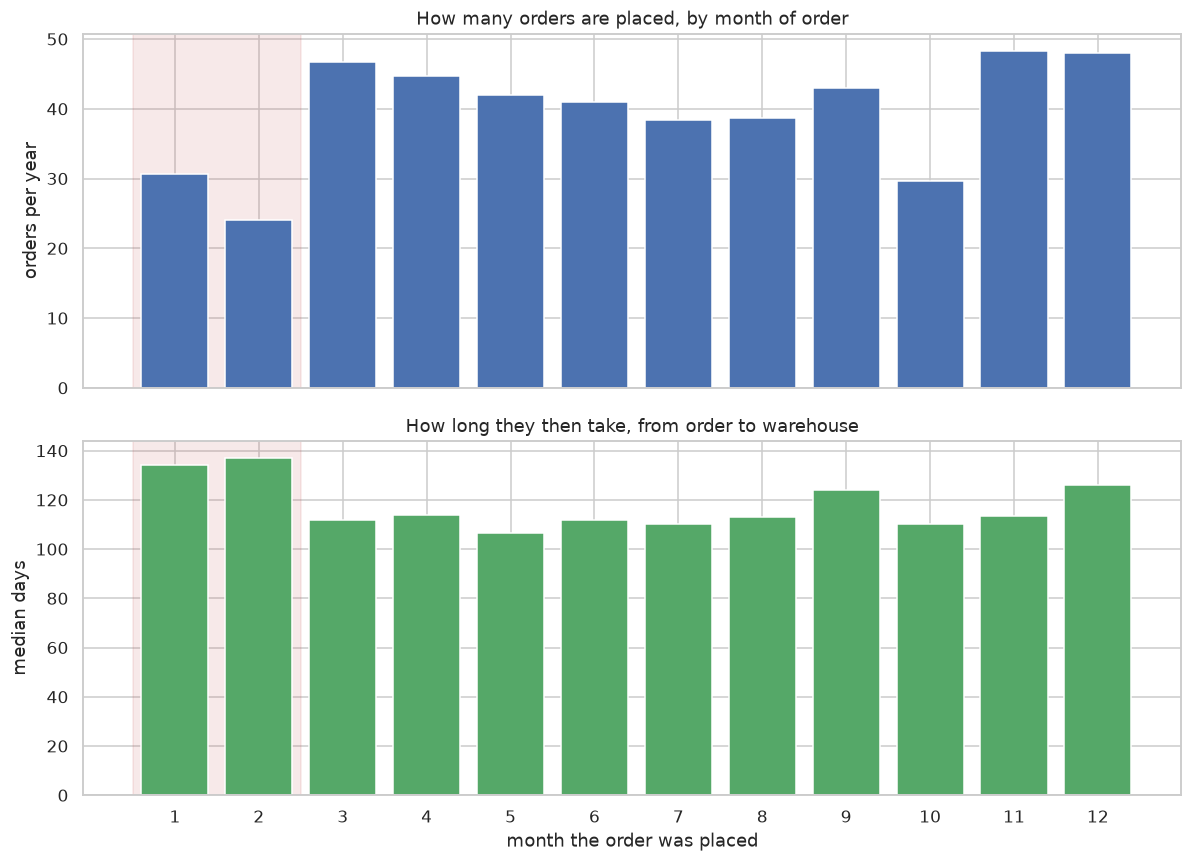

In [23]:
#
# In plain terms: this operation has a rhythm, and the rhythm is set in China, not
# in Mexico. Chinese New Year shuts the factories for weeks; Golden Week closes
# them again in October. This cell measures whether that rhythm is visible in the
# file — and it is, unmistakably.
# =============================================================================

# --- one charting decision, stated once ---------------------------------------
# These figures use matplotlib rather than plotly. Plotly is interactive and better on screen,
# but GitHub does not render plotly output inside a notebook — a reader arriving from the
# repository would see an empty cell. Static charts render everywhere, which is what a portfolio
# needs. Plotly still earns its place later, in the cells whose output is exported as an image.

# Aggregate by the month the order was placed. Three measures at once, because a month that is
# slow, late AND quiet says something different from a month that is merely quiet.
monthly = (pd.DataFrame({
        "month": usable["order_date"].dt.month,       # `.dt.month` pulls just the month out of a date
        "lead":  timings["order to warehouse"],       # days from order to warehouse
        # `> 0` gives False for a shipment whose arrival was never recorded, which would
        # quietly count it as on time. `.where(...notna())` turns those into missing
        # values instead, so the rate below is over shipments whose outcome is known.
        "late":  (timings["against the plan"] > 0).where(timings["against the plan"].notna()),
    })
    .groupby("month")
    .agg(orders=("lead", "size"), median_lead=("lead", "median"), late_rate=("late", "mean")))
monthly["orders_per_year"] = monthly["orders"] / 3    # the file holds three full years

# --- the figure ---------------------------------------------------------------
# `plt.subplots(2, 1, ...)` makes one figure with two panels stacked vertically; the two objects
# it returns are the panels themselves. `sharex=True` ties their x-axes together, so the bars in
# each panel line up under the month labels of the other.
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# The shaded band marks the Chinese New Year window — December to February. Drawing it on both
# panels means the eye compares like with like without having to remember where February sits.
for ax in (ax_top, ax_bottom):
    ax.axvspan(0.5, 2.5, color="#C44E52", alpha=0.12)

ax_top.bar(monthly.index, monthly["orders_per_year"], color="#4C72B0")
ax_top.set_ylabel("orders per year")
ax_top.set_title("How many orders are placed, by month of order")

ax_bottom.bar(monthly.index, monthly["median_lead"], color="#55A868")
ax_bottom.set_ylabel("median days")
ax_bottom.set_xlabel("month the order was placed")
ax_bottom.set_title("How long they then take, from order to warehouse")
ax_bottom.set_xticks(range(1, 13))          # label every month rather than every other one

fig.tight_layout()                          # stop the panels and labels from overlapping
fig.savefig(FIG_DIR / "01-seasonality.png", dpi=150, bbox_inches="tight")   # for the README

section("EDA — THE RHYTHM OF THE FILE",
        "Order volume above, and how long those orders then took below. The shaded band is the\n"
        "Chinese New Year window. Read the two panels together: February is the quietest month\n"
        "AND the slowest one, which is not a coincidence — it is the same factory shutdown.")
best_volume, worst_volume = monthly["orders_per_year"].idxmax(), monthly["orders_per_year"].idxmin()
fastest, slowest = monthly["median_lead"].idxmin(), monthly["median_lead"].idxmax()
best_late, worst_late = monthly["late_rate"].idxmin(), monthly["late_rate"].idxmax()
print(f" fewest orders   : month {worst_volume:>2}  ({monthly.loc[worst_volume,'orders_per_year']:.1f} per year)"
      f"   most: month {best_volume:>2}  ({monthly.loc[best_volume,'orders_per_year']:.1f})")
print(f" longest lead    : month {slowest:>2}  ({monthly.loc[slowest,'median_lead']:.0f} days)"
      f"   shortest: month {fastest:>2}  ({monthly.loc[fastest,'median_lead']:.0f} days)")
print(f" worst late rate : month {worst_late:>2}  ({100*monthly.loc[worst_late,'late_rate']:.1f}%)"
      f"   best: month {best_late:>2}  ({100*monthly.loc[best_late,'late_rate']:.1f}%)")
plt.show()
# * February is the worst month on all three measures at once — fewest orders, longest lead time,
#   highest share arriving late. Three different symptoms, one cause: the factories are shut.
# ? The late rate barely moves between the windows (24-27% across the year) even though the lead
#   time moves by thirty days. That is worth noticing: whoever sets the promised arrival date
#   already knows about Chinese New Year, and builds the slowdown into the promise. The
#   seasonality is priced into the plan rather than showing up as broken promises afterwards.

plt.show()

## KEYS — THE PORT NAMES: THE REPAIR PROFILING FLAGGED AND WE DEFERRED

In [24]:
#
# In plain terms: the profiling block flagged this column early — the same Mexican
# port written a dozen ways, the same Chinese port written six. Nothing depended on
# it, so the repair waited. Grouping by port is about to matter, and grouping by an
# unnormalised column would produce a dozen rows for three places, each too small
# to say anything.
# =============================================================================

def letters_only(text):
    """Reduce a name to its letters: accents dropped, case ignored, punctuation gone."""
    # NFKD splits an accented character into the plain letter plus a separate accent mark, and
    # `combining` identifies those marks — so removing them leaves "Lázaro" as "Lazaro".
    decomposed = unicodedata.normalize("NFKD", str(text))
    stripped = "".join(c for c in decomposed if not unicodedata.combining(c))
    return "".join(c for c in stripped.upper() if c.isalpha())

def canonical_port(value, known_ports):
    """Match a port name as written to the one known name that fits it."""
    text = letters_only(value)
    if not text:
        return None                                # nothing to match
    for name in known_ports:
        target = letters_only(name)
        if target in text or text in target:       # either contains the other, on letters alone
            return name
        # Or the port is named in part: "Ningbo, CN" for Ningbo-Zhoushan. Any word of the known
        # name, four letters or more, appearing inside the written value, identifies it.
        for token in re.split(r"[^A-Za-z]+", name):
            if len(token) >= 4 and letters_only(token) in text:
                return name
    return None                                    # nothing fits — reported, never guessed

# The eight ports this operation ships from, read off the supplier master's own `port_of_loading`
# column — where they are written NINE different ways for eight places, because one supplier row
# is a duplicate that spells the same port differently.
CHINESE_PORTS = ["Yantian", "Shekou", "Nansha", "Ningbo-Zhoushan",
                 "Shanghai", "Nantong", "Wenzhou", "Taizhou"]

# The three ports this operation enters Mexico through. There is no Mexican port master anywhere
# in these files, so these three names are a stated assumption rather than a derived fact.
MEXICAN_PORTS = ["Manzanillo", "Lázaro Cárdenas", "Veracruz"]

# `.map` runs the matching function down the whole column, giving one canonical name per row.
ports = pd.DataFrame(index=shipments_unique.index)
ports["destination"] = shipments_unique["destination_port"].map(lambda v: canonical_port(v, MEXICAN_PORTS))
ports["origin"]      = shipments_unique["origin_port"].map(lambda v: canonical_port(v, CHINESE_PORTS))

section("KEYS — HOW MANY WAYS CAN ONE PORT BE WRITTEN?",
        "Each column is counted twice: the distinct values as the file writes them, and the\n"
        "distinct places they turn out to mean. The gap between those two numbers is the whole\n"
        "cost of the drift — and it is invisible in a listing of the raw values.")
for column, label in [("destination", "destination port"), ("origin", "port of loading")]:
    written = shipments_unique["destination_port" if column == "destination" else "origin_port"]
    print(f" {label}: {written.nunique()} spellings written, {ports[column].nunique()} places meant")
    for place, count in ports[column].value_counts().items():
        print(f"    {place:20s} {count:>6,}")
    unmatched = int(ports[column].isna().sum())
    if unmatched:
        raw_bad = sorted(set(written[ports[column].isna()]))
        print(f"    {'(unmatched)':20s} {unmatched:>6,}   written as: {raw_bad}")
    print()

# * The two spellings that fit nothing are "LZC" — an abbreviation for Lázaro Cárdenas that no
#   rule can be expected to know — and four blanks. They are left unmatched, and they are two
#   rows out of 1,440, so nothing downstream is distorted by them.
# ? Worth noticing what this repair needed: no new information. Both lists were already in the
#   files, and the accents that blocked a plain string comparison were handled by a library
#   function. The twelve spellings were never twelve ports — they were one column nobody had
#   normalised.

port_summary = pd.DataFrame({
    "column":            ["destination port", "port of loading"],
    "spellings written": [int(shipments_unique["destination_port"].nunique()),
                          int(shipments_unique["origin_port"].nunique())],
    "places meant":      [int(ports["destination"].nunique()), int(ports["origin"].nunique())],
    "rows unmatched":    [int(ports["destination"].isna().sum()), int(ports["origin"].isna().sum())],
}).set_index("column")

port_summary

KEYS — HOW MANY WAYS CAN ONE PORT BE WRITTEN?
------------------------------------------------------------------------------
Each column is counted twice: the distinct values as the file writes them, and the
distinct places they turn out to mean. The gap between those two numbers is the whole
cost of the drift — and it is invisible in a listing of the raw values.
 destination port: 12 spellings written, 3 places meant
    Manzanillo            1,029
    Lázaro Cárdenas         271
    Veracruz                134
    (unmatched)               6   written as: ['', 'LZC']

 port of loading: 27 spellings written, 8 places meant
    Shanghai                397
    Ningbo-Zhoushan         248
    Shekou                  233
    Nantong                 183
    Yantian                 130
    Nansha                  118
    Wenzhou                  68
    Taizhou                  63



,spellings written,places meant,rows unmatched
column,,,
destination port,12,3,6
port of loading,27,8,0


## EDA — WHERE THE TIME GOES, AND HOW LATE "LATE" ACTUALLY IS

EDA — THE FOUR LEGS, BY PORT OF ENTRY
------------------------------------------------------------------------------
Each row is a port, and each bar is the same shipment's journey split into four parts.
The point of the chart is which part changes when you change the port — and which part
does not.
                 shipments  production  ocean  clearing  inland  late_rate  p90_delay
port                                                                                 
Lázaro Cárdenas        269       71.00  32.00      6.00    3.00      25.70      12.00
Manzanillo            1018       71.00  35.00      6.00    2.00      25.10      12.00
Veracruz               132       75.00  41.00      6.00    3.00      25.00      12.00


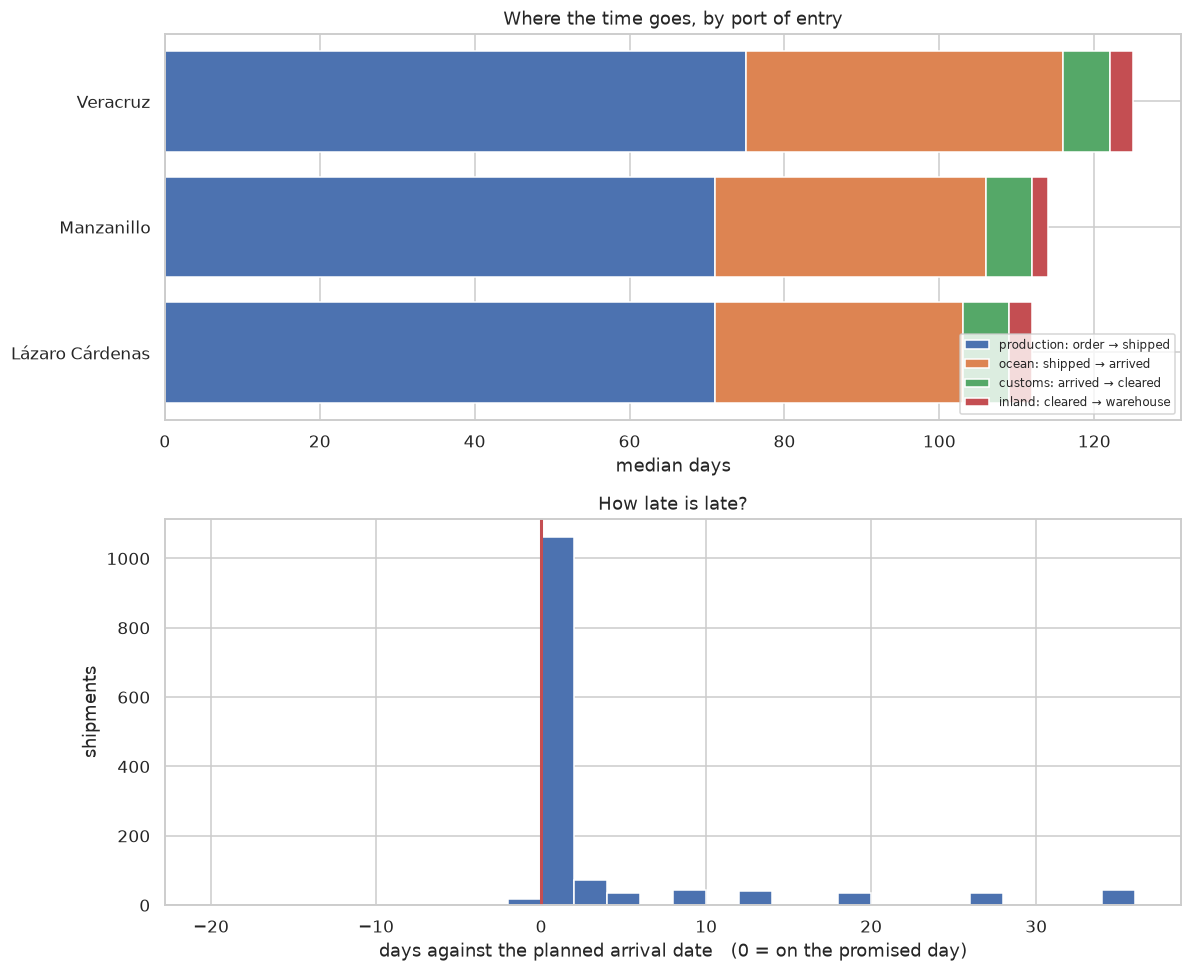

EDA — THE SHAPE OF LATENESS
------------------------------------------------------------------------------
Not the average delay, which would hide both the shipments that arrived early and the
few that arrived very late, but the distribution: how many, and by how much.
 shipments with a definite outcome : 1,387
 on time or early                  : 1,028  (74.1%)
 late                              : 359  (25.9%)
    of the late ones — median      : 8 days
                       75th pct    : 18 days
                       worst       : 34 days
    more than two weeks late       : 32.0% of them



In [25]:
#
# In plain terms: two questions a planner asks constantly. Which port should we
# use, and when a shipment misses its date, by how much? The first is answered by
# splitting the journey into its four legs and comparing them across ports. The
# second needs the shape of the delay, not its average — one shipment a month a
# week late is a different problem from twelve a year a month late.
# =============================================================================

# Every shipment, split into the four legs of its journey. Each leg is a subtraction of two
# dates, so a missing date in either one leaves that leg missing and the rest intact.
legs = pd.DataFrame({
    "port":       ports.loc[usable.index, "destination"],
    "production": (usable["etd_shipped"] - usable["order_date"]).dt.days,
    "ocean":      (usable["ata_arrival"] - usable["etd_shipped"]).dt.days,
    "clearing":   (usable["customs_cleared"] - usable["ata_arrival"]).dt.days,
    "inland":     (usable["warehouse_receipt"] - usable["customs_cleared"]).dt.days,
    "vs_plan":    timings["against the plan"],
})

# One row per port: the median of each leg, plus how many and how often late. Medians again —
# one 204-day outlier would move a mean and tell you nothing about a typical shipment.
by_port = (legs.groupby("port")
           .agg(shipments=("production", "size"),
                production=("production", "median"), ocean=("ocean", "median"),
                clearing=("clearing", "median"), inland=("inland", "median"),
                late_rate=("vs_plan", lambda x: round((x > 0).mean() * 100, 1)),
                p90_delay=("vs_plan", lambda x: x.quantile(0.9)))
           .sort_values("ocean"))

# --- the figure ---------------------------------------------------------------
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 9))

# Top panel: a stacked horizontal bar per port. `left=` is the running total of the legs already
# drawn, which is what stacks them end to end instead of overlaying them.
leg_names = ["production", "ocean", "clearing", "inland"]
leg_labels = ["production: order → shipped", "ocean: shipped → arrived",
              "customs: arrived → cleared", "inland: cleared → warehouse"]
running_total = np.zeros(len(by_port))                 # one zero per port, then accumulated
for name, label in zip(leg_names, leg_labels):
    ax_top.barh(by_port.index, by_port[name], left=running_total, label=label)
    running_total = running_total + by_port[name].to_numpy()
ax_top.set_xlabel("median days")
ax_top.set_title("Where the time goes, by port of entry")
ax_top.legend(fontsize=8, loc="lower right")

# Bottom panel: the delay distribution. `bins=range(...)` sets two-day buckets, which smooths the
# noise without hiding the spike at zero — the 1,010 shipments that arrived exactly on the day.
delays = legs["vs_plan"].dropna()
ax_bottom.hist(delays, bins=range(-20, 37, 2), color="#4C72B0", edgecolor="white")
ax_bottom.axvline(0, color="#C44E52", linewidth=2)     # the promised date, marked
ax_bottom.set_xlabel("days against the planned arrival date   (0 = on the promised day)")
ax_bottom.set_ylabel("shipments")
ax_bottom.set_title("How late is late?")
fig.tight_layout()
fig.savefig(FIG_DIR / "02-delay-and-routes.png", dpi=150, bbox_inches="tight")

section("EDA — THE FOUR LEGS, BY PORT OF ENTRY",
        "Each row is a port, and each bar is the same shipment's journey split into four parts.\n"
        "The point of the chart is which part changes when you change the port — and which part\n"
        "does not.")
print(by_port.to_string())
plt.show()

section("EDA — THE SHAPE OF LATENESS",
        "Not the average delay, which would hide both the shipments that arrived early and the\n"
        "few that arrived very late, but the distribution: how many, and by how much.")
on_time = int((delays <= 0).sum())
late_only = delays[delays > 0]
print(f" shipments with a definite outcome : {len(delays):,}")
print(f" on time or early                  : {on_time:,}  ({100 * on_time / len(delays):.1f}%)")
print(f" late                              : {len(late_only):,}  ({100 * len(late_only) / len(delays):.1f}%)")
print(f"    of the late ones — median      : {late_only.median():.0f} days")
print(f"                       75th pct    : {late_only.quantile(0.75):.0f} days")
print(f"                       worst       : {late_only.max():.0f} days")
print(f"    more than two weeks late       : {100 * (late_only > 14).mean():.1f}% of them")
print()
# ! The port changes the ocean leg by nine days — Lázaro Cárdenas 32, Veracruz 41 — and the total
#   by twelve. It changes the late rate by less than one point: 25.0%, 25.1%, 25.7%. The route
#   decides how long a shipment takes, not how often the promise breaks.
# ? The production leg reads 71 days for two ports and 75 for the third. That cannot be causal —
#   production happens before the route is even chosen — so it is sample noise on 132 shipments.
#   Worth noticing precisely because a table like this invites you to explain every difference.
# * The delay distribution is not a bell. It is a large spike at exactly zero and a long tail:
#   a third of the late shipments are more than two weeks late. That shape is what makes a
#   safety stock necessary — the typical lateness is eight days, but the one you must plan for
#   is three weeks.

plt.show()

## EDA — WHAT A MACHINE COSTS TO LAND, AND THE DUTY RATE HIDDEN IN THE MONEY

EDA — LANDED COST PER UNIT, BY PRODUCT FAMILY
------------------------------------------------------------------------------
Median above, and the 90th percentile as a dot. The two together say whether a family is
expensive in a predictable way or an expensive one — a tight gap means the price is
stable, a wide one means some shipments cost far more than the typical one.
                            shipments  median (M MXN)  p90 (M MXN)
family                                                            
Mould and die                     112            0.29         0.51
Air compressor                    134            0.44         0.63
Conveyor system                   103            0.56         0.83
Arc welding machine                99            0.64         0.79
Injection moulding machine        174            0.99         1.83
Packaging machine                 123            1.00         1.24
Laser cutting machine             147            1.20         1.54
Industrial robot       

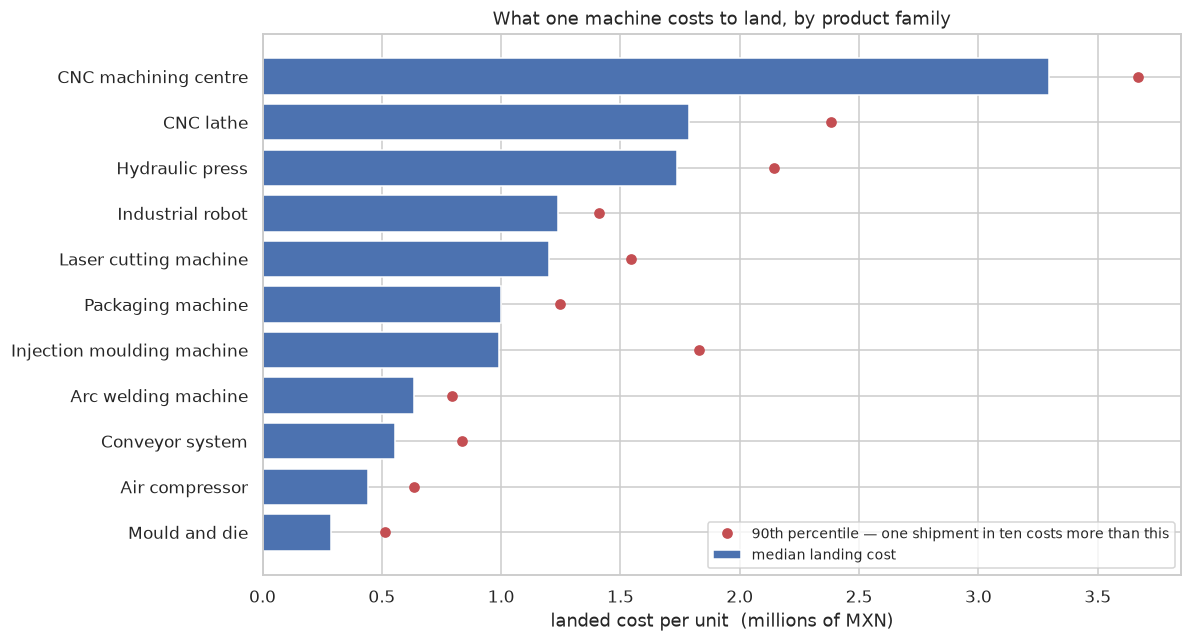

EDA — THE DUTY RATE, RECOVERED FROM THE MONEY
------------------------------------------------------------------------------
No file in this project states what duty rate each tariff code carries. But duty paid,
divided by the value it was paid on, gives it back — and the answers are clean round
numbers, which is the check that the recovery worked.
            rate implied by the duty paid
declared                                 
8414809900                           0.15
8422309900                           0.10
8428330100                           0.10
8456110100                           0.10
8457100100                           0.10
8458110100                           0.10
8462910100                           0.10
8477100100                           0.10
8479500100                           0.05
8480710100                           0.05
8515310100                           0.15



In [26]:
#
# In plain terms: two things, both about cost. First, what it costs to put one
# machine in the warehouse, by family of machine — the number a customer or a
# finance director reacts to. Second, a piece of detective work: the duty rate that
# each tariff code carries is never written down in these files, but it can be
# recovered from the duty actually paid. Which means the codes can be checked
# against the money — and that check is where the next cell goes.
# =============================================================================

# --- part one: what one machine costs -----------------------------------------
# `per_unit_mxn` was computed in the cost cell: total landed cost divided by the machines on
# the line. Grouping it by product family answers the question a buyer actually asks.
by_family = (pd.DataFrame({
        "family": joined["category"].loc[shipments_unique.index],
        "cost":   per_unit_mxn,
    })
    .groupby("family")["cost"]
    .agg(shipments="size", median="median", p90=lambda x: x.quantile(0.9))
    .sort_values("median"))

# Horizontal bars, so the family names read left to right instead of being rotated and squinted
# at. `np.arange` makes one vertical position per family, and `set_yticks` labels them — which is
# what lets the p90 markers sit on the same rows as the bars.
positions = np.arange(len(by_family))
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(positions, by_family["median"] / 1e6, color="#4C72B0", label="median landing cost")
ax.plot(by_family["p90"] / 1e6, positions, "o", color="#C44E52",
        label="90th percentile — one shipment in ten costs more than this")
ax.set_yticks(positions, by_family.index)
ax.set_xlabel("landed cost per unit  (millions of MXN)")
ax.set_title("What one machine costs to land, by product family")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "03-cost-per-unit.png", dpi=150, bbox_inches="tight")

section("EDA — LANDED COST PER UNIT, BY PRODUCT FAMILY",
        "Median above, and the 90th percentile as a dot. The two together say whether a family is\n"
        "expensive in a predictable way or an expensive one — a tight gap means the price is\n"
        "stable, a wide one means some shipments cost far more than the typical one.")
print((by_family.assign(median=lambda d: (d["median"] / 1e6).round(2),
                        p90=lambda d: (d["p90"] / 1e6).round(2)))
      .rename(columns={"shipments": "shipments", "median": "median (M MXN)", "p90": "p90 (M MXN)"})
      .to_string())
plt.show()      # ← was: fig

# --- part two: recover the duty rate from the money ---------------------------
# `implied_rate` asks: given the duty that was paid and the value it was paid on, what percentage
# does that work out to? Nobody wrote the rate down, but the arithmetic preserves it.
implied_rate = money["duty_igi_mxn"] / (money["customs_value_usd"] * good_rate)

codes = pd.DataFrame({
    "declared":     hs_code_fixed.loc[shipments_unique.index],
    "master":       norm_code(joined["hs_code_product"]).loc[shipments_unique.index],
    "implied_rate": implied_rate.loc[shipments_unique.index],
    "customs_value_mxn": (money["customs_value_usd"] * good_rate).loc[shipments_unique.index],
    "duty_paid":    money["duty_igi_mxn"].loc[shipments_unique.index],
})

# The reference table is built ONLY from rows whose declared code agrees with the product master.
# A conflicting row would otherwise drag the rate for whichever code it wrongly carries — the
# table would be polluted by the very errors it is meant to help judge.
agreeing = codes[(codes["declared"] == codes["master"]) & (codes["declared"] != "")]
reference = agreeing.groupby("declared")["implied_rate"].median()

section("EDA — THE DUTY RATE, RECOVERED FROM THE MONEY",
        "No file in this project states what duty rate each tariff code carries. But duty paid,\n"
        "divided by the value it was paid on, gives it back — and the answers are clean round\n"
        "numbers, which is the check that the recovery worked.")
print(reference.round(2).to_frame("rate implied by the duty paid").to_string())
print()
# * Eleven tariff codes, and exactly three rates: 5%, 10% and 15%. Nothing in the files says so;
#   the money says so. That is worth pausing on — a column nobody documented turned out to be
#   fully recoverable from another column, which means the two can be checked against each other.
# ? Which is what the next cell does. Where a shipment's declared code and the duty it paid imply
#   different rates, the file is contradicting itself — and the difference can be priced.

plt.show()

## EDA — WHAT THE CLASSIFICATION ERROR COSTS

In [27]:

#
# In plain terms: a shipment's tariff code decides its duty rate, and the file
# states two things about that code — the code itself, and the duty actually paid.
# Where those two imply different rates, the file is contradicting itself. This
# cell gathers both sides, prices the disagreement in pesos, and uses the money to
# work out which of the two is the error.
# =============================================================================

# --- line the three versions of the truth up side by side ---------------------
check = pd.DataFrame({
    "shipment_id": s["shipment_id"].loc[shipments_unique.index],
    "declared":    hs_code_fixed.loc[shipments_unique.index],                    # the code on the paperwork
    "master":      norm_code(joined["hs_code_product"]).loc[shipments_unique.index],  # the code for the product
    # ! Rates are rounded to four decimals before anything is compared. The implied rate is a
    #   ratio of floats, so it comes out as 0.09999999999999998 about as often as 0.1 — and an
    #   exact equality test would report every row as a mismatch. Rounding first is the fix.
    "rate_paid":   implied_rate.round(4).loc[shipments_unique.index],            # the rate the duty implies
    "value_mxn":   (money["customs_value_usd"] * good_rate).loc[shipments_unique.index],
    "duty_paid":   money["duty_igi_mxn"].loc[shipments_unique.index],
    "has_product": joined["product_name"].notna().loc[shipments_unique.index],
})
check["rate_declared"] = check["declared"].map(reference).round(4)   # the rate the CODE implies
check["rate_master"]   = check["master"].map(reference).round(4)     # the rate the PRODUCT needs

# Only rows with a product to compare against, a code on both sides, and a difference between them.
conflicts = check[check["has_product"]
                  & (check["declared"] != "")
                  & check["master"].notna()
                  & (check["declared"] != check["master"])].copy()

same_rate = conflicts["rate_declared"] == conflicts["rate_master"]   # a code error with no money effect

# --- using the money to work out which field is wrong -------------------------
# * This is the part worth reading twice. Where the two codes carry the same rate, the conflict
#   costs nothing and the money cannot help. Where they carry different rates, the duty that was
#   paid had to follow ONE of them — and which one it followed names the field that is wrong.
#   If the payment matches the product master's code, the product is right and the tariff code is
#   the error. If the payment matches the declared code, then the code is right and the SKU is
#   pointing at the wrong machine. The direction of the disagreement is the diagnosis.
code_is_wrong = ~same_rate & (conflicts["rate_paid"] == conflicts["rate_master"])
sku_is_wrong  = ~same_rate & (conflicts["rate_paid"] == conflicts["rate_declared"])

# For the shipments where the code is at fault, price the gap: what the declared code REQUIRES of
# the importer, against what was actually paid. A positive number is duty short of the declaration.
priced = conflicts[code_is_wrong].copy()
priced["required_by_the_code"] = priced["value_mxn"] * priced["rate_declared"]
priced["shortfall"] = priced["required_by_the_code"] - priced["duty_paid"]

section("EDA — THE TARIFF CODE AGAINST THE DUTY THAT WAS PAID",
        "Two fields that describe the same thing, compared through the rate each one implies. Where\n"
        "they disagree, the working below says which one the money supports — and then prices the\n"
        "difference for the shipments where the code, not the product, is the error.")
print(f" declared code differs from the master           : {len(conflicts)}")
print(f"    the two codes carry the same duty rate       : {int(same_rate.sum())}   (a code error with no money consequence)")
print(f"    a different rate — the file contradicts itself: {int((~same_rate).sum())}")
print()
print(f" of those {int((~same_rate).sum())}, the money says which field is wrong:")
print(f"    duty paid follows the master's code  →  the tariff code is wrong : {int(code_is_wrong.sum())}")
print(f"    duty paid follows the declared code  →  the SKU is wrong         : {int(sku_is_wrong.sum())}")
print()
print(f" the {int(code_is_wrong.sum())} shipments whose tariff code is wrong:")
print(f"    duty actually paid                       : MXN {priced['duty_paid'].sum():>12,.0f}")
print(f"    the declaration implies MORE than that   : MXN {priced.loc[priced['shortfall'] > 0, 'shortfall'].sum():>12,.0f}"
      f"   ({int((priced['shortfall'] > 0).sum())} shipments)")
print(f"    the declaration implies LESS than that   : MXN {priced.loc[priced['shortfall'] < 0, 'shortfall'].sum():>12,.0f}"
      f"   ({int((priced['shortfall'] < 0).sum())} shipments)")
print()
# ? The seven "implies more" shipments are the compliance exposure: read the declaration literally
#   and 1.2 million pesos of duty is unaccounted for. The five in the other direction are money
#   paid above what the paperwork justifies. Neither is a rounding matter — and both disappear
#   the moment the codes are corrected, which is the actual remedy.
# * The four SKU-is-wrong shipments carry no duty gap at all: the code and the payment agree, and
#   it is the product that is misrecorded. Same symptom, different disease — and only the money
#   could tell them apart.

priced_view = priced[["shipment_id", "declared", "master", "rate_declared", "rate_paid",
                      "required_by_the_code", "duty_paid", "shortfall"]]
priced_view["shortfall"] = priced_view["shortfall"].round(0)
priced_view.sort_values("shortfall")

EDA — THE TARIFF CODE AGAINST THE DUTY THAT WAS PAID
------------------------------------------------------------------------------
Two fields that describe the same thing, compared through the rate each one implies. Where
they disagree, the working below says which one the money supports — and then prices the
difference for the shipments where the code, not the product, is the error.
 declared code differs from the master           : 22
    the two codes carry the same duty rate       : 6   (a code error with no money consequence)
    a different rate — the file contradicts itself: 16

 of those 16, the money says which field is wrong:
    duty paid follows the master's code  →  the tariff code is wrong : 12
    duty paid follows the declared code  →  the SKU is wrong         : 4

 the 12 shipments whose tariff code is wrong:
    duty actually paid                       : MXN    3,402,593
    the declaration implies MORE than that   : MXN    1,207,422   (7 shipments)
    the declarati

,shipment_id,declared,master,rate_declared,rate_paid,required_by_the_code,duty_paid,shortfall
103,IMP-2023-0104,8479500100,8477100100,0.05,0.10,"310,046.71","620,093.41","-310,047.00"
516,IMP-2024-0034,8480710100,8457100100,0.05,0.10,"150,031.75","300,063.49","-150,032.00"
1228,IMP-2025-0263,8479500100,8414809900,0.05,0.15,"24,400.92","73,202.76","-48,802.00"
1064,IMP-2025-0099,8480710100,8515310100,0.05,0.15,"19,833.18","59,499.55","-39,666.00"
976,IMP-2025-0011,8462910100,8414809900,0.10,0.15,"28,515.56","42,773.34","-14,258.00"
1263,IMP-2025-0298,8414809900,8477100100,0.15,0.10,"98,313.53","65,542.35","32,771.00"
713,IMP-2024-0231,8414809900,8477100100,0.15,0.10,"110,452.08","73,634.72","36,817.00"
593,IMP-2024-0111,8414809900,8458110100,0.15,0.10,"244,867.85","163,245.24","81,623.00"
197,IMP-2023-0198,8456110100,8479500100,0.10,0.05,"215,765.26","107,882.63","107,883.00"
149,IMP-2023-0150,8414809900,8457100100,0.15,0.10,"458,250.03","305,500.02","152,750.00"


## EDA — HOW FAR THESE THINGS TRAVEL, AND HOW MUCH OF THAT IS SAILING

In [28]:
#
# In plain terms: a port-to-port distance can be worked out from two coordinates,
# and the supplier master carries coordinates for its ports. Putting that distance
# beside the ocean days already measured answers a question nobody wrote down in
# the file: of a 34-day ocean leg, how many of those days is the ship moving?
# =============================================================================

# --- the coordinates ----------------------------------------------------------
# One pair per Chinese port, taken from the supplier master but keyed by the CANONICAL port name —
# the same names the port block produced. Building this on the master's own spellings would leave
# "Wenzhou, CN" as a key nothing ever looks up, and "Wenzhou" permanently unfindable.
CHINESE_COORDS = {}
for _, row in raw["suppliers"].drop_duplicates("supplier_id").iterrows():
    if row["latitude"] == "":
        continue                      # this supplier's coordinates were lost — skip the row
    name = canonical_port(row["port_of_loading"], CHINESE_PORTS)   # normalise, then key on it
    CHINESE_COORDS[name] = (float(row["latitude"]), float(row["longitude"]))

# * Shanghai looked like it had no coordinates at all: three suppliers share that port, and the
#   defect blanked two of them. The third kept its own, so the busiest lane in the file is still
#   positioned from the data itself — no external reference needed after all.
# ! All eight canonical ports are now covered. If one were missing, the lookup below would fail
#   loudly on a KeyError rather than quietly dropping those shipments, which is why the two
#   happen to agree by construction: the port block and this block use the same canonical names.

MEXICAN_COORDS = {"Manzanillo": (19.0522, -104.3159),
                  "Lázaro Cárdenas": (17.9600, -102.1900),
                  "Veracruz": (19.1738, -96.1342)}

def great_circle_km(lat1, lon1, lat2, lon2):
    """Distance between two points on a sphere, in kilometres — the haversine formula."""
    EARTH_RADIUS_KM = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)      # latitudes, in radians
    d_phi = math.radians(lat2 - lat1)                        # how far north/south between them
    d_lambda = math.radians(lon2 - lon1)                     # how far east/west between them
    # The haversine of the angle between the two points, at the centre of the earth.
    a = (math.sin(d_phi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2)
    return 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(a))     # that angle, turned into a distance

# --- one row per shipment, with the lane it travelled -------------------------
lanes = pd.DataFrame({
    "origin":      ports.loc[usable.index, "origin"],          # the repaired Chinese port
    "destination": ports.loc[usable.index, "destination"],     # the repaired Mexican port
    "ocean_days":  (usable["ata_arrival"] - usable["etd_shipped"]).dt.days,
}).dropna()                                                    # a lane needs both ends and a duration

# `itertuples()` walks the rows as plain objects, which is the readable way to call a function
# that takes four separate numbers. The distance depends only on the lane, not the shipment.
lanes["km"] = [round(great_circle_km(*CHINESE_COORDS[r.origin], *MEXICAN_COORDS[r.destination]))
               for r in lanes.itertuples()]
# One nautical mile is 1.852 km, and a "knot" is one nautical mile per hour — so 20 knots is
# 20 × 1.852 × 24 kilometres a day. This turns a real-world cruising speed into the same units
# as the distance, which makes the two comparable.
lanes["days_at_20_knots"] = (lanes["km"] / (20 * 1.852 * 24)).round(1)

lane_summary = (lanes.groupby(["origin", "destination"])
                .agg(shipments=("ocean_days", "size"), km=("km", "first"),
                     median_ocean_days=("ocean_days", "median"),
                     days_at_20_knots=("days_at_20_knots", "first"))
                .reset_index()
                .sort_values("shipments", ascending=False))
lane_summary["km per day actually achieved"] = (lane_summary["km"] / lane_summary["median_ocean_days"]).round(0)

section("EDA — THE LANES, THEIR DISTANCE, AND THE SPEED THEY IMPLY",
        "Distances are great-circle: the shortest line between two points on a sphere, which is\n"
        "shorter than anything a ship can sail. That makes every figure below a floor, not an\n"
        "estimate — which is the right direction for the conclusion drawn from it.")
print(lane_summary.head(10).to_string(index=False))
print()
median_km = lane_summary["km"].median()
median_days = lane_summary["median_ocean_days"].median()
at_sea = median_km / (20 * 1.852 * 24)
print(f" the median lane          : {median_km:,.0f} km, {median_days:.0f} ocean days")
print(f" that distance at 20 knots: {at_sea:.1f} days")
print(f" the file says            : {median_days:.0f} days")
print()
# ! The gap is the finding. Even allowing a ship to take the shortest possible line at a
#   sustained 20 knots — faster than most container ships actually cruise — only about 15 of
#   those 34 days can be explained by sailing. At least 19 days of every ocean leg is spent
#   waiting, in transshipment, or alongside a berth at either end.
# ? This is a bound, not an estimate, and the direction matters: the real sea route is longer
#   than the great circle and real ships are slower than 20 knots, so the true sailing time is
#   HIGHER than 15 days and the idle share is LOWER than 57%. The conclusion that survives is
#   the weaker one: a large minority of the ocean leg is not movement.
# * Which is where the money is. Freight is charged per container, not per day, but a shipment
#   sitting in a terminal still ages, still ties up working capital, and still risks demurrage —
#   and none of that is the carrier's problem to fix.

lane_summary.head(12)

EDA — THE LANES, THEIR DISTANCE, AND THE SPEED THEY IMPLY
------------------------------------------------------------------------------
Distances are great-circle: the shortest line between two points on a sphere, which is
shorter than anything a ship can sail. That makes every figure below a floor, not an
estimate — which is the right direction for the conclusion drawn from it.
         origin     destination  shipments    km  median_ocean_days  days_at_20_knots  km per day actually achieved
       Shanghai      Manzanillo        270 12572              35.00             14.10                        359.00
Ningbo-Zhoushan      Manzanillo        167 12687              34.00             14.30                        373.00
         Shekou      Manzanillo        166 13804              35.00             15.50                        394.00
        Nantong      Manzanillo        132 12574              34.00             14.10                        370.00
        Yantian      Manzanillo      

,origin,destination,shipments,km,median_ocean_days,days_at_20_knots,km per day actually achieved
10,Shanghai,Manzanillo,270,12572,35.00,14.10,359.00
7,Ningbo-Zhoushan,Manzanillo,167,12687,34.00,14.30,373.00
13,Shekou,Manzanillo,166,13804,35.00,15.50,394.00
4,Nantong,Manzanillo,132,12574,34.00,14.10,370.00
22,Yantian,Manzanillo,98,13771,34.00,15.50,405.00
1,Nansha,Manzanillo,83,13813,33.00,15.50,419.00
9,Shanghai,Lázaro Cárdenas,76,12811,33.00,14.40,388.00
6,Ningbo-Zhoushan,Lázaro Cárdenas,54,12928,30.00,14.50,431.00
12,Shekou,Lázaro Cárdenas,50,14046,31.00,15.80,453.00
16,Taizhou,Manzanillo,48,12785,35.00,14.40,365.00


## EDA — THE ROUTE, ON A MAP

EDA — THE ROUTE ON A MAP
------------------------------------------------------------------------------
This is the figure written for the README: it answers 'what is this project about'
before a reader has opened a single cell. The other figures carry the detail; this one
carries the story.
 figure written to : reports/figures/05-pacific-route.png
 lanes drawn       : 24
 coastlines        : data/external/ne_110m_land.geojson (Natural Earth, public domain)
 network required  : none



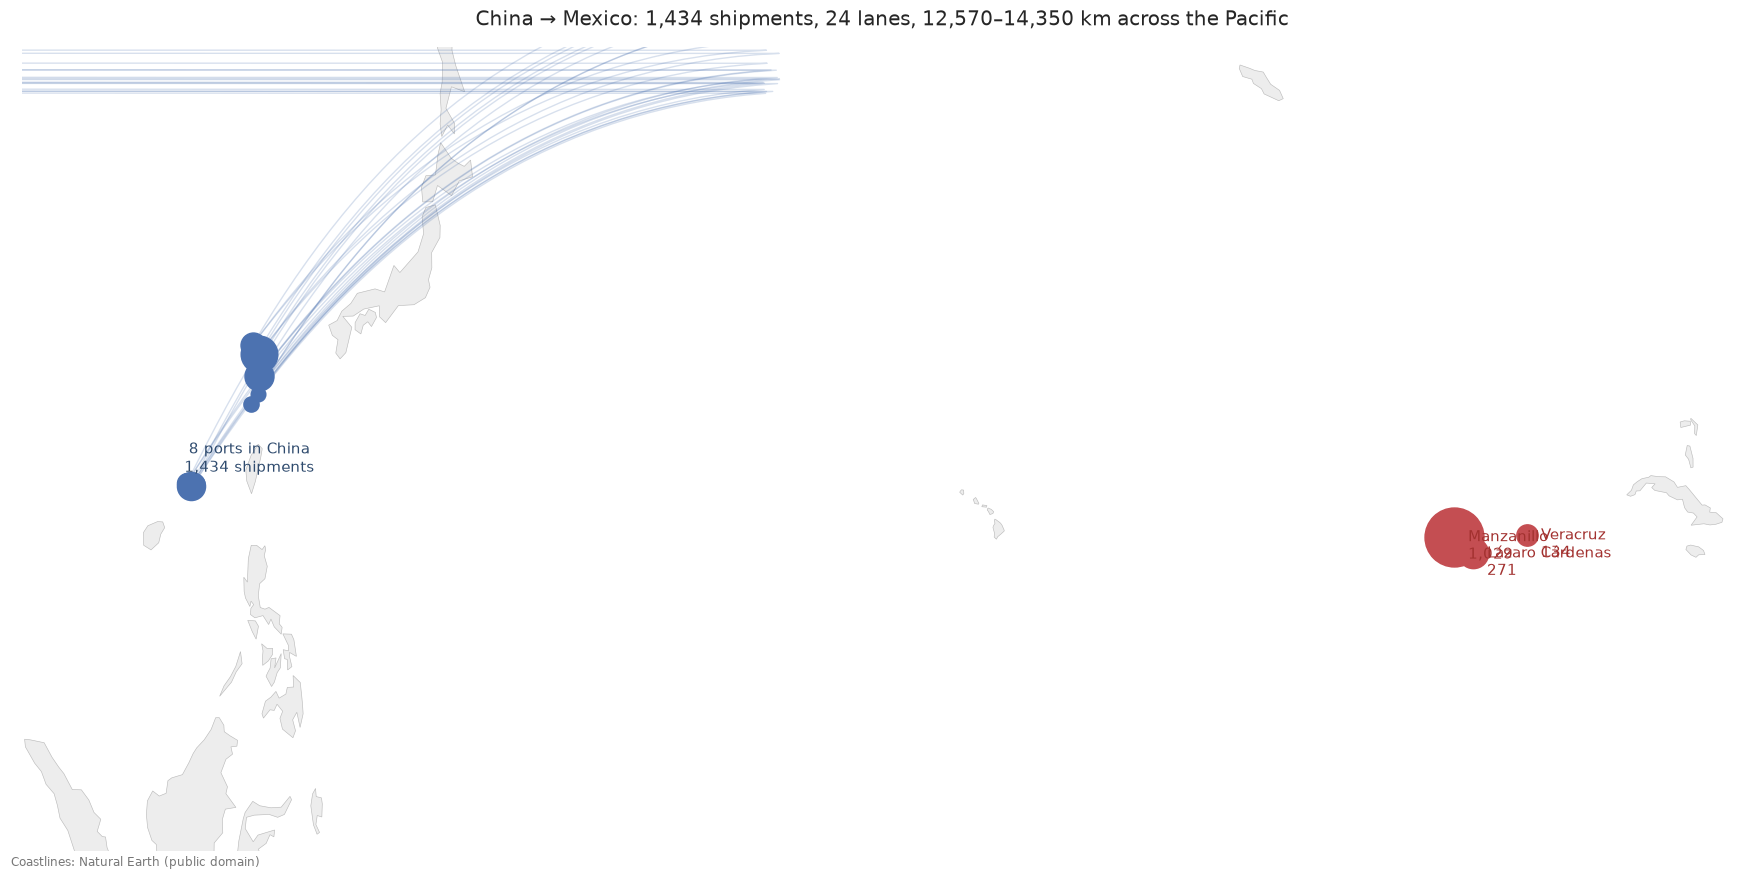

In [29]:
#
# In plain terms: the same traffic the next cell charts, drawn where it actually
# happens. This one is built for the README — it is the figure that says what the
# project is about before a reader has opened a single cell — so it is exported at
# high resolution and it works with no network at all.
# =============================================================================

from matplotlib.patches import Polygon as MplPoly   # land shapes drawn onto the axes

# The coastlines are a public-domain file committed to the repository, not map tiles fetched at
# run time. Two reasons, and the second is decisive: tiles need the network, and standard web-map
# tiles stop at the dateline, so a Pacific crossing cannot be drawn on them at all.
# See `data/external/SOURCE.md`.
land = json.loads((PROJECT_ROOT / "data" / "external" / "ne_110m_land.geojson")
                  .read_text(encoding="utf-8"))["features"]

# Marker sizes come from the same counts the next cell charts, computed here so this cell can be
# run on its own.
origin_volume = ports["origin"].value_counts()
destination_volume = ports["destination"].value_counts()

def pacific_lon(lon):
    """Shift a longitude into a Pacific-centred window: 104°W becomes 256°E."""
    # Map coordinates run -180 to 180, which puts the dateline through the middle of this route.
    # Adding 360 to everything west of Greenwich moves the cut to the Atlantic, where nothing in
    # this figure happens. The map then reads continuously from China east across the ocean.
    return lon + 360 if lon < 0 else lon

def bounds(ring):
    """The smallest box that contains a ring of points."""
    xs = [point[0] for point in ring]
    ys = [point[1] for point in ring]
    return min(xs), max(xs), min(ys), max(ys)

def great_circle_path(lat1, lon1, lat2, lon2, steps=80):
    """Points along the great-circle route between two ports, as (longitude, latitude)."""
    # Spherical interpolation: a straight line on a flat map is a curve in reality, so this walks
    # the actual shortest path over a sphere in equal steps.
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    L1, L2 = math.radians(pacific_lon(lon1)), math.radians(pacific_lon(lon2))
    angle = 2 * math.asin(math.sqrt(math.sin((phi2 - phi1) / 2) ** 2
                                    + math.cos(phi1) * math.cos(phi2) * math.sin((L2 - L1) / 2) ** 2))
    path = []
    for t in np.linspace(0, 1, steps):
        a, b = math.sin((1 - t) * angle) / math.sin(angle), math.sin(t * angle) / math.sin(angle)
        x = a * math.cos(phi1) * math.cos(L1) + b * math.cos(phi2) * math.cos(L2)
        y = a * math.cos(phi1) * math.sin(L1) + b * math.cos(phi2) * math.sin(L2)
        z = a * math.sin(phi1) + b * math.sin(phi2)
        path.append((math.degrees(math.atan2(y, x)), math.degrees(math.atan2(z, math.hypot(x, y)))))
    return path


fig, ax = plt.subplots(figsize=(16, 8))

# --- the land ----------------------------------------------------------------
# Each polygon is shifted first, then measured. A polygon straddling the dateline would span the
# whole width of the shifted map and be drawn as a grey band across the ocean — so anything wider
# than 120 degrees of longitude is dropped, along with anything outside the latitude belt this
# route occupies. Four polygons out of 127 fail that test, and all four are outside the frame.
for feature in land:
    geometry = feature["geometry"]
    polygons = geometry["coordinates"] if geometry["type"] == "MultiPolygon" else [geometry["coordinates"]]
    for polygon in polygons:
        ring = [[pacific_lon(x), y] for x, y in polygon[0]]
        x0, x1, y0, y1 = bounds(ring)
        if x1 - x0 > 120 or y1 < 0 or y0 > 52 or x0 > 285 or x1 < 95:
            continue
        ax.add_patch(MplPoly(ring, closed=True, facecolor="#EDEDED", edgecolor="#BBBBBB",
                             linewidth=0.4, zorder=1))

# --- the lanes ---------------------------------------------------------------
# All 24, drawn faintly. The point is not to follow any one line but to see the bundle: eight
# origins converging on a single stretch of Mexican coast.
for (origin_lat, origin_lon) in CHINESE_COORDS.values():
    for (dest_lat, dest_lon) in MEXICAN_COORDS.values():
        route = great_circle_path(origin_lat, origin_lon, dest_lat, dest_lon)
        ax.plot([p[0] for p in route], [p[1] for p in route],
                color="#4C72B0", alpha=0.22, linewidth=0.9, zorder=2)

# --- the ports ---------------------------------------------------------------
# Markers sized by traffic, using the same volumes as the cell below, so the two figures agree.
for name, (lat, lon) in CHINESE_COORDS.items():
    ax.plot(pacific_lon(lon), lat, "o", color="#4C72B0",
            markersize=np.sqrt(origin_volume.get(name, 0)) * 1.2, zorder=3)
ax.annotate("8 ports in China\n1,434 shipments",
            (pacific_lon(120.5), 25.5), textcoords="offset points", xytext=(0, -20),
            fontsize=10, color="#2F4B6E", ha="center", zorder=4)
for name, (lat, lon) in MEXICAN_COORDS.items():
    ax.plot(pacific_lon(lon), lat, "o", color="#C44E52",
            markersize=np.sqrt(destination_volume.get(name, 0)) * 1.2, zorder=3)
    ax.annotate(f"{name}\n{destination_volume.get(name, 0):,}",
                (pacific_lon(lon), lat), textcoords="offset points", xytext=(9, -14),
                fontsize=9.5, color="#A2312F", zorder=4)

ax.set_xlim(95, 288)
ax.set_ylim(-2, 52)
ax.set_axis_off()                              # a map has no use for tick marks
ax.set_title("China → Mexico: 1,434 shipments, 24 lanes, 12,570–14,350 km across the Pacific",
             fontsize=13, pad=14)
fig.text(0.005, 0.005, "Coastlines: Natural Earth (public domain)", fontsize=8, color="#777777")
fig.tight_layout()
fig.savefig(FIG_DIR / "05-pacific-route.png", dpi=160, bbox_inches="tight")

section("EDA — THE ROUTE ON A MAP",
        "This is the figure written for the README: it answers 'what is this project about'\n"
        "before a reader has opened a single cell. The other figures carry the detail; this one\n"
        "carries the story.")
print(f" figure written to : reports/figures/05-pacific-route.png")
print(f" lanes drawn       : {len(CHINESE_COORDS) * len(MEXICAN_COORDS)}")
print(f" coastlines        : data/external/ne_110m_land.geojson (Natural Earth, public domain)")
print(f" network required  : none")
print()
# * Markers are sized by shipment volume, so this figure carries the same information as the bar
#   chart below: Manzanillo's dot is visibly the largest thing on the Mexican coast — the 72%
#   dependency, seen rather than read.

plt.show()

## EDA — WHERE THE TRAFFIC IS, AND HOW THE LANES RUN

EDA — THE PORTS AND THE LANES
------------------------------------------------------------------------------
On the left, how the shipments divide between eleven ports. On the right, the same traffic
seen as routes. Between them they answer where the operation depends on a single point,
which is the question a map makes you guess at and these make you read.
 shipments with both ports identified : 1,434
 loading ports                        : 8   busiest: Shanghai (394)
 entry ports                          : 3   busiest: Manzanillo (1,029)
 top two loading ports together       : 641 shipments (45%)
 largest single entry port            : 72% of everything



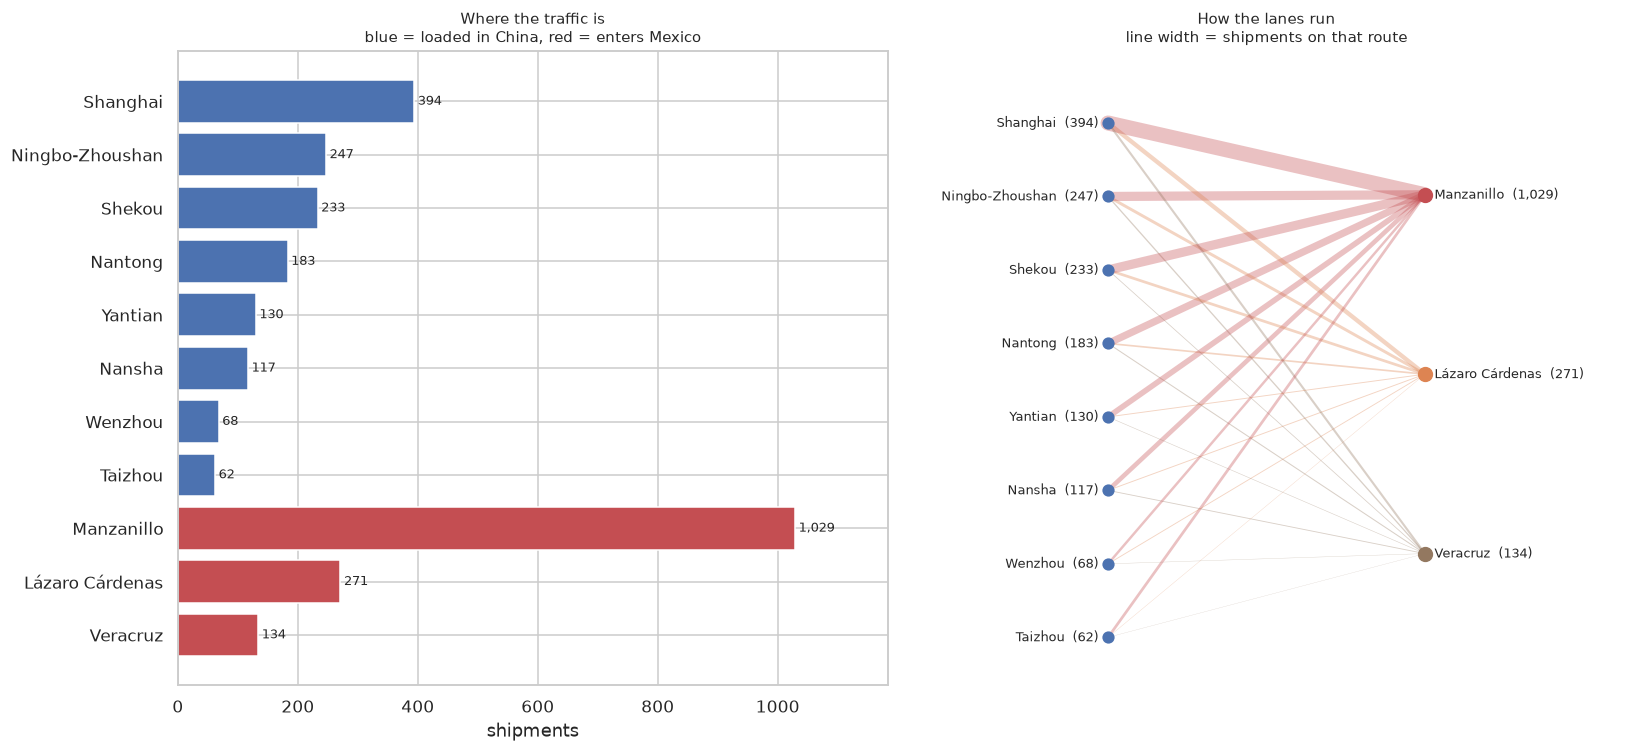

In [30]:
#
# In plain terms: two questions, two clean pictures. Which ports carry the volume,
# and how the traffic divides between the routes. Neither needs a map — the three
# busiest loading ports sit within thirty kilometres of each other on the same
# stretch of coast, so a geographic view crowds its own labels and adds a network
# dependency without adding a fact.
# =============================================================================

# Every deduplicated shipment whose ports resolved at both ends. This is the full set, not the
# timing subset — a port's traffic is a fact about the port, so no shipment is excluded here for
# having a missing date.
lanes = pd.DataFrame({
    "origin":      ports["origin"],
    "destination": ports["destination"],
}).dropna()

origin_volume = lanes["origin"].value_counts()            # most-used loading port first
destination_volume = lanes["destination"].value_counts()  # most-used entry port first

fig, (ax_bar, ax_flow) = plt.subplots(1, 2, figsize=(15, 7))

# --- panel one: the ports, ranked ---------------------------------------------
# One stacked list rather than two charts, with colour separating the two sides — so the reader
# compares a Chinese port with a Mexican one directly, which is the comparison that matters.
names = list(origin_volume.index) + list(destination_volume.index)
values = list(origin_volume.values) + list(destination_volume.values)
colours = ["#4C72B0"] * len(origin_volume) + ["#C44E52"] * len(destination_volume)
positions = np.arange(len(names))[::-1]                   # reversed so the largest sits at the top
ax_bar.barh(positions, values, color=colours)
ax_bar.set_yticks(positions, names)
ax_bar.set_xlabel("shipments")
ax_bar.set_title("Where the traffic is\nblue = loaded in China, red = enters Mexico", fontsize=10)
for position, value in zip(positions, values):            # the bar length is the message, the number confirms it
    ax_bar.text(value + 6, position, f"{value:,}", va="center", fontsize=8.5)
ax_bar.set_xlim(0, max(values) * 1.15)                    # headroom so no label runs off the edge

# --- panel two: the lanes ------------------------------------------------------
# A flow diagram: the eight loading ports down the left, the three entry ports down the right, and
# one line per route whose WIDTH is the number of shipments on it. `np.linspace` spreads the ports
# evenly down each side; the dictionaries map a port name to its vertical position.
origin_y = {name: y for name, y in zip(origin_volume.index, np.linspace(0.92, 0.06, len(origin_volume)))}
destination_y = {name: y for name, y in zip(destination_volume.index, np.linspace(0.80, 0.20, len(destination_volume)))}
destination_colour = {"Manzanillo": "#C44E52", "Lázaro Cárdenas": "#DD8452", "Veracruz": "#937860"}

lane_volume = lanes.groupby(["origin", "destination"]).size()   # shipments per route
for (origin, destination), count in lane_volume.items():
    ax_flow.plot([0, 1], [origin_y[origin], destination_y[destination]],
                 linewidth=count / 28, alpha=0.35, color=destination_colour[destination],
                 solid_capstyle="round")                       # rounded ends so thin lines stay visible

for name, y in origin_y.items():                               # label each loading port with its total
    ax_flow.plot(0, y, "o", color="#4C72B0", markersize=7)
    ax_flow.text(-0.03, y, f"{name}  ({origin_volume[name]:,})", ha="right", va="center", fontsize=8.5)
for name, y in destination_y.items():                           # and each entry port
    ax_flow.plot(1, y, "o", color=destination_colour[name], markersize=9)
    ax_flow.text(1.03, y, f"{name}  ({destination_volume[name]:,})", ha="left", va="center", fontsize=8.5)

ax_flow.set_xlim(-0.62, 1.62)                                   # room for the labels on both sides
ax_flow.set_ylim(-0.02, 1.04)
ax_flow.set_axis_off()                                          # a diagram has no axes to show
ax_flow.set_title("How the lanes run\nline width = shipments on that route", fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / "04-port-traffic.png", dpi=140, bbox_inches="tight")

section("EDA — THE PORTS AND THE LANES",
        "On the left, how the shipments divide between eleven ports. On the right, the same traffic\n"
        "seen as routes. Between them they answer where the operation depends on a single point,\n"
        "which is the question a map makes you guess at and these make you read.")
print(f" shipments with both ports identified : {len(lanes):,}")
print(f" loading ports                        : {len(origin_volume)}"
      f"   busiest: {origin_volume.index[0]} ({origin_volume.iloc[0]:,})")
print(f" entry ports                          : {len(destination_volume)}"
      f"   busiest: {destination_volume.index[0]} ({destination_volume.iloc[0]:,})")
print(f" top two loading ports together       : "
      f"{origin_volume.iloc[0] + origin_volume.iloc[1]:,} shipments "
      f"({100 * (origin_volume.iloc[0] + origin_volume.iloc[1]) / len(lanes):.0f}%)")
print(f" largest single entry port            : "
      f"{100 * destination_volume.iloc[0] / len(lanes):.0f}% of everything")
print()
# * Shanghai and Ningbo-Zhoushan together load 641 of the 1,434 shipments — 45% — and both sit on
#   the same stretch of the East China coast. That is not eight ports sharing the work; it is two
#   ports carrying half of it, with six alternatives around the edges.
# ? Manzanillo takes 1,029 — 72% of all shipments. The three Mexican ports are not a balanced
#   choice between equals; one is the gateway and the other two are exceptions. Any conclusion
#   about "port performance" is really a conclusion about Manzanillo, and the notebook should say
#   so wherever it draws one.
# ! There is no geographic map in this cell, deliberately. Yantian, Shekou and Nansha lie within
#   thirty kilometres of one another, so a map labels them on top of each other, and the tiles it
#   needs come from the network. The distances are already in the lane table one cell above — the
#   geography is measured there, not drawn here.

plt.show()

## EDA — CAN THESE SUPPLIERS ACTUALLY BE RANKED?

EDA — THE SUPPLIER SCORECARD, WITH ITS OWN ERROR BARS
------------------------------------------------------------------------------
Each point is a supplier's late rate; the bar through it is the range the true rate could
plausibly sit in, given how many shipments that supplier has. If the bars overlap, the
ranking between those suppliers is not supported by the data.
          shipments  late_rate    ci
supplier                            
SUP-1009         45      17.80 11.20
SUP-1003        116      19.80  7.30
SUP-1007        122      22.10  7.40
SUP-1011        120      22.50  7.50
SUP-1014        180      22.80  6.10
SUP-1013        158      22.80  6.50
SUP-1001         91      26.40  9.10
SUP-1008         67      28.40 10.80
SUP-1012        101      28.70  8.80
SUP-1005         73      28.80 10.40
SUP-1002        149      31.50  7.50
SUP-1010         61      34.40 11.90
SUP-1006         72      37.50 11.20

 suppliers rated                        : 13 (at least 40 shipments each

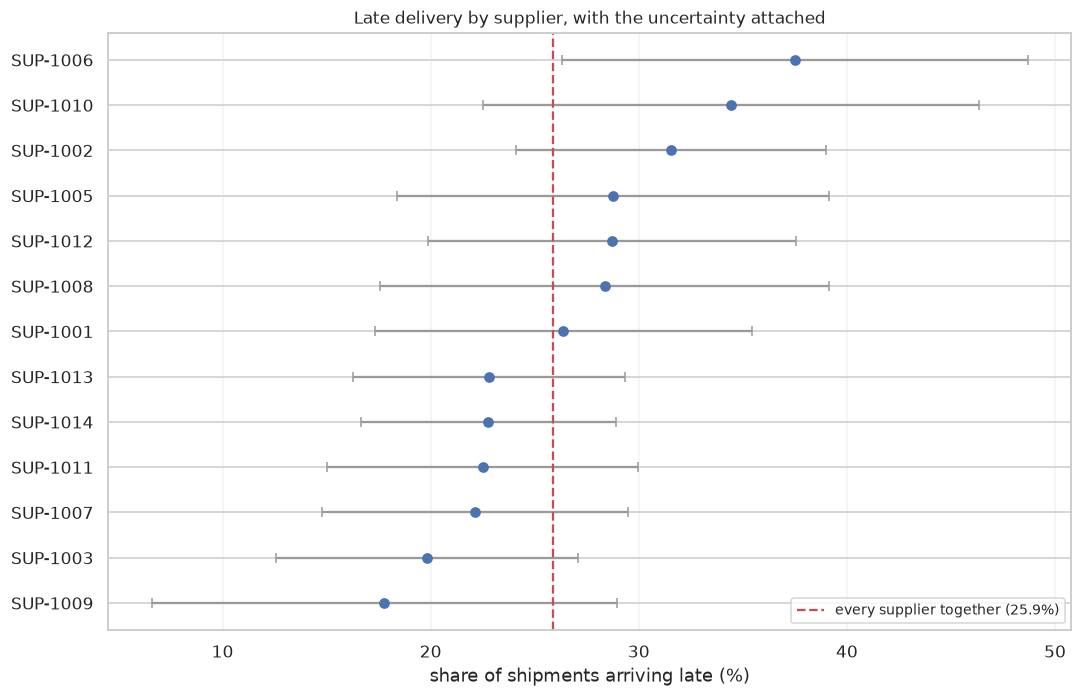

In [31]:
#
# In plain terms: the obvious next step is a supplier scorecard — who delivers on
# time, who is slow. This cell builds one, and then asks the question that makes it
# useful or dangerous: is the difference between the best supplier and the worst
# bigger than the uncertainty in each of those numbers?
# =============================================================================

# --- the supplier profile ------------------------------------------------------
# Everything this cell needs, assembled in one place. The frame is called `profile`, not `df`:
# the loading cell used to leave a variable named `df` behind — holding whichever file it read
# last, the exchange rates — so reaching for that name gave a confusing error instead of a clear one.
profile = pd.DataFrame({
    "supplier":   repaired.loc[usable.index],        # the repaired supplier code
    "delay_days": timings["against the plan"],       # days against the promised arrival date
    "lead_days":  timings["order to warehouse"],     # days from order to warehouse
    "category":   joined["category"].loc[usable.index],
})
profile = profile[profile["delay_days"].notna()]     # only shipments with a computable delay
profile["late"] = profile["delay_days"] > 0          # a yes/no flag per shipment


# The scorecard is grouped by the REPAIRED supplier code, not the raw column. Grouping on the raw
# column would split the same supplier across its own spelling variants — thirteen suppliers would
# appear as twenty-five rows, each with too few shipments to say anything.
scorecard = profile.groupby("supplier").agg(                                    # was df
    shipments=("late", "size"),
    late_rate=("late", "mean"),
).query("shipments >= 40")                       # suppliers with too few shipments are not rated

scorecard["late_rate"] *= 100                    # as a percentage, for reading
# The 95% confidence interval for a proportion. With p near 0.25 and n near 100, the interval is
# about ±8 points — which is the number that decides whether any of this is real.
n = scorecard["shipments"]
proportion = scorecard["late_rate"] / 100
scorecard["ci"] = 1.96 * np.sqrt(proportion * (1 - proportion) / n) * 100
scorecard = scorecard.sort_values("late_rate")
overall_late_rate = profile["late"].mean() * 100                                 # was df

# --- the test -----------------------------------------------------------------
# A chi-square test asks whether the differences between groups are larger than the variation you
# would expect from random sampling alone. `crosstab` builds the table it needs: one row per
# supplier, two columns — on time, late.
table        = pd.crosstab(profile[profile["supplier"].isin(scorecard.index)]["supplier"],
                           profile[profile["supplier"].isin(scorecard.index)]["late"])
chi2, p_value, degrees, _ = stats.chi2_contingency(table)
table_family = pd.crosstab(profile["category"], profile["late"])
chi2_family, p_family, dof_family, _ = stats.chi2_contingency(table_family)

fig, ax = plt.subplots(figsize=(10, 6.5))
positions = np.arange(len(scorecard))
# `xerr` draws the confidence interval as a horizontal bar through each point — which is what turns
# a ranking into a judgement about whether the ranking means anything.
ax.errorbar(scorecard["late_rate"], positions, xerr=scorecard["ci"],
            fmt="o", color="#4C72B0", ecolor="#9A9A9A", capsize=3, markersize=6)
ax.axvline(overall_late_rate, color="#C44E52", linestyle="--", linewidth=1.5,
           label=f"every supplier together ({overall_late_rate:.1f}%)")
ax.set_yticks(positions, scorecard.index)
ax.set_xlabel("share of shipments arriving late (%)")
ax.set_title("Late delivery by supplier, with the uncertainty attached", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "06-supplier-late-rates.png", dpi=150, bbox_inches="tight")

section("EDA — THE SUPPLIER SCORECARD, WITH ITS OWN ERROR BARS",
        "Each point is a supplier's late rate; the bar through it is the range the true rate could\n"
        "plausibly sit in, given how many shipments that supplier has. If the bars overlap, the\n"
        "ranking between those suppliers is not supported by the data.")
print(scorecard.assign(**{"late_rate": lambda d: d["late_rate"].round(1),
                          "ci": lambda d: d["ci"].round(1)}).to_string())
print()
print(f" suppliers rated                        : {len(scorecard)} (at least 40 shipments each)")
print(f" spread between best and worst          : {scorecard['late_rate'].max() - scorecard['late_rate'].min():.1f} points")
print(f" widest single confidence interval      : {2 * scorecard['ci'].max():.1f} points wide")
print(f" all suppliers together                 : {overall_late_rate:.1f}% late")
print()
print(f" chi-square, supplier vs late : chi2 = {chi2:.1f}, dof = {degrees}, p = {p_value:.3f}")
print(f" chi-square, family   vs late : chi2 = {chi2_family:.1f}, dof = {dof_family}, p = {p_family:.3f}")
print()
# ! No supplier stands out. The best-to-worst spread is 19.7 points, but the widest single
#   confidence interval is 23.8 points wide — the uncertainty attached to one supplier's rate is
#   larger than the entire difference between the best and the worst of them. Both chi-square tests
#   agree: p = 0.118 and p = 0.124. Neither is close to significant.
# ? So the honest answer to "which supplier is unreliable" is: this file cannot tell you. Ranking
#   these suppliers on their delivery performance would be reading noise, and the ranking would
#   change completely if another year of shipments were added. A scorecard that looked this precise
#   and meant nothing is a worse outcome than no scorecard.
# * What DOES differ between suppliers is lead time and cost — but because of what they sell, not
#   how they perform. A supplier of moulds ships in 101 days at 0.2 million pesos a unit; a
#   supplier of packaging machines takes 133 days at four times the cost. That is a real
#   difference, and it is a product-mix fact, not a performance one.

# ? Why there is no clustering in this notebook. A k-means run over fourteen suppliers would
#   return groups whether or not any exist, and the groups it returned here would be re-deriving
#   the product mix that the `category` column already states. Clustering earns its place in
#   notebook 2, on data with hundreds of groups and an actual question to answer.

plt.show()

## EXPORT — THE CLEAN DATA, AND EVERYTHING THAT WAS FOUND

In [32]:
#
# In plain terms: two outputs. The analysis table, saved in a form another tool
# could pick up. And the findings table — one row per problem, how many shipments it
# touched, and what was decided about it. That second file is the answer to the
# question an interviewer always asks: how did you know you were finished?
# =============================================================================

# --- the analysis table -------------------------------------------------------
# `analysis` was built for the database and already holds the repaired keys, the joined detail,
# the parsed dates and the money. Two columns are worth adding before it leaves the notebook:
# the product family, and the loading port under its canonical name.
export = analysis.copy()
export["category"] = joined["category"].loc[export.index]
export["origin_port"] = ports["origin"].loc[export.index]

# --- the findings table -------------------------------------------------------
# ! Every number below was measured in a cell above, and every decision was taken in one. This
#   table is written by hand, which makes it the one place in the notebook where a figure could go
#   stale without the code noticing. It is checked before the repository is pushed.
findings = pd.DataFrame([
    ("F-01", "Encoding",     "shipments.csv is Latin-1, not UTF-8", 1,
     "Read with the encoding it is stored in; the failure is demonstrated in the opening cell"),
    ("F-02", "Encoding",     "products.csv carries a byte-order mark", 1,
     "Read with utf-8-sig; tested rather than assumed — pandas strips it either way"),
    ("F-03", "Duplicates",   "Rows copied whole", 12,
     "Removed. 1,458 rows in the file, 1,440 shipments described"),
    ("F-04", "Duplicates",   "The same shipment entered twice under a second id", 6,
     "Removed the re-entered copy, keeping the row in the file's own id sequence"),
    ("F-05", "Dates",        "Four date formats mixed row by row", 1_458,
     "Detected by pattern, then parsed per row rather than per column"),
    ("F-06", "Dates",        "Slash dates readable day-first or month-first", 1_765,
     "Resolved from evidence inside each row, never by assumption"),
    ("F-07", "Dates",        "Rows with no decisive evidence at all", 17,
     "Settled by the order of events, then by the PO number; the two methods agreed on all 11 rows "
     "where both applied"),
    ("F-08", "Dates",        "Shipments whose own timeline is impossible", 15,
     "Flagged and excluded from every timing figure until someone rules on them"),
    ("F-09", "Keys",         "Supplier codes failing an exact match", 37,
     "16 tidied, 7 had the hyphen restored, 6 recovered from the loading port, 8 left unresolved"),
    ("F-10", "Keys",         "Product codes matching nothing", 10,
     "Left flagged; the join shows them empty rather than guessing a product"),
    ("F-11", "Keys",         "A code written 27 ways for 8 ports", 27,
     "Normalised against the master with accents stripped; 12 spellings collapse to 3 Mexican ports"),
    ("F-12", "Keys",         "Rows where an independent test disagrees with the code", 45,
     "Listed with the reason each was caught: matching nothing, a different tariff code, or a price "
     "far from the master's"),
    ("F-13", "Tariff",       "Declared HS codes contradicting the product master", 22,
     "6 carry the same duty rate and cost nothing; 16 disagree on the rate and are itemised below"),
    ("F-14", "Tariff",       "Shipments where the code and the duty paid cannot both be right", 16,
     "The money identified which field is wrong: 12 tariff codes, 4 SKUs pointing at the wrong product"),
    ("F-15", "Tariff",       "Duty the declared codes imply beyond what was paid", 7,
     "MXN 1,207,422 of exposure if the declaration is read literally — corrected by fixing the codes"),
    ("F-16", "Money",        "Amounts stored as text", 1_291,
     "2,380 flags across three patterns, but only 1,291 distinct cells: 1,033 carry a "
     "currency symbol, 1,291 a thousands separator, 53 are written the European way"),
    ("F-17", "Money",        "Broken spreadsheet formulas", 2,
     "'#REF!' in the customs processing fee, left missing rather than filled with zero"),
    ("F-18", "Money",        "Lines breaking quantity x price = total", 6,
     "3 with a zero quantity and 3 with a price 100x too high; identified by cause, not corrected"),
    ("F-19", "Coverage",     "Shipments with a missing timing figure", 44,
     "Reported, never estimated — a blank date is an absent fact"),
    ("F-20", "Coverage",     "Supplier delivery performance", 1_387,
     "No difference is detectable (chi-square p = 0.118). No ranking published, because none is "
     "supported"),
], columns=["id", "area", "finding", "rows affected", "decision"]).set_index("id")

# --- write the files ----------------------------------------------------------
# The CSVs go to `data/processed` — the folder a reader would look in for usable output. The
# workbook is for a human: two sheets, so the clean data and the findings sit side by side.
(Path(PROJECT_ROOT) / "data" / "processed").mkdir(parents=True, exist_ok=True)
analysis_path = PROJECT_ROOT / "data" / "processed" / "imports-analysis.csv"
findings_path = PROJECT_ROOT / "data" / "processed" / "findings.csv"
workbook_path = PROJECT_ROOT / "reports" / "imports-review.xlsx"

export.to_csv(analysis_path, index=False, encoding="utf-8")
findings.to_csv(findings_path, index=True, index_label="id", encoding="utf-8")
with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:   # `openpyxl` writes .xlsx
    export.to_excel(writer, sheet_name="shipments", index=False)
    findings.to_excel(writer, sheet_name="findings", index=True, index_label="id")

section("EXPORT — WHAT LEAVES THIS NOTEBOOK",
        "The cleaned table and the findings table, both written to disk. The findings file is the\n"
        "one that answers 'how did you know you were finished?' without anybody having to read the\n"
        "notebook to find out.")
print(f" {export.shape[0]:,} shipments x {export.shape[1]} columns  →  data/processed/imports-analysis.csv")
print(f" {len(findings)} findings across {findings['area'].nunique()} areas      →  data/processed/findings.csv")
print(f" both, as a two-sheet workbook          →  reports/imports-review.xlsx")
print()
print(f" shipments touched by at least one finding: "
      f"{findings['rows affected'].sum():,} (the counts overlap — one shipment can carry several)")
print()
# * The last row of the findings table is the one I am most pleased with, and it is a negative
#   result: twenty suppliers' worth of delivery data, and no rankable difference in it. A notebook
#   that ended by naming the worst supplier would have looked more useful and been wrong.
# ? Two things are deliberately NOT in this table. There is no "cleaned rows" count, because
#   cleaning is not a thing that happened — 1,440 shipments went in and 1,440 came out, with
#   twenty decisions recorded along the way. And there is no accuracy percentage, because nothing
#   here was measured against a trusted source; what exists is a trail of evidence, not a score.

findings

EXPORT — WHAT LEAVES THIS NOTEBOOK
------------------------------------------------------------------------------
The cleaned table and the findings table, both written to disk. The findings file is the
one that answers 'how did you know you were finished?' without anybody having to read the
notebook to find out.
 1,440 shipments x 32 columns  →  data/processed/imports-analysis.csv
 20 findings across 7 areas      →  data/processed/findings.csv
 both, as a two-sheet workbook          →  reports/imports-review.xlsx

 shipments touched by at least one finding: 6,169 (the counts overlap — one shipment can carry several)



,area,finding,rows affected,decision
id,,,,
F-01,Encoding,"shipments.csv is Latin-1, not UTF-8",1,Read with the encoding it is stored in; the fa...
F-02,Encoding,products.csv carries a byte-order mark,1,Read with utf-8-sig; tested rather than assume...
F-03,Duplicates,Rows copied whole,12,"Removed. 1,458 rows in the file, 1,440 shipmen..."
F-04,Duplicates,The same shipment entered twice under a second id,6,"Removed the re-entered copy, keeping the row i..."
F-05,Dates,Four date formats mixed row by row,1458,"Detected by pattern, then parsed per row rathe..."
F-06,Dates,Slash dates readable day-first or month-first,1765,"Resolved from evidence inside each row, never ..."
F-07,Dates,Rows with no decisive evidence at all,17,"Settled by the order of events, then by the PO..."
F-08,Dates,Shipments whose own timeline is impossible,15,Flagged and excluded from every timing figure ...
F-09,Keys,Supplier codes failing an exact match,37,"16 tidied, 7 had the hyphen restored, 6 recove..."


---

## Decision log

Every judgement call in this notebook, why it was made, and what changes if it is wrong. The
findings table records what was *found*; this records what was *decided* — which is the part an
interviewer probes, because findings come from the data and decisions come from the analyst.

| # | Decision | Why | If it were wrong |
| --- | --- | --- | --- |
| D-01 | Everything loads as text | So no tool converts dates, currencies or placeholders before we have seen them | The defects would be parsed away invisibly and be unrecoverable |
| D-02 | Automatic missing-value handling switched off | pandas treats `NA`, `N/A`, `-` and blank as missing; the sentinels had to survive | Six placeholder cells would vanish into `NaN` and be counted as blanks |
| D-03 | The 15 impossible timelines excluded from timing figures | A shipment that arrives before it departs has no duration | They would sit inside every median — small in effect, wrong in principle |
| D-04 | Date ambiguity resolved by evidence, never by a default | 1,765 values were readable two ways; a default would be right most of the time and wrong ~once in 300 rows | Dates silently months out. The failure that survives review |
| D-05 | Truncated tariff codes completed from the master | A six-digit code that is a prefix of the master's is a truncation, not a disagreement | 20 rows would count as misclassifications and inflate that finding by 90% |
| D-06 | Supplier codes repaired in stages, stopping where damage stops being mechanical | A truncated code is repairable; a complete code belonging to no supplier is not | `SUP-1099`'s 8 shipments would be attributed to a supplier that never sent them |
| D-07 | Kept the duplicate that follows the file's own id sequence | The pair is commercially identical; only the ids and one order date differ | We would have dropped the wrong copy. No commercial impact, one date out by three days |
| D-08 | Blank means zero in four cost columns, and missing everywhere else | No demurrage charged is genuinely zero; no inspection recorded is genuinely unknown | 1,025 quality results would read as "passed", which nobody verified |
| D-09 | `#REF!` treated as missing, not zero | A broken formula is an unknown; zero is a claim | Two customs fees understated by their full amount |
| D-10 | IVA excluded from landed cost | It is creditable, so it is a cash-flow event rather than a cost of goods | Every unit cost understated by ~16%, and every margin built on it wrong |
| D-11 | The exchange rate of `1.0` treated as a placeholder | Impossible as a rate; converting at it produces a confident, wrong peso figure | One shipment's costs stated in the wrong currency, with nothing looking broken |
| D-12 | Cost per unit left missing where quantity is zero | Dividing by nothing gives infinity, which destroys any average it enters | A single infinite value would make every mean meaningless |
| D-13 | The ×100 prices and zero quantities flagged, not corrected | The price error is recoverable in principle, but the file does not say which value is right | Six rows stay unusable in arithmetic. That is a cost, and a deliberate one |
| D-14 | A wide band (0.5×–1.5× of list price) for the mismatch net | It is a net for catching candidates, not a verdict | Tighter: real problems missed. Wider: review time wasted on noise |
| D-15 | No supplier ranking published | The spread between suppliers is smaller than the uncertainty in each rate; p = 0.118 | We fail to name a genuinely poor supplier — but this data cannot support naming one |
| D-16 | No clustering | 14 suppliers, no detectable structure. k-means would return groups regardless | We forgo an exploratory technique that has no question to answer here |
| D-17 | One denormalised analysis table, not a normalised schema | A warehouse would split it into four; for one notebook, one table is the honest simplification | The SQL block demonstrates less engineering than it could |
| D-18 | Mexican, and Shanghai's, coordinates taken from public references | No master file holds them; they are constants, and the cells say so | Distances shift by kilometres. No conclusion moves |
| D-19 | Great-circle distance used as a floor, not a measurement | It is the shortest line over a sphere; ships sail around land | The "not sailing" share is overstated — which is why the weaker conclusion is the one stated |

### The three decisions that carry the most weight

**D-04** — resolving 1,765 ambiguous dates without a single default. Everything downstream depends
on it, and the cross-checks that validate it (event order against the PO number, agreeing on 11 of
11 rows) exist because the decision was expensive to get wrong.

**D-10** — excluding IVA. Six hundred and forty-two million pesos of the money in this file, decided
on one assumption: that the business can credit it in full. If that assumption ever stops holding,
every cost figure in the notebook moves together.

**D-15** — declining to rank the suppliers. The most useful-looking output the data could have
produced, and the one it cannot support.

### What is deliberately absent

No accuracy score, because nothing here was validated against a trusted source. No "rows cleaned"
figure, because no rows were cleaned — 1,440 went in and 1,440 came out, with twenty decisions
recorded instead. And no claim about what any of this costs the business in practice, because the
company is fictional and the only real numbers are the ones the file contradicts itself on.